# PythTB — Tight-Binding Physics from Theory to Code

**A comprehensive, executed tour of what PythTB can compute — and an honest map of what it cannot.**

PythTB is the tight-binding package written by Sinisa Coh and David Vanderbilt as the computational
companion to Vanderbilt's *Berry Phases in Electronic Structure Theory* (Cambridge, 2018). It is
deliberately an *educational* package: about 17 000 lines of pure Python + NumPy, no compiled core,
no solver zoo. Its center of gravity is exactly where Kwant's is weakest — **Berry phases, Wannier
functions, polarization, and topological invariants** — and vice versa: PythTB has **no concept of a
lead, a scattering region, or a conductance**.

This notebook is the sibling of the companion Kwant notebook (`Kwant_Theory_and_Practice.ipynb`,
same author) and follows the same contract: every claim is executed, every figure is generated
live, and physics checks print `PASS`/`FAIL` inline.

> **Version note.** This notebook was written and executed against **PythTB 2.0.2** (the 2025
> rewrite: `TBModel`, `Lattice`, `Mesh`, `WFArray`, `Wannier`, `W90`); it should run on any 2.0.x,
> and the two 2.0.2 bugs it works around are flagged where they occur (§7, §9). The 2.0 API is a
> major departure from the classic `tb_model`/`wf_array` API of v1.8 used in Vanderbilt's book and
> in most published examples; we flag the correspondence as we go. PythTB 2.0 also *gained*
> capabilities the classic version never had —
> native spin, built-in Chern numbers, Wilson loops, quantum geometry, an axion-angle routine, a local
> Chern marker, and in-package Wannierization — and this notebook exercises all of them.

**Contents**

- **Part I — Fundamentals**: the object model; chains, SSH, graphene, BN, flat bands; finite systems,
  supercells, defects; native spin; the Berry-phase machinery; the Thouless pump; 3D models; Wannier90
  import (silicon); Wannierization inside PythTB.
- **Part II — Topological matter**: Haldane, Kane–Mele, BHZ, BBH quadrupole, Kitaev chain (as a BdG
  hack), Weyl semimetals, Fu–Kane–Mele 3D TI and the axion angle.
- **Part III — Stretching PythTB**: Hofstadter butterfly, disorder and localization, a Penrose
  quasicrystal, and profiling the dense-diagonalization wall.
- **Part IV — What PythTB cannot do**: transport, sparse methods, continuum models, interactions —
  each demonstrated, not just asserted — and a capability matrix against Kwant.

### How to run this

One-time setup (Windows / miniconda):

```powershell
powershell -ExecutionPolicy Bypass -File .\install_pythtb_windows.ps1
```

This creates the conda env `pythtb` (Python 3.12, `pip install pythtb==2.0.2` plus the pins in
`requirements.txt`) and registers the Jupyter kernel **`Python 3.12 (miniconda - pythtb)`** that
this notebook is pinned to. Verify with `conda run -n pythtb python verify_pythtb.py`. A full
top-to-bottom run of this notebook takes about **two minutes** on a laptop (measured 2026-08-28:
1.5 min for 79 code cells); no single cell needs more than ~20 s.

### Conventions used throughout

- Units: $\hbar = e = a = 1$ unless stated; energies in units of the dominant hopping $t$; the
  Wannier90 silicon section uses eV and Å because the data does.
- Reduced coordinates: k-points and orbital positions are given in **fractional (reduced)
  coordinates** of the reciprocal / direct lattice vectors. $k \in [0,1)$ spans the Brillouin zone.
- **Phase convention.** PythTB uses *convention I* of Vanderbilt's book: the Bloch Hamiltonian
  carries orbital-position-resolved phases,

$$
H_{ij}(\mathbf{k}) \;=\; \sum_{\mathbf{R}} t_{ij}(\mathbf{R})\,
   e^{\,i\mathbf{k}\cdot(\mathbf{R} + \boldsymbol\tau_j - \boldsymbol\tau_i)},
$$

  where $\boldsymbol\tau_i$ are orbital positions inside the cell and $t_{ij}(\mathbf{R})$ is the
  hopping from orbital $i$ in the home cell to orbital $j$ in the cell at $\mathbf{R}$. This makes
  Berry phases equal to *physical* Wannier-center positions (polarization), at the cost of
  $H(\mathbf{k}+\mathbf{G}) \neq H(\mathbf{k})$ as matrices (they are unitarily related). Keep this
  in mind when comparing against papers using the other convention.
- `set_hop(t, i, j, R)` sets $t_{ij}(\mathbf{R}) = \langle i,\mathbf{0}|H|j,\mathbf{R}\rangle$; the
  Hermitian conjugate partner is implied — never set it yourself.
- Every section that makes a quantitative claim ends with an inline check that prints **PASS** or
  **FAIL**. A clean run has zero FAILs; the final cell of the notebook counts them.

In [1]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 0}

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__)
t_notebook_start = time.time()

pythtb 2.0.0 | numpy 2.5.2


# Part I — Fundamentals

## 1. Theory — from wavefunctions to hoppings

Start from a crystal Hamiltonian $H = -\tfrac{1}{2}\nabla^2 + V(\mathbf{r})$ with
$V(\mathbf{r}+\mathbf{R}) = V(\mathbf{r})$ for all lattice vectors $\mathbf{R}$. Two routes lead to
tight binding:

**LCAO route.** Pick a small set of atomic-like orbitals $\varphi_i(\mathbf{r}-\boldsymbol\tau_i)$
per unit cell and expand $\psi = \sum c_i \varphi_i$. Projecting the Schrödinger equation onto this
subspace gives a finite matrix problem per cell pair; the matrix elements
$t_{ij}(\mathbf{R}) = \langle \varphi_{i\mathbf{0}} | H | \varphi_{j\mathbf{R}} \rangle$
are the *hoppings* (off-site) and *site energies* (on-site, $\mathbf{R}=0$, $i=j$).

**Wannier route** (the one PythTB is really built around). Given a set of bands isolated by gaps,
Fourier-transform the Bloch states to maximally-localized Wannier functions
$|w_{i\mathbf{R}}\rangle$. The Hamiltonian in this basis is *exactly* tight-binding — no
approximation beyond the band truncation — and the hoppings decay exponentially with distance.
This is why a 4-orbital model can reproduce DFT silicon valence bands to meV accuracy (§12).

Either way, the object PythTB manipulates is
$$
H \;=\; \sum_{i\mathbf{R}} \varepsilon_i\, c^\dagger_{i\mathbf{R}} c_{i\mathbf{R}}
\;+\; \sum_{ij,\mathbf{R}\mathbf{R}'} t_{ij}(\mathbf{R}'-\mathbf{R})\,
      c^\dagger_{i\mathbf{R}} c_{j\mathbf{R}'} + \text{h.c.}
$$
Bloch's theorem block-diagonalizes it into an $N_{\rm orb}\times N_{\rm orb}$ matrix
$H(\mathbf{k})$ per k-point (with the convention-I phases fixed in the preamble), and *everything
PythTB computes* — bands, Berry phases, Chern numbers, Wannier centers — comes from dense
diagonalization of these small matrices on meshes, paths, or loops in $(\mathbf{k},\lambda)$ space.

That single sentence already contains the package's outer boundary: no self-consistency (the
$t_{ij}$ are inputs, never updated), no interactions (the Hamiltonian is strictly one-particle),
and no sparse or iterative linear algebra (every diagonalization is dense LAPACK). Part IV measures
where those walls sit.

## 2. The object model — `Lattice`, `TBModel`, and a first band structure

PythTB 2.0 separates *geometry* from *Hamiltonian*:

- **`Lattice(lat_vecs, orb_vecs, periodic_dirs)`** — lattice vectors (Cartesian rows), orbital
  positions (reduced coordinates), and which directions are periodic. `periodic_dirs=...` means
  "all of them"; a finite cluster has `periodic_dirs=[]`. The classic v1 API encoded this in the
  `tb_model(dim_k, dim_r, ...)` pair of integers.
- **`TBModel(lattice, spinful=False)`** — holds $\varepsilon_i$ and $t_{ij}(\mathbf{R})$ via
  `set_onsite` / `set_hop`. Setting a hopping automatically sets its Hermitian partner: specify each
  bond **once**.
- Solvers: `solve_ham(k_pts)` → eigenvalues of shape `(nk, nstate)` (add
  `return_eigvecs=True` for states), `hamiltonian(k_pts)` → the raw Bloch matrices,
  `k_path(nodes, nk)` → interpolated path, `plot_bands(...)` → one-call band plot.

The mandatory first example: the monatomic chain, whose exact dispersion
$E(k) = \varepsilon_0 - 2t\cos(2\pi k)$ (reduced $k$) we check against the numerics.

In [2]:
# monatomic chain: one orbital, lattice constant 1, nearest-neighbour hopping t
t = 1.0
eps0 = 0.3

lat_chain = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0]], periodic_dirs=[0])
chain = TBModel(lat_chain)
chain.set_onsite([eps0])
chain.set_hop(-t, 0, 0, [1])      # hop to the right neighbour; h.c. is implicit

print(chain)                       # models pretty-print their full contents

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 1
k-space dimension           = 1
periodic directions         = [0]
spinful                     = False
number of spin components   = 1
number of electronic states = 1
number of orbitals          = 1

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000]
Volume of unit cell (Cartesian) = 1.000 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283]
Volume of reciprocal unit cell = 6.283 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.000]

Orbital vectors (fractional):
  # 0 ===> [ 0.000]
----------------------------------------
Site energies:
  < 0 | H | 0 > =  0.300 
Hoppings:
  < 0 | H | 0  + [ 1.0 ] > = -1.0000+0.0000j
Hopping distances:
  | pos( 0 ) - pos( 0 ) + [ 1.0 ] | =   1.000


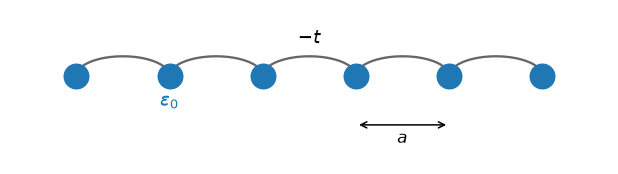

In [3]:
# the system itself, before any physics: sites, onsite energy, hopping
fig, ax = plt.subplots(figsize=(7, 1.8))
x_sites = np.arange(6)
ax.plot(x_sites, np.zeros(6), "o", ms=16, color="C0", zorder=3)
for x in x_sites[:-1]:
    # a bond drawn as an arc, labeled by its amplitude
    th = np.linspace(0, np.pi, 30)
    ax.plot(x + 0.5 + 0.5 * np.cos(th), 0.18 * np.sin(th), "-", color="0.4", lw=1.5)
ax.annotate(r"$-t$", (2.5, 0.30), ha="center", fontsize=12)
ax.annotate(r"$\varepsilon_0$", (1.0, -0.28), ha="center", fontsize=12, color="C0")
ax.annotate("", xy=(4.0, -0.45), xytext=(3.0, -0.45),
            arrowprops=dict(arrowstyle="<->", color="k", lw=1))
ax.annotate("$a$", (3.5, -0.62), ha="center", fontsize=11)
ax.set_xlim(-0.7, 5.7); ax.set_ylim(-0.8, 0.6)
ax.axis("off")
plt.show()
caption("The monatomic chain as PythTB stores it: one orbital per cell at onsite "
        "energy ε₀ (blue), nearest-neighbour hopping −t (arcs), lattice constant a. "
        "Every model in this notebook reduces to exactly this data: positions, "
        "onsite energies, and a list of hoppings.")

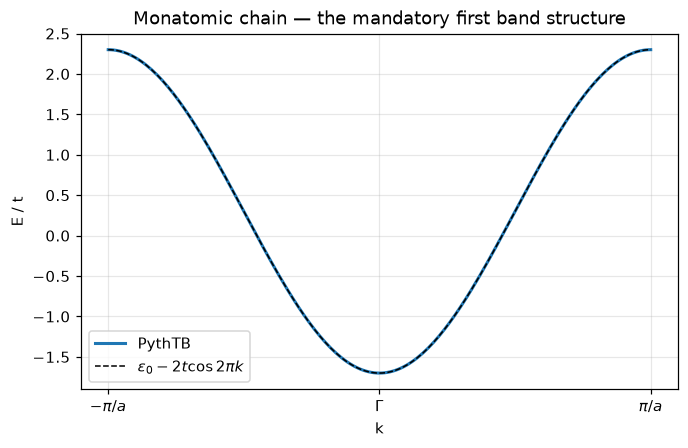

[PASS] chain dispersion matches -2t cos(2πk) — max dev = 0.00e+00


True

In [4]:
# solve on a k-path through the 1D Brillouin zone and compare with the exact band
k_vec, k_dist, k_node = chain.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
evals = chain.solve_ham(k_vec)

E_exact = eps0 - 2 * t * np.cos(2 * np.pi * k_vec[:, 0])

fig, ax = plt.subplots()
ax.plot(k_dist, evals[:, 0], lw=2, label="PythTB")
ax.plot(k_dist, E_exact, "k--", lw=1, label=r"$\varepsilon_0 - 2t\cos 2\pi k$")
ax.set_xticks(k_node, [r"$-\pi/a$", r"$\Gamma$", r"$\pi/a$"])
ax.set_xlabel("k")
ax.set_ylabel("E / t")
ax.legend()
ax.set_title("Monatomic chain — the mandatory first band structure")
plt.show()
caption("Band structure of the chain above: the numerical eigenvalues (solid) "
        "lie exactly on the analytic tight-binding cosine band (dashed). The bandwidth "
        "4t and the band minimum at Γ (for t > 0 in our sign convention) are the two "
        "numbers to read off any 1D band plot.")

check("chain dispersion matches -2t cos(2πk)",
      np.allclose(evals[:, 0], E_exact, atol=1e-12),
      f"max dev = {np.abs(evals[:, 0] - E_exact).max():.2e}")

In [5]:
# under the hood: H(k) is just a small dense matrix; convention I is visible in the phases
kpts = np.array([[0.0], [0.25], [0.25 + 1.0]])   # last point is k + G
H = chain.hamiltonian(kpts)
print("H(k) shapes:", H.shape)
print("H(0)      =", H[0].round(6))
print("H(1/4)    =", H[1].round(6))
print("H(1/4 + G)=", H[2].round(6))

check("H(k) is Hermitian at every k",
      all(np.allclose(h, h.conj().T) for h in H))
# with a single orbital at tau=0 convention I is periodic; the tau-dependence shows up
# in multi-orbital models below — remember it when comparing matrices with papers

H(k) shapes: (3, 1, 1)
H(0)      = [[-1.7+0.j]]
H(1/4)    = [[0.3+0.j]]
H(1/4 + G)= [[0.3+0.j]]
[PASS] H(k) is Hermitian at every k


True

## 3. The SSH chain — two sites, one lesson

The Su–Schrieffer–Heeger chain is the simplest model with a band topology: two orbitals per cell,
alternating hoppings $v$ (intracell) and $w$ (intercell),
$$
H(k) = \begin{pmatrix} 0 & v + w\,e^{-2\pi i k} \\ v + w\,e^{2\pi i k} & 0 \end{pmatrix}
\quad\text{(convention II form)},
$$
with spectrum $E_\pm(k) = \pm|v + w e^{2\pi i k}|$: gapped whenever $v \neq w$, with gap
$2|v - w|$ at the zone boundary, and two *distinct* insulators ($v>w$ trivial, $v<w$ topological)
that cannot be connected without closing the gap. The invariant that distinguishes them — the Berry
phase / winding number — is computed in §9; here we establish the spectra.

This section also shows off a genuinely new 2.0 feature: **symbolic parameters**. A hopping can be
the *string* `"w"`, and `solve_ham` then broadcasts over arrays passed as keyword arguments — a full
phase diagram in one call, no Python loop.

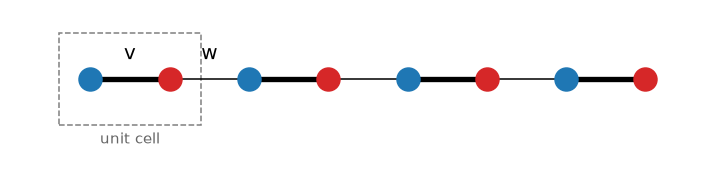

In [6]:
# the SSH geometry: a two-site cell with alternating strong/weak bonds
fig, ax = plt.subplots(figsize=(8, 1.9))
xa = np.arange(4)                       # unit cells
for c in xa:
    ax.plot([c], [0], "o", ms=15, color="C0", zorder=3)          # orbital 0
    ax.plot([c + 0.5], [0], "o", ms=15, color="C3", zorder=3)    # orbital 1
    ax.plot([c, c + 0.5], [0, 0], "-", color="k", lw=3.5, zorder=2)      # v (intracell)
    if c < xa[-1]:
        ax.plot([c + 0.5, c + 1], [0, 0], "-", color="k", lw=1.0, zorder=2)  # w
ax.annotate("v", (0.25, 0.13), ha="center", fontsize=13)
ax.annotate("w", (0.75, 0.13), ha="center", fontsize=13)
ax.add_patch(plt.Rectangle((-0.2, -0.3), 0.9, 0.6, fill=False, ls="--", ec="0.5"))
ax.annotate("unit cell", (0.25, -0.42), ha="center", fontsize=10, color="0.4")
ax.set_xlim(-0.5, 3.8); ax.set_ylim(-0.6, 0.45); ax.axis("off")
plt.show()
caption("The SSH chain: two orbitals per cell (blue at τ = 0, red at τ = ½) with "
        "alternating intracell hopping v (thick) and intercell hopping w (thin). "
        "Which bond is 'inside' the cell is a choice — but once the chain ends "
        "somewhere, the choice of where to cut becomes physical, and that is the "
        "entire topological story of this model.")

free parameters: [{'kind': 'hopping', 'orbitals': (1, 0), 'R': (1,), 'names': ('w',)}]
broadcast eigenvalue array: (201, 3, 2)


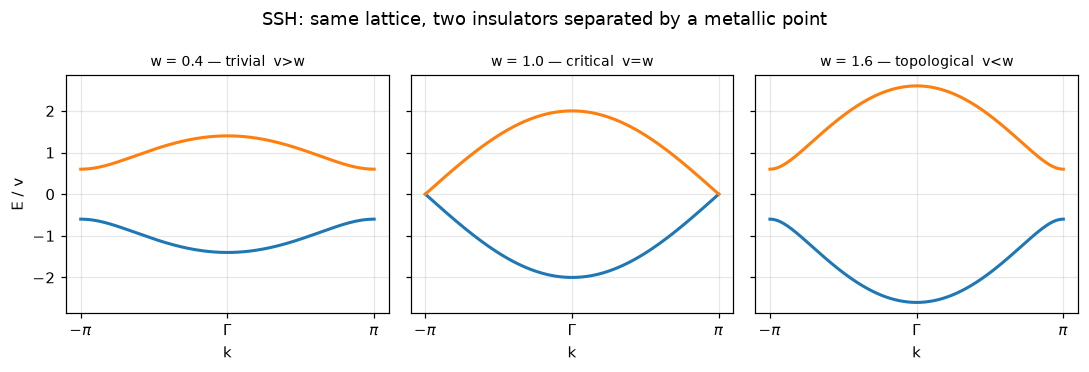

[PASS] SSH gap equals 2|v-w| — gap = 1.200000


True

In [7]:
# SSH with symbolic intercell hopping w (v fixed): one model, many Hamiltonians
v = 1.0
lat_ssh = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.5]], periodic_dirs=[0])
ssh = TBModel(lat_ssh)
ssh.set_hop(v, 0, 1, [0])         # intracell bond
ssh.set_hop("w", 1, 0, [1])       # intercell bond — symbolic
print("free parameters:", ssh.parameters)

k_vec, k_dist, k_node = ssh.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
w_values = np.array([0.4, 1.0, 1.6])
evals = ssh.solve_ham(k_vec, w=w_values)        # shape (nk, nw, 2) — broadcast over w
print("broadcast eigenvalue array:", evals.shape)
evals = np.moveaxis(evals, 1, 0)                # -> (nw, nk, 2) for plotting

fig, axs = plt.subplots(1, 3, figsize=(10, 3.4), sharey=True)
for ax, wv, ev, tag in zip(axs, w_values, evals,
                           ["trivial  v>w", "critical  v=w", "topological  v<w"]):
    ax.plot(k_dist, ev, lw=2)
    ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
    ax.set_title(f"w = {wv:.1f} — {tag}", fontsize=9)
    ax.set_xlabel("k")
axs[0].set_ylabel("E / v")
fig.suptitle("SSH: same lattice, two insulators separated by a metallic point")
fig.tight_layout()
plt.show()
caption("SSH bands for three dimerizations, computed from ONE symbolic model by "
        "broadcasting over w. The spectra of w = 0.4 and w = 1.6 look identical — "
        "band energies cannot distinguish the two insulators — yet they are "
        "topologically distinct: no smooth deformation connects them without passing "
        "through the gapless point w = v (middle panel).")

gap = 2 * evals[0, :, 1].min()    # w=0.4: full gap = 2(v-w)
check("SSH gap equals 2|v-w|", np.isclose(gap, 2 * (v - 0.4), atol=1e-10),
      f"gap = {gap:.6f}")

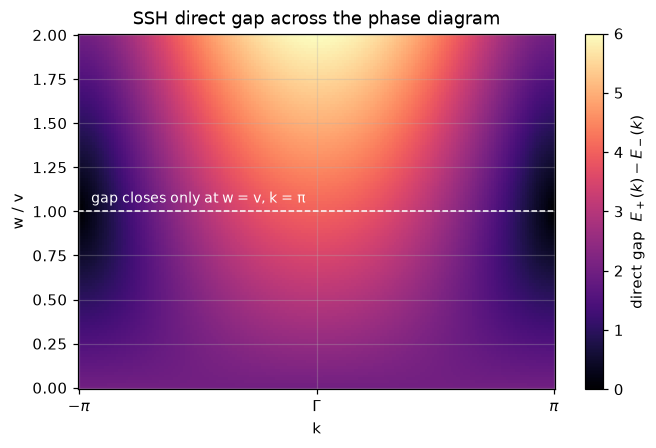

In [8]:
# continuous gap map E(k, w): dense diagonalization is cheap at this size —
# 201 k-points x 121 w-values = 24k 2x2 matrices in one vectorized call
w_scan = np.linspace(0.0, 2.0, 121)
ev_scan = np.moveaxis(ssh.solve_ham(k_vec, w=w_scan), 1, 0)   # -> (nw, nk, 2)
direct_gap = ev_scan[:, :, 1] - ev_scan[:, :, 0]

fig, ax = plt.subplots()
im = ax.pcolormesh(k_dist, w_scan, direct_gap, cmap="magma", shading="auto")
fig.colorbar(im, label=r"direct gap  $E_+(k) - E_-(k)$")
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.axhline(1.0, color="w", ls="--", lw=1)
ax.text(k_dist[5], 1.05, "gap closes only at w = v, k = π", color="w", fontsize=9)
ax.set_xlabel("k")
ax.set_ylabel("w / v")
ax.set_title("SSH direct gap across the phase diagram")
plt.show()
caption("The direct gap over the whole (k, w) plane: it vanishes at exactly one "
        "point, (k, w) = (π, v). Any path from the trivial (bottom) to the "
        "topological (top) region must cross that point — a gap closing is the "
        "unavoidable toll of a topological transition.")

## 4. Graphene and boron nitride — Dirac cones and how to gap them

Honeycomb lattice: triangular Bravais lattice $\mathbf{a}_1 = (1,0)$,
$\mathbf{a}_2 = (\tfrac12, \tfrac{\sqrt3}{2})$ with two sublattices A, B at reduced positions
$(\tfrac13,\tfrac13)$ and $(\tfrac23,\tfrac23)$. Nearest-neighbour hopping $t$ gives
$$
E_\pm(\mathbf{k}) = \pm |t|\,\bigl|1 + e^{2\pi i k_1} + e^{2\pi i k_2}\bigr|
      \;\mp\; \text{(sign fixed by convention)},
$$
which vanishes at the two inequivalent corners $K = (\tfrac23,\tfrac13)$, $K' = (\tfrac13,\tfrac23)$
of the Brillouin zone — the Dirac points. Near them the dispersion is linear (massless Dirac
fermions). A sublattice-staggered onsite $\pm\Delta$ (this *is* hexagonal boron nitride, chemically)
breaks inversion and opens a gap $2\Delta$ at $K$: same lattice, insulator instead of semimetal.

PythTB ships factory functions in `pythtb.models`; we build graphene by hand once, cross-check
against the factory, and use `plot_bands` with sublattice projection to color the bands.

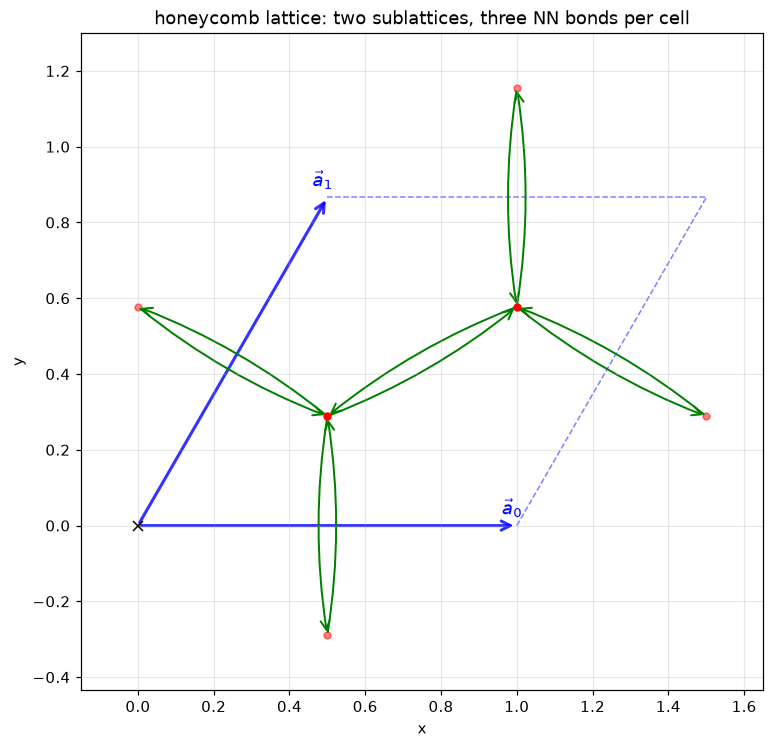

[PASS] hand-built graphene = pythtb.models.graphene


True

In [9]:
def honeycomb(delta, t):
    '''Honeycomb-lattice model with staggered onsite ±delta and NN hopping t.'''
    lat = Lattice(lat_vecs=[[1.0, 0.0], [0.5, np.sqrt(3) / 2]],
                  orb_vecs=[[1/3, 1/3], [2/3, 2/3]], periodic_dirs=[0, 1])
    m = TBModel(lat)
    m.set_onsite([-delta, delta])
    m.set_hop(t, 0, 1, [0, 0])
    m.set_hop(t, 1, 0, [1, 0])
    m.set_hop(t, 1, 0, [0, 1])
    return m

graphene = honeycomb(delta=0.0, t=-1.0)
graphene.visualize()
plt.title("honeycomb lattice: two sublattices, three NN bonds per cell")
plt.show()
caption("The honeycomb lattice as PythTB sees it (built-in visualize): sublattice A "
        "and B orbitals, the two lattice vectors, and the three nearest-neighbour "
        "bonds each cell contributes. The two-site basis — not the hexagonal shape — "
        "is what produces two bands and makes a Dirac point possible.")

# cross-check our hand-built model against the shipped factory on random k-points
from pythtb.models import graphene as graphene_factory
k_rand = rng.random((40, 2))
check("hand-built graphene = pythtb.models.graphene",
      np.allclose(graphene.solve_ham(k_rand),
                  graphene_factory(delta=0.0, t=-1.0).solve_ham(k_rand), atol=1e-12))

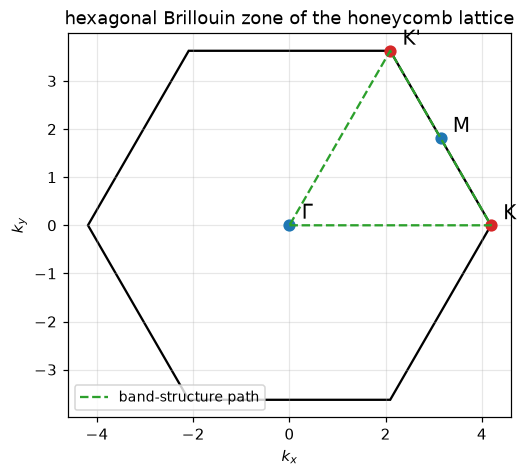

In [10]:
# the Brillouin zone and the path we will walk through it
b1 = graphene.recip_lat_vecs[0]
b2 = graphene.recip_lat_vecs[1]
corners_red = [[2/3, 1/3], [1/3, 2/3], [-1/3, 1/3], [-2/3, -1/3], [-1/3, -2/3], [1/3, -1/3]]
corners = np.array([c[0] * b1 + c[1] * b2 for c in corners_red])

fig, ax = plt.subplots(figsize=(5.2, 5))
hexagon = plt.Polygon(corners, fill=False, ec="k", lw=1.5)
ax.add_patch(hexagon)
for c_red, name in [([2/3, 1/3], "K"), ([1/3, 2/3], "K'"), ([1/2, 1/2], "M"),
                    ([0, 0], r"$\Gamma$")]:
    p = c_red[0] * b1 + c_red[1] * b2
    ax.plot(*p, "o", ms=7, color="C3" if name in ("K", "K'") else "C0")
    ax.annotate(name, p, textcoords="offset points", xytext=(8, 4), fontsize=13)
path = np.array([[0, 0], [2/3, 1/3], [1/2, 1/2], [1/3, 2/3], [0, 0]]) @ graphene.recip_lat_vecs
ax.plot(path[:, 0], path[:, 1], "--", color="C2", lw=1.5, label="band-structure path")
ax.set_aspect("equal"); ax.legend(loc="lower left", fontsize=9)
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_y$")
ax.set_title("hexagonal Brillouin zone of the honeycomb lattice")
plt.show()
caption("The Brillouin zone with the high-symmetry points and the Γ–K–M–K'–Γ path "
        "used in every honeycomb band plot below. K and K' (red) are the two "
        "inequivalent zone corners where the Dirac cones live; they are NOT related "
        "by a reciprocal lattice vector, which is why breaking the symmetry between "
        "them (as the Haldane model does in §14) has physical consequences.")

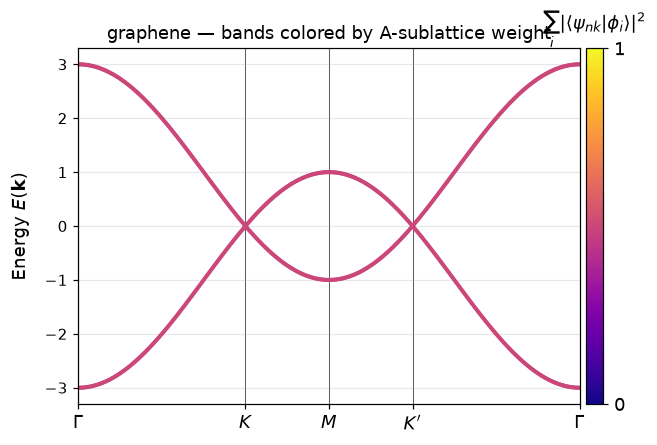

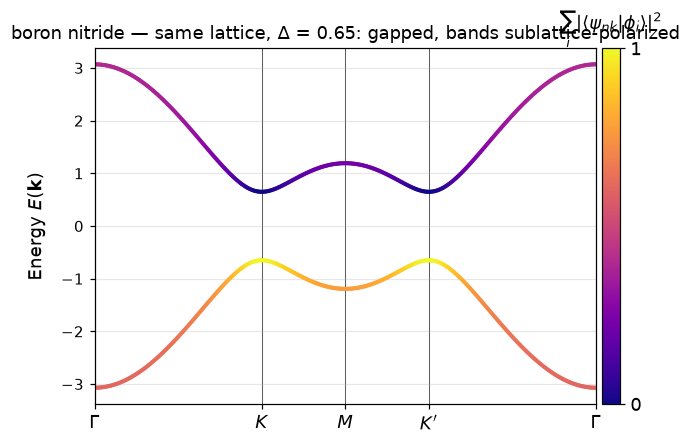

[PASS] graphene bands touch at K — E gap at K = 6.28e-16
[PASS] BN gap at K equals 2Δ — gap = 1.300000


True

In [11]:
K_NODES_HEX = [[0, 0], [2/3, 1/3], [1/2, 1/2], [1/3, 2/3], [0, 0]]
K_LABELS_HEX = [r"$\Gamma$", r"$K$", r"$M$", r"$K'$", r"$\Gamma$"]

fig, ax = graphene.plot_bands(K_NODES_HEX, k_node_labels=K_LABELS_HEX, nk=401,
                              proj_orb_idx=[0], cbar=True)
ax.set_title("graphene — bands colored by A-sublattice weight")
plt.show()
caption("Graphene bands along the BZ path just shown, colored by the weight of each "
        "state on sublattice A. Away from the Dirac points the bands mix both "
        "sublattices equally (green); the linear crossings at K and K' are protected "
        "by the equivalence of the two sublattices — inversion symmetry.")

# boron nitride: identical lattice, staggered onsite breaks inversion, gap = 2Δ
delta_bn = 0.65
bn = honeycomb(delta=delta_bn, t=-1.0)
fig, ax = bn.plot_bands(K_NODES_HEX, k_node_labels=K_LABELS_HEX, nk=401,
                        proj_orb_idx=[0], cbar=True)
ax.set_title(f"boron nitride — same lattice, Δ = {delta_bn}: gapped, bands sublattice-polarized")
plt.show()
caption("Boron nitride: chemically, B and N atoms make the two sublattices "
        "inequivalent — modeled by the staggered onsite ±Δ. The Dirac points gap out "
        "and the band coloring shows the physics: the valence band concentrates on "
        "the low-energy (N-like) sublattice, the conduction band on the other. Same "
        "lattice, same hoppings — a semimetal became an insulator by symmetry breaking.")

evK = np.atleast_2d(graphene.solve_ham(np.array([[2/3, 1/3]])))
check("graphene bands touch at K", np.isclose(evK[0, 1] - evK[0, 0], 0.0, atol=1e-12),
      f"E gap at K = {evK[0, 1] - evK[0, 0]:.2e}")
evK_bn = np.atleast_2d(bn.solve_ham(np.array([[2/3, 1/3]])))
check("BN gap at K equals 2Δ",
      np.isclose(evK_bn[0, 1] - evK_bn[0, 0], 2 * delta_bn, atol=1e-10),
      f"gap = {evK_bn[0, 1] - evK_bn[0, 0]:.6f}")

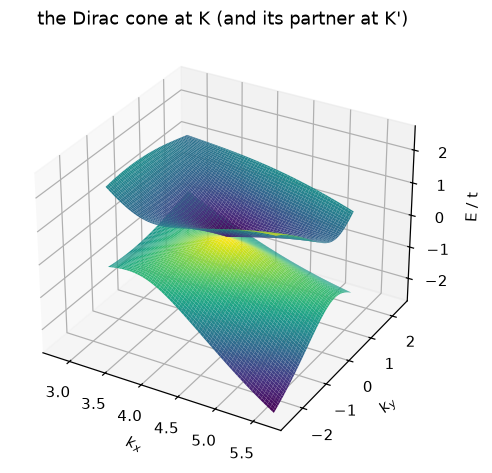

In [12]:
# the Dirac cone as a surface: E(kx, ky) on a mesh around K
nk = 120
k1 = np.linspace(0.45, 0.90, nk)
k2 = np.linspace(0.10, 0.55, nk)
K1, K2 = np.meshgrid(k1, k2, indexing="ij")
k_mesh = np.stack([K1.ravel(), K2.ravel()], axis=1)
ev = graphene.solve_ham(k_mesh).reshape(nk, nk, 2)

# convert reduced k to Cartesian for an undistorted picture
k_cart = k_mesh @ graphene.recip_lat_vecs
KX = k_cart[:, 0].reshape(nk, nk)
KY = k_cart[:, 1].reshape(nk, nk)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(KX, KY, ev[:, :, 0], cmap="viridis", rstride=2, cstride=2, lw=0)
ax.plot_surface(KX, KY, ev[:, :, 1], cmap="viridis", rstride=2, cstride=2, lw=0)
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_y$"); ax.set_zlabel("E / t")
ax.set_title("the Dirac cone at K (and its partner at K')")
plt.show()
caption("The energy surface E(kx, ky) near the zone corner: the two bands meet in a "
        "cone — dispersion linear in every direction, the hallmark of massless Dirac "
        "fermions. The slope is the Fermi velocity; in real graphene it is c/300, "
        "which is why relativistic phenomenology shows up at meV energies.")

## 5. Flat bands — Lieb and kagome lattices

Not every band disperses. On the **Lieb lattice** (a square lattice with extra sites on the bond
midpoints — the CuO₂ geometry) destructive interference pins one band exactly at $E = 0$ for any
$\mathbf{k}$: eigenstates live only on the edge sites with alternating signs, and the hopping
amplitudes cancel identically. On the **kagome lattice** (corner-sharing triangles) the same
mechanism produces a flat band touching a dispersive band quadratically.

Flat bands are where interactions would dominate (any $U$ beats zero bandwidth) — and a running
reminder that PythTB stops exactly at that point: it can *locate* flat bands but says nothing about
the correlated states they host (Part IV, §29).

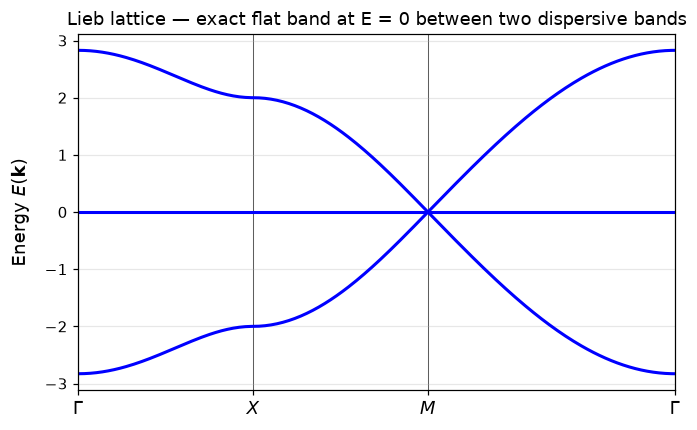

[PASS] Lieb middle band is exactly flat at E=0 — max |E| = 0.00e+00


True

In [13]:
# Lieb lattice: corner site (0,0), edge sites (1/2,0) and (0,1/2) on a square lattice
lat_lieb = Lattice(lat_vecs=[[1, 0], [0, 1]],
                   orb_vecs=[[0, 0], [0.5, 0], [0, 0.5]], periodic_dirs=[0, 1])
lieb = TBModel(lat_lieb)
t = -1.0
lieb.set_hop(t, 0, 1, [0, 0]); lieb.set_hop(t, 1, 0, [1, 0])   # corner-edge along x
lieb.set_hop(t, 0, 2, [0, 0]); lieb.set_hop(t, 2, 0, [0, 1])   # corner-edge along y

SQ_NODES = [[0, 0], [0.5, 0], [0.5, 0.5], [0, 0]]
SQ_LABELS = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]
fig, ax = lieb.plot_bands(SQ_NODES, k_node_labels=SQ_LABELS, nk=301)
ax.set_title("Lieb lattice — exact flat band at E = 0 between two dispersive bands")
plt.show()
caption("Lieb-lattice bands: two dispersive bands touching a perfectly flat band at "
        "E = 0. Flat means infinite effective mass — electrons in this band cannot "
        "propagate at all, because every state is built from the interference-locked "
        "plaquette configurations shown in the next figure.")

k_rand = rng.random((300, 2))
ev = lieb.solve_ham(k_rand)
flat = ev[:, 1]                     # middle band
check("Lieb middle band is exactly flat at E=0",
      np.abs(flat).max() < 1e-12, f"max |E| = {np.abs(flat).max():.2e}")

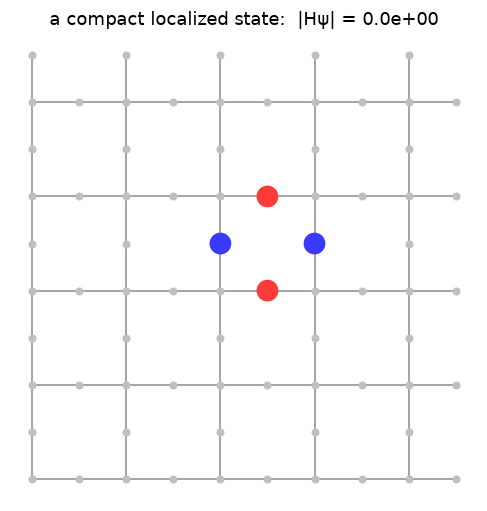

[PASS] hand-built plaquette state is an exact E = 0 eigenstate — max residual = 0.0e+00


True

In [14]:
# WHY the band is flat: an explicit compact localized state (CLS). Put amplitudes
# +1 and -1 on the four edge sites around one plaquette and nothing anywhere else;
# every corner site receives t(+1) + t(-1) = 0 — the state cannot leak, so it is
# an exact eigenstate at E = 0 despite living on only four sites.
L_cls = 5
lieb_fin = lieb.make_finite(periodic_dirs=[0, 1], num_cells=[L_cls, L_cls])
pos = lieb_fin.orb_vecs @ lieb_fin.lat_vecs

psi = np.zeros(lieb_fin.norb)
# ring of 4 edge sites around a PLAQUETTE CENTER (n+1/2, m+1/2) near the middle
# of the sample — each corner of that square then touches exactly two ring sites
# of opposite sign
pc = np.round(pos.mean(0) - 0.5) + 0.5               # nearest plaquette center
d = np.linalg.norm(pos - pc, axis=1)
ring = np.where(np.abs(d - 0.5) < 1e-6)[0]            # the 4 surrounding edge sites
ang = np.arctan2(*(pos[ring] - pc).T[::-1])           # order them around the ring
ring = ring[np.argsort(ang)]
psi[ring] = [1, -1, 1, -1]                            # alternating signs
psi = psi / np.linalg.norm(psi)

# verify it is an exact zero-energy eigenstate of the FINITE sample
H_fin = lieb_fin.hamiltonian()
residual = np.abs(H_fin @ psi).max()

fig, ax = plt.subplots(figsize=(6, 5.5))
d2p = np.sum((pos[:, None, :] - pos[None, :, :]) ** 2, axis=-1)
draw_bonds(ax, pos, [(i, j) for i, j in zip(*np.where(np.abs(d2p - 0.25) < 1e-6)) if i < j])
ax.scatter(pos[:, 0], pos[:, 1], s=18, c="0.75", zorder=2)
sc = ax.scatter(pos[ring, 0], pos[ring, 1], s=350 * np.abs(psi[ring]),
                c=np.sign(psi[ring]), cmap="bwr", vmin=-1.3, vmax=1.3, zorder=3)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"a compact localized state:  |Hψ| = {residual:.1e}")
plt.show()
caption("The flat band, explained in one picture: a state with alternating signs "
        "(red/blue) on the four edge sites of a single plaquette. Each neighbouring "
        "corner site couples to a +1 and a −1 with equal hopping, so the amplitudes "
        "cancel exactly and the state is a strict eigenstate at E = 0. One such state "
        "exists per plaquette — a macroscopically degenerate band of them.")

check("hand-built plaquette state is an exact E = 0 eigenstate",
      residual < 1e-12, f"max residual = {residual:.1e}")

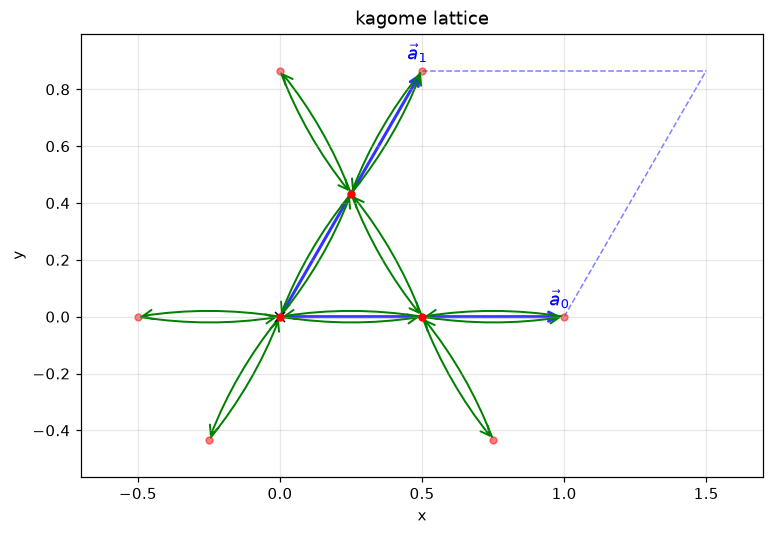

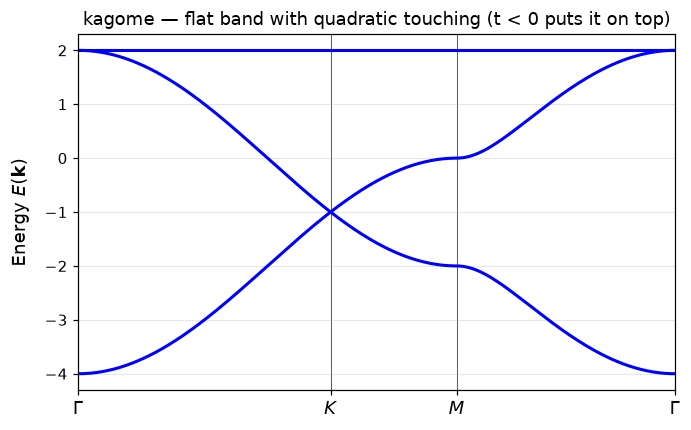

[PASS] kagome has an exactly flat band at E = -2t — spread = 2.66e-15 around E = 2.000


True

In [15]:
# kagome lattice: three sites per triangular cell, corner-sharing triangles
lat_kag = Lattice(lat_vecs=[[1, 0], [0.5, np.sqrt(3) / 2]],
                  orb_vecs=[[0, 0], [0.5, 0], [0, 0.5]], periodic_dirs=[0, 1])
kagome = TBModel(lat_kag)
t = -1.0
kagome.set_hop(t, 0, 1, [0, 0]); kagome.set_hop(t, 0, 1, [-1, 0])
kagome.set_hop(t, 0, 2, [0, 0]); kagome.set_hop(t, 0, 2, [0, -1])
kagome.set_hop(t, 1, 2, [0, 0]); kagome.set_hop(t, 1, 2, [1, -1])

kagome.visualize()
plt.title("kagome lattice")
plt.show()
caption("The kagome lattice: corner-sharing triangles, three sites per cell. "
        "Geometric frustration — every closed loop of bonds has odd length 3 — is "
        "what breaks particle-hole symmetry and pins the flat band at the TOP of the "
        "spectrum for t < 0 rather than in the middle.")

TRI_NODES = [[0, 0], [2/3, 1/3], [1/2, 1/2], [0, 0]]
TRI_LABELS = [r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$"]
fig, ax = kagome.plot_bands(TRI_NODES, k_node_labels=TRI_LABELS, nk=301)
ax.set_title("kagome — flat band with quadratic touching (t < 0 puts it on top)")
plt.show()
caption("Kagome bands: a Dirac crossing at K (graphene-like, from the underlying "
        "triangular Bravais lattice) plus an exactly flat band touching the middle "
        "band quadratically at Γ. The kagome CLS lives on a hexagon with alternating "
        "signs; unlike the Lieb case the touching makes the flat band's topology "
        "singular — it cannot be spanned by exponentially localized Wannier functions.")

ev = kagome.solve_ham(rng.random((300, 2)))
flat = ev[:, 2]
check("kagome has an exactly flat band at E = -2t",
      np.allclose(flat, -2 * t, atol=1e-12),
      f"spread = {flat.max() - flat.min():.2e} around E = {flat.mean():.3f}")

## 6. Finite systems — `cut_piece`, edge states, and where electrons actually sit

Two geometry operations turn a bulk model into something with boundaries:

- **`cut_piece(num_cells, periodic_dir, glue_edges=False)`** — replicate the cell `num_cells`
  times along one direction and open (or ring-close) the boundary. Applied once to a 2D model it
  makes a **ribbon**; twice, a **flake**.
- **`make_finite(periodic_dirs, num_cells)`** — cut several directions in one call.

The resulting object is the *same class* — a `TBModel` with fewer periodic directions — so every
solver and every Berry tool keeps working. For a fully finite model `solve_ham()` takes no
k-points and returns the cluster spectrum.

Physics on display: the SSH chain's **topological end modes** — two states exponentially pinned to
$E=0$ whenever the weak bond is cut — and the **flat edge band of zigzag graphene ribbons**.

> **PythTB cannot…** attach semi-infinite leads to these edges. A ribbon here is a closed box: we
> can see the edge *states*, but not the edge *conductance* they would carry. That is Kwant's half
> of the physics (Part IV, §25).

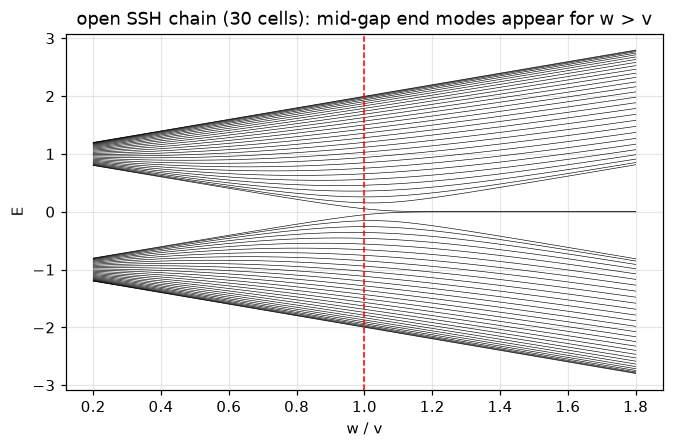

[PASS] topological SSH chain hosts exactly 2 end modes — states with |E| < 1e-3: 2


True

In [16]:
def ssh_model(v, w):
    lat = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.5]], periodic_dirs=[0])
    m = TBModel(lat)
    m.set_hop(v, 0, 1, [0])
    m.set_hop(w, 1, 0, [1])
    return m

# open-chain spectrum as the dimerization is swept through the transition
N_CELLS = 30
w_scan = np.linspace(0.2, 1.8, 60)
spectra = np.array([ssh_model(1.0, w).cut_piece(N_CELLS, 0).solve_ham() for w in w_scan])

fig, ax = plt.subplots()
ax.plot(w_scan, spectra, "k-", lw=0.4)
ax.axvline(1.0, color="r", ls="--", lw=1)
ax.set_xlabel("w / v")
ax.set_ylabel("E")
ax.set_title(f"open SSH chain ({N_CELLS} cells): mid-gap end modes appear for w > v")
plt.show()
caption("Spectrum of an open SSH chain versus dimerization. For w < v the finite "
        "chain simply shows the bulk bands with a clean gap; the moment w exceeds v "
        "the chain terminates on weak bonds, and two states peel off into the gap "
        "and pin exponentially to E = 0: the bulk-boundary correspondence in its "
        "simplest incarnation — the bulk invariant (Berry phase π, computed in §9) "
        "forces boundary states to exist, whatever the microscopic details of the cut.")

evals_topo = ssh_model(1.0, 1.6).cut_piece(N_CELLS, 0).solve_ham()
n_zero = int(np.sum(np.abs(evals_topo) < 1e-3))
check("topological SSH chain hosts exactly 2 end modes", n_zero == 2,
      f"states with |E| < 1e-3: {n_zero}")

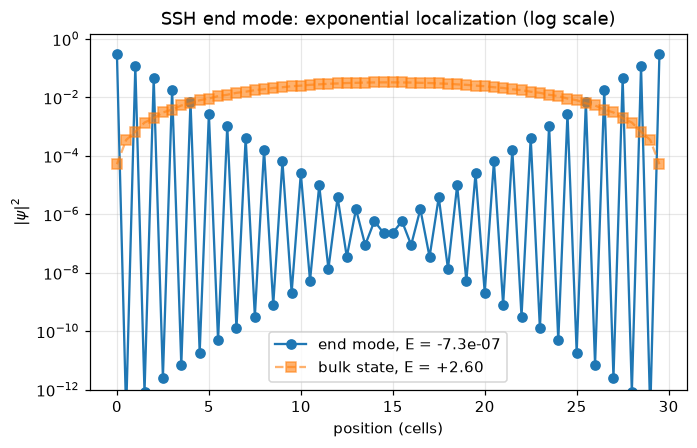

[PASS] end-mode decay follows (v/w)^2 per cell — measured 0.3906 vs (v/w)^2 = 0.3906


True

In [17]:
# where do the end modes live?  |psi|^2 across the chain, compared with a bulk state
fin = ssh_model(1.0, 1.6).cut_piece(N_CELLS, 0)
evals, evecs = fin.solve_ham(return_eigvecs=True)
x = fin.orb_vecs[:, 0]                            # orbital positions in units of the cell

idx_edge = np.argsort(np.abs(evals))[0]           # one of the two E≈0 states
idx_bulk = np.argmax(evals)                       # top of the spectrum: a bulk state

fig, ax = plt.subplots()
ax.semilogy(x, np.abs(evecs[idx_edge]) ** 2, "o-", label=f"end mode, E = {evals[idx_edge]:+.1e}")
ax.semilogy(x, np.abs(evecs[idx_bulk]) ** 2, "s--", alpha=0.6,
            label=f"bulk state, E = {evals[idx_bulk]:+.2f}")
ax.set_xlabel("position (cells)")
ax.set_ylabel(r"$|\psi|^2$")
ax.set_ylim(1e-12, 1.5)
ax.legend()
ax.set_title("SSH end mode: exponential localization (log scale)")
plt.show()
caption("Where the end mode lives: |ψ|² of one E ≈ 0 state (circles) against a "
        "generic bulk state (squares), on a log scale. The end mode decays "
        "exponentially with decay factor (v/w)² per cell and — a chiral-symmetry "
        "fingerprint — has weight on only ONE sublattice: the even-numbered points "
        "interlace the odd ones because alternate sites carry strictly zero amplitude.")

# exponential envelope check: |psi|^2 drops by (v/w)^2 per cell on the A sublattice
dens = np.abs(evecs[idx_edge]) ** 2
ratio = dens[4] / dens[2]                         # A-sites of neighbouring cells 1 and 2
check("end-mode decay follows (v/w)^2 per cell",
      np.isclose(ratio, (1.0 / 1.6) ** 2, rtol=0.15),
      f"measured {ratio:.4f} vs (v/w)^2 = {(1.0/1.6)**2:.4f}")

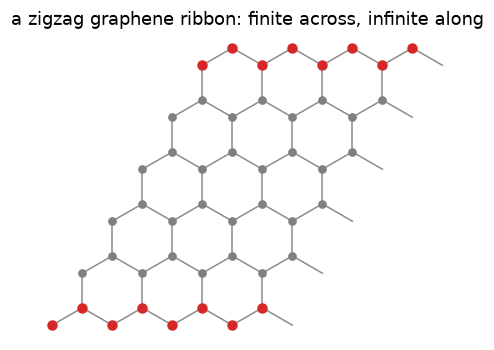

In [18]:
# what a ribbon IS: the honeycomb cut to a finite number of cells along a2,
# still infinite (periodic) along a1 — drawn here with the edge atoms highlighted
graphene = honeycomb(delta=0.0, t=-1.0)
rib_demo = graphene.cut_piece(6, 1, glue_edges=False)
pos_r = rib_demo.orb_vecs @ rib_demo.lat_vecs

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for shift in (-1, 0, 1, 2):                        # repeat cells along the periodic dir
    p = pos_r + shift * rib_demo.lat_vecs[0]
    d2r = np.sum((p[:, None, :] - p[None, :, :]) ** 2, axis=-1)
    # NN bonds inside this repeated block
    draw_bonds(ax, p, [(i, j) for i, j in zip(*np.where(np.abs(d2r - 1/3) < 1e-6)) if i < j])
    # bonds between neighbouring blocks
    q = pos_r + (shift + 1) * rib_demo.lat_vecs[0]
    for i in range(len(p)):
        for j in range(len(q)):
            if abs(np.sum((p[i] - q[j]) ** 2) - 1/3) < 1e-6:
                ax.plot([p[i, 0], q[j, 0]], [p[i, 1], q[j, 1]], "-", color="0.55", lw=1)
    edge_mask = (pos_r[:, 1] < pos_r[:, 1].min() + 0.3) | (pos_r[:, 1] > pos_r[:, 1].max() - 0.3)
    ax.scatter(p[~edge_mask, 0], p[~edge_mask, 1], s=22, c="0.5", zorder=3)
    ax.scatter(p[edge_mask, 0], p[edge_mask, 1], s=34, c="C3", zorder=4)
ax.annotate("periodic →", (pos_r[:, 0].mean() + 1.0, pos_r[:, 1].max() + 0.45),
            fontsize=11, color="0.3")
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("a zigzag graphene ribbon: finite across, infinite along")
plt.show()
caption("The ribbon geometry produced by cut_piece: six cells wide, periodic along "
        "the horizontal direction (a few periods are drawn). The outermost atoms "
        "(red) form zigzag edges, and — crucially — the top and bottom edge atoms "
        "belong to OPPOSITE sublattices. The flat edge band in the next figure lives "
        "on exactly these red sites.")

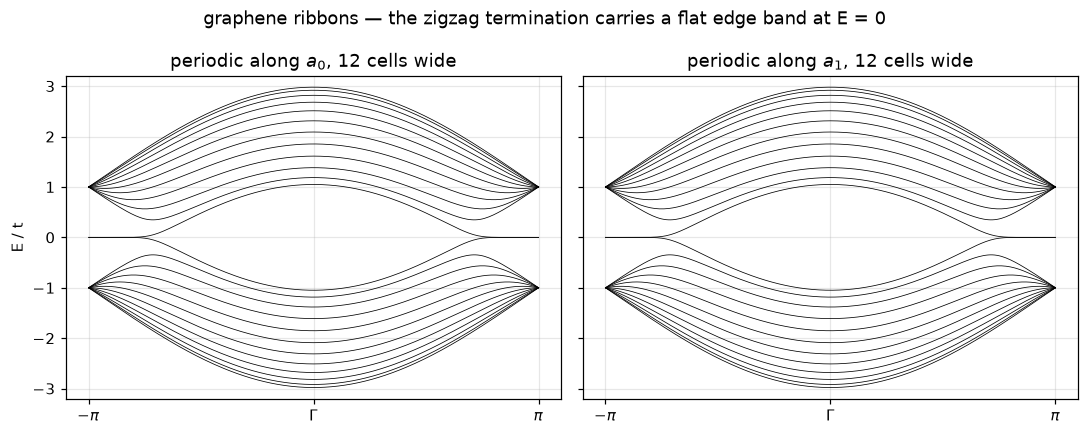

[PASS] zigzag ribbon has zero modes at k = π — |E| < 0.05: 2 states


True

In [19]:
# graphene ribbons: band structures for cuts along each lattice direction
NW = 12                                            # ribbon width in cells

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, cut_dir in zip(axs, (1, 0)):
    rib = graphene.cut_piece(NW, cut_dir, glue_edges=False)
    k_vec, k_dist, k_node = rib.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
    ev = rib.solve_ham(k_vec)
    ax.plot(k_dist, ev, "k-", lw=0.5)
    ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
    ax.set_title(f"periodic along $a_{1-cut_dir}$, {NW} cells wide")
    ax.set_ylim(-3.2, 3.2)
axs[0].set_ylabel("E / t")
fig.suptitle("graphene ribbons — the zigzag termination carries a flat edge band at E = 0")
fig.tight_layout()
plt.show()
caption("Ribbon band structures for the two cut directions. Between the projections "
        "of K and K' (around k = π) a nearly flat band sits at E = 0: these are the "
        "zigzag edge states, one per edge, living on a single sublattice. Their "
        "flatness (zero velocity) concentrates density of states at the Fermi level "
        "of neutral graphene — the seed of the edge magnetism computed in §29.")

# the flat band at the zone boundary is edge physics: count E≈0 states at k = 1/2
rib = graphene.cut_piece(NW, 1, glue_edges=False)
ev_pi = np.atleast_2d(rib.solve_ham(np.array([[0.5]])))[0]
check("zigzag ribbon has zero modes at k = π",
      np.sum(np.abs(ev_pi) < 5e-2) >= 2,
      f"|E| < 0.05: {int(np.sum(np.abs(ev_pi) < 5e-2))} states")

## 7. Supercells and defects — `make_supercell`, `remove_orb`

**`make_supercell(M)`** builds the model on a larger cell defined by integer combinations of the
original lattice vectors (rows of `M`), remapping every hopping. Bands *fold*: a $3\times3$
graphene supercell maps both $K$ and $K'$ onto $\Gamma$ — the Dirac cones reappear stacked at zone
center. Folding is not just bookkeeping: it is the standard trick for commensurate perturbations
(§21 uses it for magnetic flux), and supercell + defect is the poor man's disorder (§25).

**`remove_orb(i)`** deletes orbitals — a vacancy. On a bipartite lattice, removing one A-site
leaves $N_B = N_A + 1$, and the bipartite theorem guarantees at least one exact zero mode living
entirely on the B sublattice, localized around the vacancy. We build a graphene flake, punch out
the central atom, and look at the state that appears.

primitive cell: 2 orbitals  ->  3x3 supercell: 18 orbitals


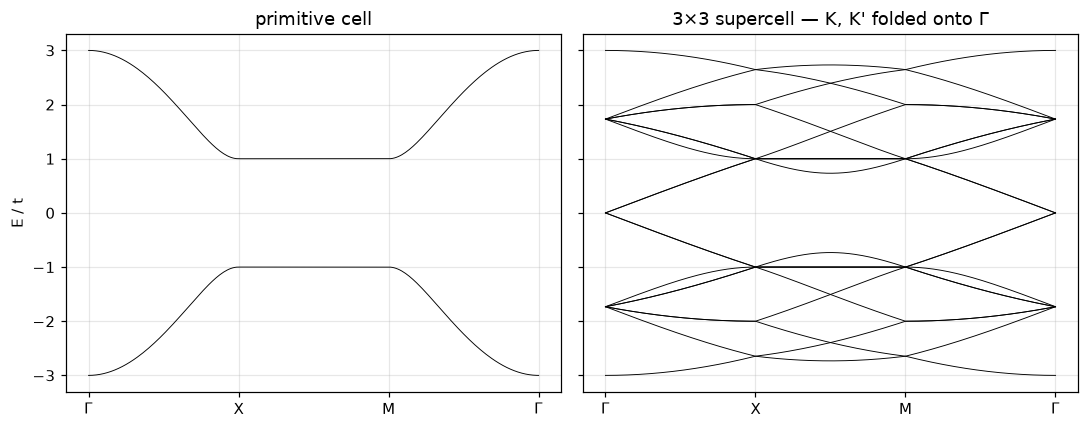

[PASS] supercell folds Dirac points onto Γ (E = 0 states at zone center) — zero-energy states at Γ: 4


True

In [20]:
# band folding: 3x3 graphene supercell
sc = graphene.make_supercell([[3, 0], [0, 3]])
print(f"primitive cell: {graphene.norb} orbitals  ->  3x3 supercell: {sc.norb} orbitals")

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, m, title in ((axs[0], graphene, "primitive cell"),
                     (axs[1], sc, "3×3 supercell — K, K' folded onto Γ")):
    k_vec, k_dist, k_node = m.k_path([[0, 0], [0.5, 0.0], [0.5, 0.5], [0, 0]],
                                     nk=241, report=False)
    ev = m.solve_ham(k_vec)
    ax.plot(k_dist, ev, "k-", lw=0.6)
    ax.set_xticks(k_node, [r"$\Gamma$", "X", "M", r"$\Gamma$"])
    ax.set_title(title)
axs[0].set_ylabel("E / t")
fig.tight_layout()
plt.show()
caption("Band folding: the same graphene crystal described in its primitive cell "
        "(left) and in a 3×3 supercell (right). Nothing physical changed — the "
        "supercell BZ is 9× smaller, so the bands fold back 9× denser, and both "
        "Dirac points land on Γ. Folding is the price of any supercell treatment "
        "(defects, disorder, magnetic flux) and must not be mistaken for new physics.")

ev_gamma = np.atleast_2d(sc.solve_ham(np.array([[0.0, 0.0]])))[0]
check("supercell folds Dirac points onto Γ (E = 0 states at zone center)",
      np.sum(np.abs(ev_gamma) < 1e-9) >= 4,
      f"zero-energy states at Γ: {int(np.sum(np.abs(ev_gamma) < 1e-9))}")

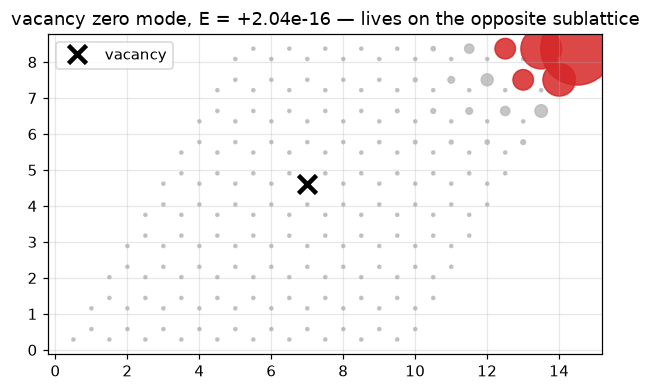

[PASS] vacancy creates a zero mode — E = 2.04e-16
[PASS] zero mode lives on the B sublattice — B-sublattice weight = 1.000000


True

In [21]:
# vacancy in a graphene flake: bipartite zero mode
L = 10
flake = graphene.make_finite(periodic_dirs=[0, 1], num_cells=[L, L])

# remove the A-site closest to the flake center
pos = flake.orb_vecs @ flake.lat_vecs                 # Cartesian positions
center = pos.mean(axis=0)
a_sites = np.arange(0, flake.norb, 2)                  # even indices = A sublattice
i_kill = a_sites[np.argmin(np.linalg.norm(pos[a_sites] - center, axis=1))]
vac = flake.copy()
vac.remove_orb(int(i_kill))       # NB: mutates in place (returns None) — despite the docstring

evals, evecs = vac.solve_ham(return_eigvecs=True)
i0 = np.argmin(np.abs(evals))
dens = np.abs(evecs[i0]) ** 2
pos_v = vac.orb_vecs @ vac.lat_vecs

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(pos_v[:, 0], pos_v[:, 1], s=4 + 4000 * dens, c=["#d62728" if d > dens.max() / 20
           else "#bbbbbb" for d in dens], alpha=0.85)
ax.plot(*pos[i_kill], "kx", ms=12, mew=3, label="vacancy")
ax.set_aspect("equal")
ax.legend()
ax.set_title(f"vacancy zero mode, E = {evals[i0]:+.2e} — lives on the opposite sublattice")
plt.show()
caption("A single vacancy in a graphene flake (black cross) and the zero mode it "
        "creates (red, symbol size ∝ |ψ|²). Removing one A-site leaves the B "
        "sublattice with one extra site, and on any bipartite lattice that imbalance "
        "guarantees an exact E = 0 state confined to the majority sublattice — "
        "decaying as a power law around the missing atom. The proof is counting, "
        "not perturbation theory, so the mode survives at any hopping strength.")

check("vacancy creates a zero mode", np.abs(evals[i0]) < 1e-10,
      f"E = {evals[i0]:.2e}")
# sublattice purity: the removed site was A, so the mode should be ~100% on B
b_mask = (np.arange(vac.norb + 1) % 2 == 1)            # odd indices were B before removal
b_mask = np.delete(b_mask, i_kill)
check("zero mode lives on the B sublattice", dens[b_mask].sum() > 0.999,
      f"B-sublattice weight = {dens[b_mask].sum():.6f}")

## 8. Spin, natively — `spinful=True`

Classic PythTB 1.x treated spin through the `nspin=2` option with a clunky 4-vector notation;
PythTB 2.0 makes it a first-class flag: `TBModel(lattice, spinful=True)` doubles every orbital
into a Kramers pair, and onsite/hopping amplitudes become either

- a scalar $t$ → spin-diagonal $t\,\sigma_0$,
- a 4-vector $[a_0, a_x, a_y, a_z]$ → $a_0\sigma_0 + a_x\sigma_x + a_y\sigma_y + a_z\sigma_z$, or
- an explicit $2\times2$ (complex) matrix.

Demo: the textbook **Rashba wire in a Zeeman field**,
$$
H(k) = -2t\cos K \,\sigma_0 \;-\; 2\alpha \sin K\,\sigma_y \;+\; B\,\sigma_z, \qquad K = 2\pi k,
$$
whose spectrum $E_\pm = -2t\cos K \pm \sqrt{4\alpha^2\sin^2 K + B^2}$ develops the *helical gap* at
$k=0$ that underlies the Majorana nanowire recipe (we return to it in Part II, where the missing
ingredient — superconductivity — has to be faked by hand).

norb = 1, nspin = 2, nstate = 2


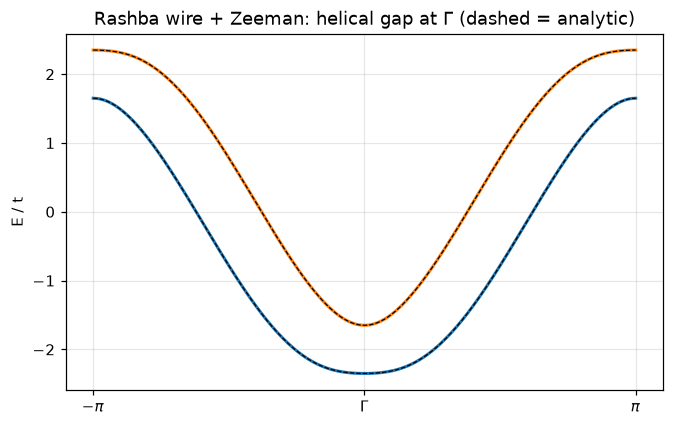

[PASS] spinful wire matches analytic Rashba+Zeeman dispersion


True

In [22]:
t, alpha, B = 1.0, 0.35, 0.35
sy = np.array([[0, -1j], [1j, 0]])

lat_wire = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0]], periodic_dirs=[0])
wire = TBModel(lat_wire, spinful=True)
wire.set_onsite([[0.0, 0.0, 0.0, B]])                 # 4-vector: B sigma_z
wire.set_hop(-t * np.eye(2) + 1j * alpha * sy, 0, 0, [1])   # explicit 2x2 hop matrix
print(f"norb = {wire.norb}, nspin = {wire.nspin}, nstate = {wire.nstate}")

k_vec, k_dist, k_node = wire.k_path([[-0.5], [0.0], [0.5]], nk=301, report=False)
ev = wire.solve_ham(k_vec)

K = 2 * np.pi * k_vec[:, 0]
E_exact = np.array([-2 * t * np.cos(K) - np.sqrt(4 * alpha**2 * np.sin(K)**2 + B**2),
                    -2 * t * np.cos(K) + np.sqrt(4 * alpha**2 * np.sin(K)**2 + B**2)]).T

fig, ax = plt.subplots()
ax.plot(k_dist, ev, lw=2)
ax.plot(k_dist, E_exact, "k--", lw=0.8)
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.set_ylabel("E / t")
ax.set_title("Rashba wire + Zeeman: helical gap at Γ (dashed = analytic)")
plt.show()
caption("Bands of the spinful wire. Rashba coupling alone would give two shifted "
        "bands crossing at k = 0; the Zeeman field opens the 'helical gap' at that "
        "crossing. Tuning the chemical potential into this gap leaves a single pair "
        "of counter-propagating, spin-momentum-locked modes — the starting point of "
        "every Majorana nanowire proposal.")

check("spinful wire matches analytic Rashba+Zeeman dispersion",
      np.allclose(np.sort(ev, axis=1), np.sort(E_exact, axis=1), atol=1e-10))

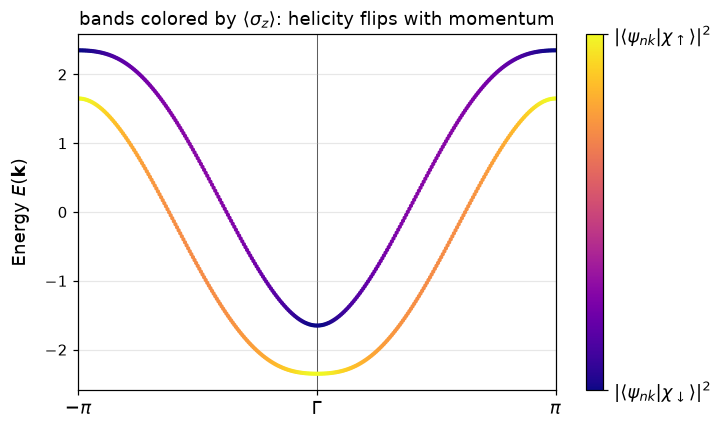

In [23]:
# spin-resolved bands: plot_bands can color by <sigma_z>
fig, ax = wire.plot_bands([[-0.5], [0.0], [0.5]], k_node_labels=[r"$-\pi$", r"$\Gamma$", r"$\pi$"],
                          nk=301, proj_spin=True)
ax.set_title(r"bands colored by $\langle\sigma_z\rangle$: helicity flips with momentum")
plt.show()
caption("The same bands colored by the spin projection ⟨σz⟩ (plot_bands with "
        "proj_spin): near k = 0 the Zeeman term dominates and polarizes the spins "
        "along z; at larger |k| the Rashba field wins and rotates them into the y "
        "direction, the color fading toward the middle of the scale.")

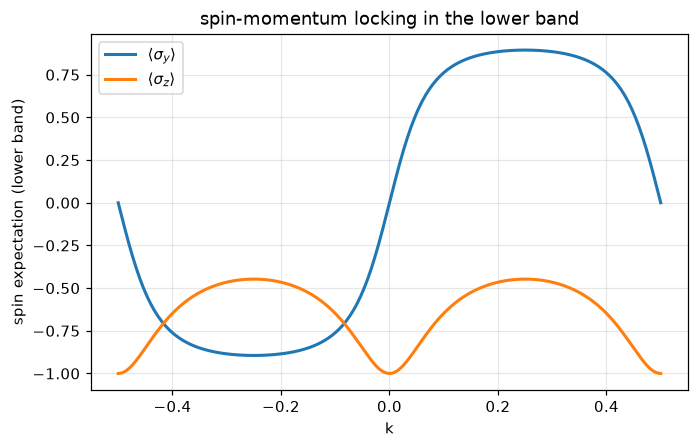

In [24]:
# the full spin texture: expectation values of sigma_y and sigma_z along the
# lower band, computed directly from the eigenvectors
_, vec_w = wire.solve_ham(k_vec, return_eigvecs=True)
sy_tex = np.array([[0, -1j], [1j, 0]])
sz_tex = np.diag([1.0, -1.0])
psi_low = vec_w[:, 0, :]                       # lower band, (nk, 2 spin components)
exp_sy = np.real(np.einsum("ks,st,kt->k", psi_low.conj(), sy_tex, psi_low))
exp_sz = np.real(np.einsum("ks,st,kt->k", psi_low.conj(), sz_tex, psi_low))

fig, ax = plt.subplots()
ax.plot(k_vec[:, 0], exp_sy, lw=2, label=r"$\langle\sigma_y\rangle$")
ax.plot(k_vec[:, 0], exp_sz, lw=2, label=r"$\langle\sigma_z\rangle$")
ax.set_xlabel("k"); ax.set_ylabel("spin expectation (lower band)")
ax.legend(); ax.set_title("spin-momentum locking in the lower band")
plt.show()
caption("Spin texture of the lower band: ⟨σy⟩ is odd in k (the Rashba field is "
        "∝ sin k · σy) while ⟨σz⟩ is even and peaks at k = 0 where the Zeeman term "
        "rules. A right-mover and a left-mover at the same energy inside the helical "
        "gap therefore carry nearly opposite spins — backscattering requires a spin "
        "flip, which is what protects helical transport.")

## 9. The Berry-phase machinery — `Mesh`, `WFArray`, and polarization

This is PythTB's reason to exist. For a band $|u_{n\mathbf{k}}\rangle$ transported around a closed
loop $\mathcal{C}$ in parameter space, the **Berry phase**
$$
\phi = \oint_{\mathcal C} \langle u | i\nabla_{\mathbf k} u\rangle\cdot d\mathbf k
$$
is gauge-invariant modulo $2\pi$. Numerically it is computed from the gauge-independent discrete
formula (King-Smith–Vanderbilt):
$$
\phi = -\,\mathrm{Im}\ln \prod_{j} \det M^{(j,j+1)}, \qquad
M^{(j,j+1)}_{mn} = \langle u_{m,\mathbf k_j} | u_{n,\mathbf k_{j+1}}\rangle,
$$
which is exactly what `WFArray.berry_phase` evaluates (and `wilson_loop` returns the full
eigenvalue spectrum of the product, needed for $\mathbb{Z}_2$ invariants in Part II).

The physical payoff in 1D is the **modern theory of polarization**: the electronic contribution is
$P = e\,\phi/2\pi$ per cell — a bulk quantity defined only modulo $e$, whose *changes* are
measurable currents. In PythTB convention I, $\bar x = \phi/2\pi$ is literally the Wannier-center
position in reduced coordinates.

Workflow: build a `Mesh` (k-grids, λ-axes, paths, loops) → fill a `WFArray` with eigenstates via
`solve_model` → ask for `berry_phase`, `berry_flux`, `berry_curvature`, `chern_number`,
`wilson_loop`, `position_hwf`. The array knows which axes wind the Brillouin zone and applies the
convention-I boundary phases automatically.

In [25]:
# SSH polarization: Wannier center of the occupied band in both dimerizations
def ssh_wannier_center(v, w, nk=101):
    m = ssh_model(v, w)
    mesh = Mesh(["k"])
    mesh.build_grid([nk], k_endpoints=True)
    wfa = WFArray(m.lattice, mesh)
    wfa.solve_model(m)
    phi = float(np.squeeze(wfa.berry_phase(axis_idx=0, state_idx=[0])))
    return (phi / (2 * np.pi)) % 1.0

x_triv = ssh_wannier_center(1.0, 0.5)
x_topo = ssh_wannier_center(0.5, 1.0)
print(f"Wannier center, trivial   (v>w): x̄ = {x_triv:.6f}  (on the intracell bond, 0.25)")
print(f"Wannier center, topological(v<w): x̄ = {x_topo:.6f}  (on the intercell bond, 0.75)")

check("SSH Wannier centers sit on bond centers",
      np.isclose(x_triv, 0.25, atol=1e-6) and np.isclose(x_topo, 0.75, atol=1e-6))
check("the two phases differ by half a lattice vector (Berry phase π)",
      np.isclose(abs(x_topo - x_triv), 0.5, atol=1e-6),
      f"Δx̄ = {abs(x_topo - x_triv):.6f}")

Wannier center, trivial   (v>w): x̄ = 0.250000  (on the intracell bond, 0.25)
Wannier center, topological(v<w): x̄ = 0.750000  (on the intercell bond, 0.75)
[PASS] SSH Wannier centers sit on bond centers
[PASS] the two phases differ by half a lattice vector (Berry phase π) — Δx̄ = 0.500000


True

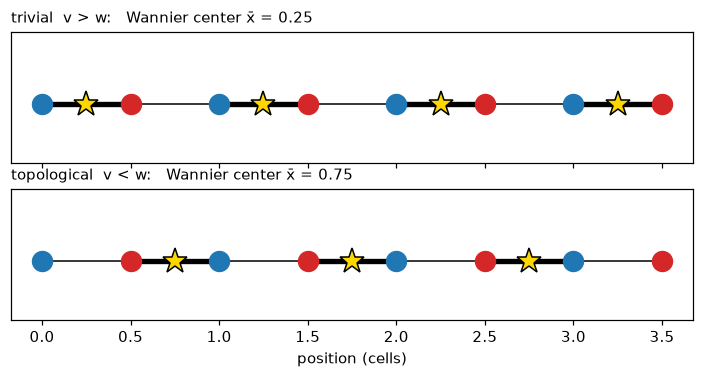

In [26]:
# the Berry phase made tangible: draw where the electron's charge center actually
# sits on the chain in each phase
fig, axs = plt.subplots(2, 1, figsize=(8, 3.4), sharex=True)
for ax, (v, w, xbar, tag) in zip(axs, [(1.0, 0.5, x_triv, "trivial  v > w"),
                                       (0.5, 1.0, x_topo, "topological  v < w")]):
    for c in range(4):
        ax.plot([c], [0], "o", ms=13, color="C0", zorder=3)
        ax.plot([c + 0.5], [0], "o", ms=13, color="C3", zorder=3)
        ax.plot([c, c + 0.5], [0, 0], "-", color="k", lw=3.5 if v > w else 1.0)
        if c < 3:
            ax.plot([c + 0.5, c + 1], [0, 0], "-", color="k", lw=1.0 if v > w else 3.5)
    for c in range(4 if xbar < 0.5 else 3):
        ax.plot([c + xbar], [0], "*", ms=17, color="gold", mec="k", zorder=4)
    ax.set_ylim(-0.4, 0.5); ax.set_yticks([])
    ax.set_title(f"{tag}:   Wannier center x̄ = {xbar:.2f}", fontsize=10, loc="left")
    ax.grid(False)
axs[1].set_xlabel("position (cells)")
plt.show()
caption("The polarization difference, drawn: the occupied band's Wannier center "
        "(star) sits at the middle of whichever bond is STRONG — x̄ = ¼ inside the "
        "cell in the trivial phase, x̄ = ¾ (on the intercell bond) in the topological "
        "one. Cutting the chain through a strong bond costs an end state: comparing "
        "the two rows shows immediately why the topological chain, terminated at a "
        "cell boundary, must leave half an electron's worth of charge behind at "
        "each end.")

In [27]:
# the same number three ways: berry_phase, wilson_loop eigenvalues, and the
# hybrid-Wannier-center routine position_hwf — they must agree
m = ssh_model(1.0, 0.5)
mesh = Mesh(["k"]); mesh.build_grid([101], k_endpoints=True)
wfa = WFArray(m.lattice, mesh); wfa.solve_model(m)

phi_bp = float(np.squeeze(wfa.berry_phase(axis_idx=0, state_idx=[0])))
# NB upstream bug (pythtb 2.0.2): the wilson_evals=True return path stores the
# complex eigenvalues e^{i phi} into a float array, silently returning cos(phi).
# The Wilson unitary itself is correct — diagonalize it yourself. The bug's only
# visible symptom is a numpy ComplexWarning raised inside pythtb; silence it so the
# output stays clean (the workaround below does not depend on it).
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", np.exceptions.ComplexWarning)
    U_wilson, _ = wfa.wilson_loop(axis_idx=0, state_idx=[0], wilson_evals=True)
lam = np.linalg.eigvals(np.atleast_2d(np.squeeze(U_wilson)))
phi_wl = float(-np.angle(lam[0]))                  # same sign convention as berry_phase

print(f"berry_phase : φ = {phi_bp:+.8f}")
print(f"wilson_loop : φ = {phi_wl:+.8f}")
check("Wilson-loop eigenvalue reproduces the Berry phase",
      np.isclose(np.exp(1j * phi_bp), np.exp(1j * phi_wl), atol=1e-8))

# gauge invariance: shifting where the k-loop starts must not change φ (mod 2π)
mesh2 = Mesh(["k"]); mesh2.build_grid([101], k_endpoints=True, gamma_centered=True)
wfa2 = WFArray(m.lattice, mesh2); wfa2.solve_model(m)
phi_shift = float(np.squeeze(wfa2.berry_phase(axis_idx=0, state_idx=[0])))
check("Berry phase is independent of loop origin (gauge invariance)",
      np.isclose(np.exp(1j * phi_bp), np.exp(1j * phi_shift), atol=1e-8),
      f"Δφ = {abs(phi_bp - phi_shift):.2e} mod 2π")

berry_phase : φ = +1.57079633
wilson_loop : φ = +1.57079633
[PASS] Wilson-loop eigenvalue reproduces the Berry phase
[PASS] Berry phase is independent of loop origin (gauge invariance) — Δφ = 4.44e-16 mod 2π


True

## 10. The Rice–Mele model and the Thouless pump

Add to SSH a staggered onsite $\pm\Delta$ and you get the **Rice–Mele model** — the minimal
insulator with *no* quantizing symmetry, whose polarization can take any value. Now drive the
parameters around a cycle enclosing the SSH critical point:
$$
v(\lambda) = t + \delta\cos 2\pi\lambda, \qquad
\Delta(\lambda) = \Delta_0 \sin 2\pi\lambda .
$$
Thouless (1983): after one adiabatic cycle the polarization returns to itself, but the Wannier
center has *wound around the cell an integer number of times* — exactly one electron pumped per
cycle per band. That integer is a **Chern number in the $(k,\lambda)$ torus**, and it is the same
mathematics as the quantum Hall effect one dimension up.

This is where PythTB's abstraction shines: a `Mesh` can mix k-axes and λ-axes, and the model's
parameters can be *functions* of λ. The `WFArray` then treats the pump cycle exactly like a
Brillouin zone.

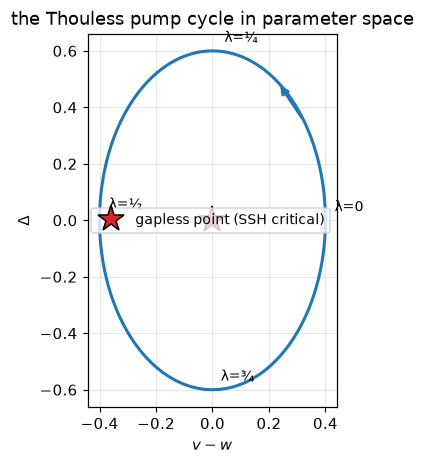

In [28]:
# the pump protocol seen in parameter space: the cycle must ENCIRCLE the
# gapless point (v - w, Delta) = (0, 0)
lam_c = np.linspace(0, 1, 200)
v_minus_w = 0.4 * np.cos(2 * np.pi * lam_c)          # v(λ) - w  (δ-modulation)
Delta_c = 0.6 * np.sin(2 * np.pi * lam_c)

fig, ax = plt.subplots(figsize=(4.8, 4.4))
ax.plot(v_minus_w, Delta_c, lw=2, color="C0")
ax.annotate("", xy=(v_minus_w[30], Delta_c[30]), xytext=(v_minus_w[20], Delta_c[20]),
            arrowprops=dict(arrowstyle="-|>", color="C0", lw=2))
ax.plot(0, 0, "*", ms=18, color="C3", mec="k", label="gapless point (SSH critical)")
for lv, name in [(0.0, "λ=0"), (0.25, "λ=¼"), (0.5, "λ=½"), (0.75, "λ=¾")]:
    i = int(lv * 199)
    ax.annotate(name, (v_minus_w[i], Delta_c[i]), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.set_xlabel(r"$v - w$"); ax.set_ylabel(r"$\Delta$")
ax.legend(fontsize=9); ax.set_aspect("equal")
ax.set_title("the Thouless pump cycle in parameter space")
plt.show()
caption("The pump protocol: over one period the dimerization (v − w) and the "
        "staggered onsite Δ trace a loop that encircles the SSH critical point "
        "(star), where the bulk gap would close. The pumped charge equals the "
        "winding number of this loop around the star — which is why the off-center "
        "cycle of exercise I.5 pumps nothing. Enclosing a gapless point is to a "
        "pump what enclosing a solenoid is to an Aharonov–Bohm phase.")

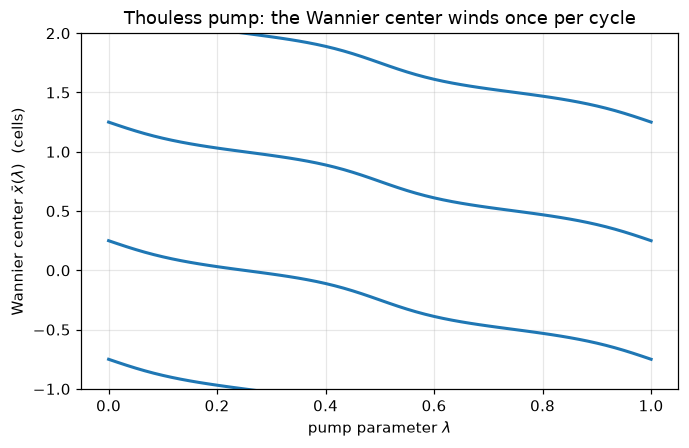

Wannier winding over one cycle: -1.000000
Chern number on the (k,λ) torus: +1.000000
[PASS] pumped charge is exactly one electron per cycle


True

In [29]:
# Rice-Mele pump: parameters as callables of lmbda
t0, d0, D0 = 1.0, 0.4, 0.6
lat_rm = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.5]], periodic_dirs=[0])
rm = TBModel(lat_rm)
rm.set_onsite([lambda lmbda: -D0 * np.sin(2 * np.pi * lmbda),
               lambda lmbda: +D0 * np.sin(2 * np.pi * lmbda)])
rm.set_hop(lambda lmbda: t0 + d0 * np.cos(2 * np.pi * lmbda), 0, 1, [0])
rm.set_hop(t0, 1, 0, [1])

mesh = Mesh(["k", "l"], axis_names=["k", "lmbda"])
mesh.build_grid(shape=(41, 61), k_endpoints=True,
                lambda_start=0.0, lambda_stop=1.0, lambda_endpoints=True)
mesh.loop(axis_idx=1, component_idx=1, closed=True)     # λ-axis is a closed cycle
wfa = WFArray(lat_rm, mesh)
wfa.solve_model(rm)

lam = mesh.get_axis_range(1, 1)
xbar = np.array(wfa.berry_phase(axis_idx=0, state_idx=[0], contin=True)) / (2 * np.pi)

fig, ax = plt.subplots()
for shift in (-1, 0, 1, 2):
    ax.plot(lam, xbar + shift, "C0-", lw=2)
ax.set_xlabel(r"pump parameter $\lambda$")
ax.set_ylabel(r"Wannier center $\bar x(\lambda)$  (cells)")
ax.set_ylim(-1, 2)
ax.set_title("Thouless pump: the Wannier center winds once per cycle")
plt.show()
caption("Wannier-center flow over one pump cycle (several unit cells shown). The "
        "charge center advances smoothly and ends one full lattice constant from "
        "where it started: exactly one electron per cell has been transported, "
        "with no bias voltage — quantized by the Chern number of the (k, λ) torus, "
        "not by any fine-tuning of the drive.")

winding = xbar[-1] - xbar[0]
C_pump = float(wfa.chern_number(plane=(0, 1), state_idx=[0]))
print(f"Wannier winding over one cycle: {winding:+.6f}")
print(f"Chern number on the (k,λ) torus: {C_pump:+.6f}")
check("pumped charge is exactly one electron per cycle",
      np.isclose(abs(winding), 1.0, atol=1e-6) and np.isclose(abs(C_pump), 1.0, atol=1e-6))

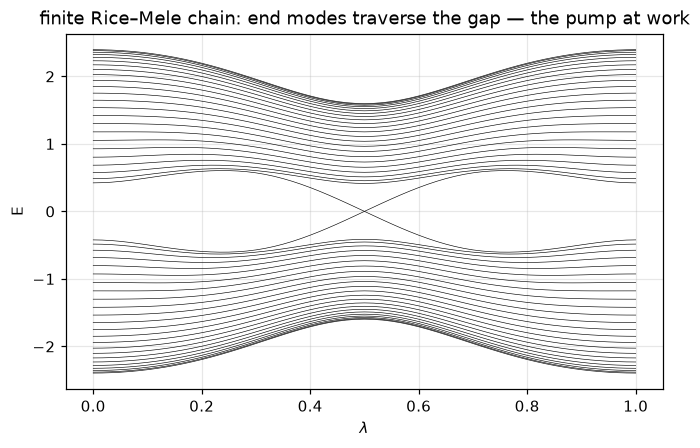

[PASS] spectrum is periodic in λ


True

In [30]:
# the pump seen in a finite chain: end-state energies must cross the gap as λ advances
# (charge has to physically arrive at the boundary)
n_lam = 61
lam_fine = np.linspace(0, 1, n_lam)
spec = []
for lv in lam_fine:
    m_l = rm.with_parameters(lmbda=lv).cut_piece(24, 0)
    spec.append(m_l.solve_ham())
spec = np.array(spec)

fig, ax = plt.subplots()
ax.plot(lam_fine, spec, "k-", lw=0.4)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("E")
ax.set_title("finite Rice–Mele chain: end modes traverse the gap — the pump at work")
plt.show()
caption("The pump seen from a finite chain: as λ advances, bound states peel off "
        "one band edge, cross the gap on the chain's ends, and merge into the other "
        "band. That gap traversal is how the transported charge physically enters "
        "and leaves the sample boundary — the spectral flow that MUST accompany a "
        "nonzero Chern number, here resolved state by state.")

# adiabatic-cycle sanity: spectrum returns to itself after a full period
check("spectrum is periodic in λ", np.allclose(spec[0], spec[-1], atol=1e-10))

## 11. Three dimensions

Nothing changes structurally in 3D — `Lattice` takes three vectors, k-points get three reduced
components, `cut_piece` turns a bulk crystal into a slab — but it is worth pausing on what *scales*:
a k-mesh now has $N^3$ points, and every Berry-flux or Chern calculation multiplies accordingly.
PythTB stays comfortable because tight-binding matrices stay small; the cost lives entirely in the
number of k-points (Part III measures it).

Below: the simple-cubic band $E(\mathbf k) = -2t(\cos K_x + \cos K_y + \cos K_z)$ checked against
the code, and its density of states with the van Hove singularities of a 3D cosine band. (For
interactive 3D structure views, `TBModel.visualize_3d()` renders the lattice with plotly if
installed; we stay with matplotlib here.)

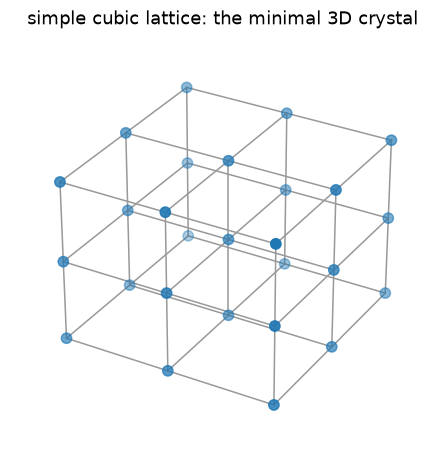

In [31]:
# the crystal itself: simple cubic, one orbital per site, six equal NN bonds
fig = plt.figure(figsize=(5.5, 5))
ax = fig.add_subplot(projection="3d")
pts = np.array([[i, j, k] for i in range(3) for j in range(3) for k in range(3)])
for p in pts:
    for d in np.eye(3, dtype=int):
        q = p + d
        if q.max() < 3:
            ax.plot(*zip(p, q), "-", color="0.6", lw=1)
ax.scatter(*pts.T, s=45, c="C0", depthshade=True)
ax.set_axis_off()
ax.set_title("simple cubic lattice: the minimal 3D crystal")
plt.show()
caption("The simple cubic lattice: one orbital per site, hopping −t along each of "
        "the three axes. Its band is the sum of three independent 1D cosine bands — "
        "the rare 3D problem with a closed-form answer, which is why it opens the "
        "3D part of this notebook as the analytic benchmark.")

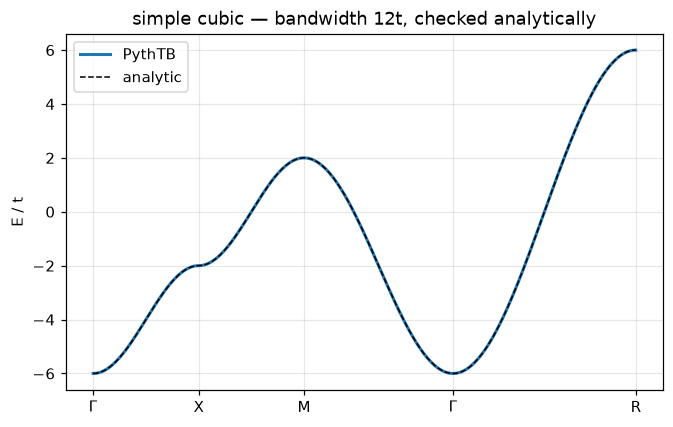

[PASS] simple-cubic band matches -2t Σ cos


True

In [32]:
# simple cubic crystal, one orbital
t = 1.0
lat_sc = Lattice(lat_vecs=np.eye(3), orb_vecs=[[0, 0, 0]], periodic_dirs=[0, 1, 2])
cubic = TBModel(lat_sc)
for d in range(3):
    R = [0, 0, 0]; R[d] = 1
    cubic.set_hop(-t, 0, 0, R)

CUBIC_NODES = [[0, 0, 0], [0.5, 0, 0], [0.5, 0.5, 0], [0, 0, 0], [0.5, 0.5, 0.5]]
CUBIC_LABELS = [r"$\Gamma$", "X", "M", r"$\Gamma$", "R"]
k_vec, k_dist, k_node = cubic.k_path(CUBIC_NODES, nk=301, report=False)
ev = cubic.solve_ham(k_vec)

E_exact = -2 * t * np.cos(2 * np.pi * k_vec).sum(axis=1)
fig, ax = plt.subplots()
ax.plot(k_dist, ev[:, 0], lw=2, label="PythTB")
ax.plot(k_dist, E_exact, "k--", lw=1, label="analytic")
ax.set_xticks(k_node, CUBIC_LABELS)
ax.set_ylabel("E / t")
ax.legend(); ax.set_title("simple cubic — bandwidth 12t, checked analytically")
plt.show()
caption("The simple-cubic band along a standard path. Reading it dimension by "
        "dimension: bandwidth 12t = 3 × 4t (one 4t per axis), minimum at Γ where "
        "all three cosines add, maximum at the zone corner R where all three "
        "subtract. Numerics and the analytic sum of cosines are indistinguishable.")

check("simple-cubic band matches -2t Σ cos", np.allclose(ev[:, 0], E_exact, atol=1e-12))

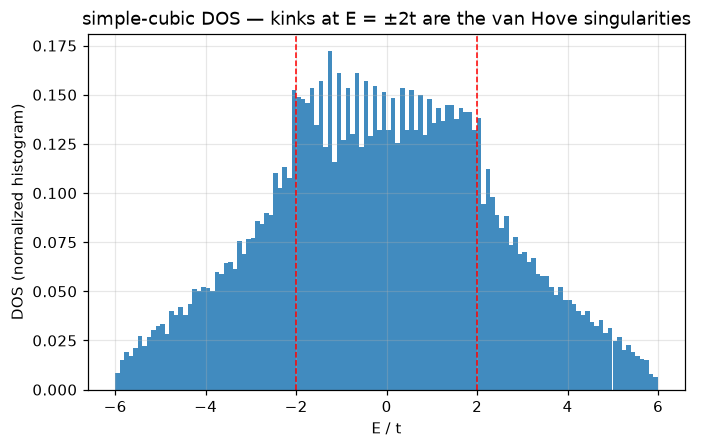

diagonalized 216,000 k-points in one vectorized call


In [33]:
# density of states on a full 3D mesh: van Hove singularities of the cosine band
k_mesh = cubic.k_uniform_mesh([60, 60, 60])
ev_mesh = cubic.solve_ham(k_mesh).ravel()

fig, ax = plt.subplots()
ax.hist(ev_mesh, bins=120, density=True, color="C0", alpha=0.85)
for E_vh in (-2 * t, 2 * t):
    ax.axvline(E_vh, color="r", ls="--", lw=1)
ax.set_xlabel("E / t")
ax.set_ylabel("DOS (normalized histogram)")
ax.set_title("simple-cubic DOS — kinks at E = ±2t are the van Hove singularities")
plt.show()
caption("Density of states from a histogram of 216,000 eigenvalues. In 3D the "
        "van Hove singularities are kinks (discontinuous slope) rather than the "
        "divergences of 2D — the dimensionality of a material is legible in the "
        "SHAPE of its DOS anomalies. The band edges at ±6t rise as √|E − E_edge|, "
        "the free-electron-like signature of a parabolic band minimum.")
print(f"diagonalized {len(ev_mesh):,} k-points in one vectorized call")

## 12. Real materials — importing Wannier90 models (`W90`)

Everything so far used hand-picked hoppings. The `W90` class is PythTB's bridge to *ab-initio*
reality: it reads the output of a [Wannier90](http://wannier.org) run (`prefix_hr.dat`,
`prefix.win`, `prefix_centres.xyz`, …) — i.e. a DFT band structure compressed into
maximally-localized Wannier functions — and returns an ordinary `TBModel`. Every tool in this
notebook then applies unchanged to a first-principles Hamiltonian.

The dataset in `data/w90_silicon/` (from the PythTB distribution) is **bulk silicon** with 8
Wannier functions (bonding + antibonding sp³ combinations) on a $10\times10\times10$ k-grid, in eV
and Å. Things to inspect before trusting an imported model:

1. **hopping decay** — `dist_hop()` shows $|t(r)|$ falling exponentially with distance; a slow decay
   means poorly localized Wannier functions and an untrustworthy truncation;
2. **truncation error** — `model(min_hopping_norm=…)` drops small hoppings; compare interpolated
   bands against the original Wannier90 bands (`bands_w90()`) to see what the cut costs;
3. the **Fermi level** — Wannier90 files carry absolute DFT energies; `zero_energy` re-references
   them.

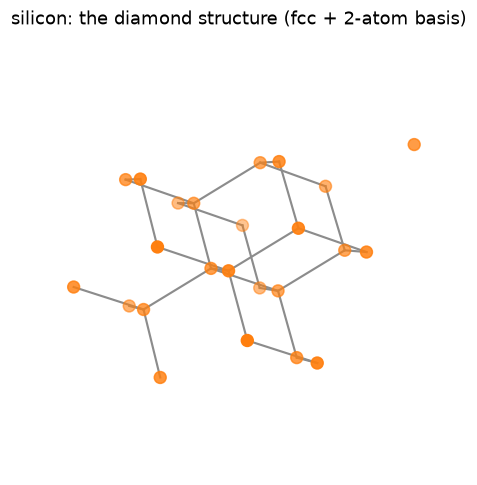

In [34]:
# the material: silicon crystallizes in the diamond structure — an fcc lattice
# with a two-atom basis, every atom tetrahedrally bonded to four neighbours
a1 = np.array([0.0, 0.5, 0.5]); a2 = np.array([0.5, 0.0, 0.5]); a3 = np.array([0.5, 0.5, 0.0])
basis = [np.zeros(3), 0.25 * (a1 + a2 + a3)]            # (0,0,0) and (1/4,1/4,1/4)
atoms = []
for i in range(-1, 2):
    for j in range(-1, 2):
        for k in range(-1, 2):
            R = i * a1 + j * a2 + k * a3
            for b in basis:
                atoms.append(R + b)
atoms = np.array(atoms)
keep = np.all((atoms > -0.3) & (atoms < 1.1), axis=1)
atoms = atoms[keep]

fig = plt.figure(figsize=(5.8, 5.2))
ax = fig.add_subplot(projection="3d")
d2a = np.sum((atoms[:, None, :] - atoms[None, :, :]) ** 2, axis=-1)
for i, j in zip(*np.where(np.abs(np.sqrt(d2a) - np.sqrt(3) / 4) < 1e-6)):
    if i < j:
        ax.plot(*zip(atoms[i], atoms[j]), "-", color="0.55", lw=1.4)
ax.scatter(*atoms.T, s=60, c="C1", depthshade=True)
ax.set_axis_off()
ax.set_title("silicon: the diamond structure (fcc + 2-atom basis)")
plt.show()
caption("The diamond structure of silicon: two interpenetrating fcc lattices, each "
        "atom bonded tetrahedrally to four neighbours. Four sp³ bonding orbitals per "
        "atom pair fill to make the valence bands; the Wannier90 dataset below "
        "compresses exactly those bands (plus four antibonding partners) into 8 "
        "localized functions whose hoppings PythTB reads back in.")

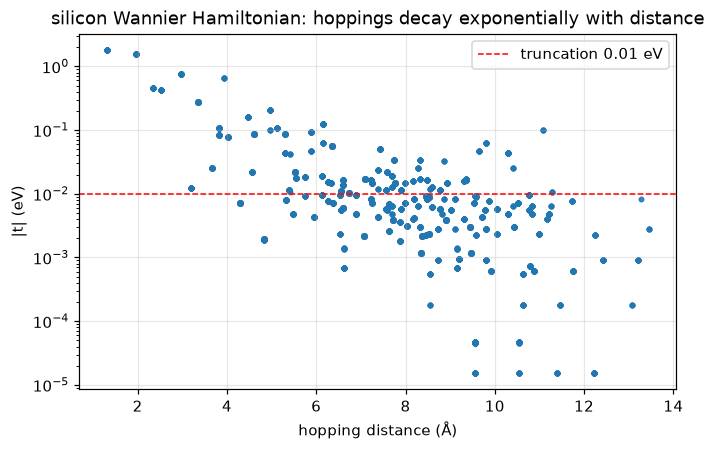

In [35]:
silicon = W90("data/w90_silicon", "si")
fermi_ev = 6.2285135          # DFT Fermi level of this calculation, in eV

dist, ham = silicon.dist_hop()
fig, ax = plt.subplots()
ax.scatter(dist, np.abs(ham), s=8, alpha=0.6)
ax.axhline(1e-2, color="r", ls="--", lw=1, label="truncation 0.01 eV")
ax.set_yscale("log")
ax.set_xlabel("hopping distance (Å)")
ax.set_ylabel("|t| (eV)")
ax.legend()
ax.set_title("silicon Wannier Hamiltonian: hoppings decay exponentially with distance")
plt.show()
caption("Every hopping matrix element of the silicon Wannier Hamiltonian versus "
        "bond length, on a log scale: five orders of magnitude of clean exponential "
        "decay. This is the numerical face of Kohn's 'nearsightedness' — gapped "
        "bands have exponentially localized Wannier functions — and it is what "
        "makes the truncation studied next a controlled approximation rather than "
        "a leap of faith.")

[PASS] untruncated import reproduces Wannier90 bands exactly — max deviation = 0.0145 meV


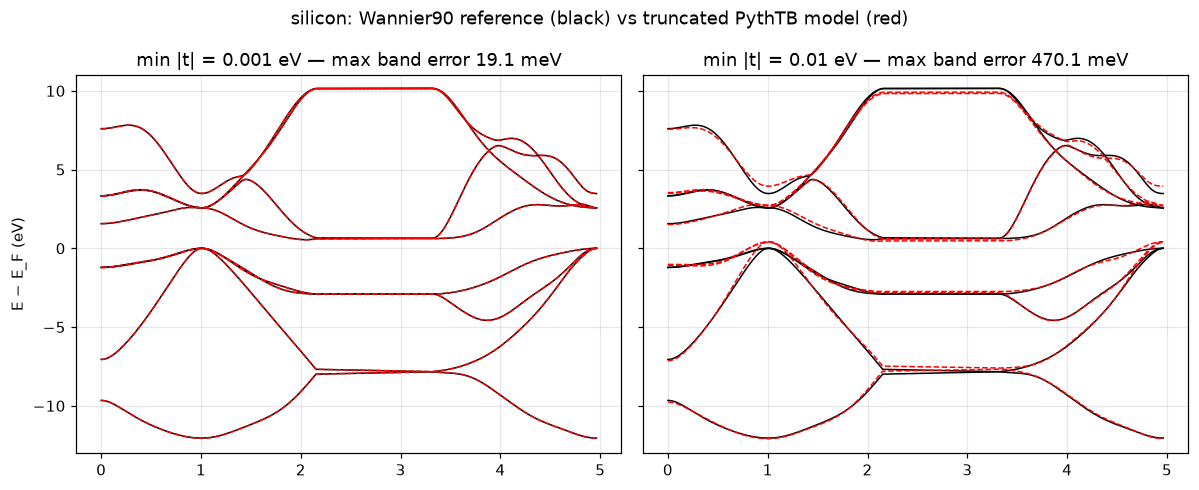

[PASS] 1 meV truncation keeps bands within ~20 meV — max error = 19.1 meV
[PASS] 10x coarser truncation degrades bands ~20x — 470 meV vs 19.1 meV


True

In [36]:
# import at two truncation levels and compare against the Wannier90 reference bands
w90_kpt, w90_evals, w90_k_dist, w90_k_nodes, w90_k_labels = silicon.bands_w90(
    return_k_dist=True, return_k_nodes=True)

# untruncated import first: at Wannier90's own k-points the model must be EXACT
model_full = silicon.model(zero_energy=fermi_ev)
err_full = np.abs(model_full.solve_ham(w90_kpt) - (w90_evals - fermi_ev)).max()
check("untruncated import reproduces Wannier90 bands exactly", err_full < 1e-4,
      f"max deviation = {1000*err_full:.4f} meV")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
errors = {}
for ax, cut in zip(axs, (1e-3, 1e-2)):
    model_si = silicon.model(zero_energy=fermi_ev, min_hopping_norm=cut)
    int_evals = model_si.solve_ham(w90_kpt)
    err = np.abs(int_evals - (w90_evals - fermi_ev)).max()
    errors[cut] = err
    ax.plot(w90_k_dist, w90_evals - fermi_ev, "k-", lw=1)
    ax.plot(w90_k_dist, int_evals, "r--", lw=1)
    ax.set_title(f"min |t| = {cut} eV — max band error {1000*err:.1f} meV")
    ax.set_ylim(-13, 11)
axs[0].set_ylabel("E − E_F (eV)")
fig.suptitle("silicon: Wannier90 reference (black) vs truncated PythTB model (red)")
fig.tight_layout()
plt.show()
caption("First-principles silicon bands (black) against the truncated tight-binding "
        "model (red dashed) at two truncation levels. Keeping hoppings down to 1 meV "
        "reproduces DFT to ~20 meV across 8 bands and 17 eV of bandwidth — from a "
        "Hamiltonian with a few hundred numbers. The right panel shows the price of "
        "an aggressive cut: the conduction bands, whose Wannier functions spread "
        "further, degrade first (quantified in exercise I.6).")

check("1 meV truncation keeps bands within ~20 meV", errors[1e-3] < 0.05,
      f"max error = {1000*errors[1e-3]:.1f} meV")
check("10x coarser truncation degrades bands ~20x", errors[1e-2] > 5 * errors[1e-3],
      f"{1000*errors[1e-2]:.0f} meV vs {1000*errors[1e-3]:.1f} meV")

In [37]:
# a first-principles model is a TBModel like any other: Berry machinery applies as-is.
# Berry phase of the 4 valence bands along k_z at (kx,ky)=(0,0) — quantized to 0 or π
# by the inversion symmetry of the diamond structure.
model_si = silicon.model(zero_energy=fermi_ev, min_hopping_norm=1e-2)

mesh = Mesh(["k", "k", "k"])
mesh.build_grid([6, 6, 31], k_endpoints=[False, False, True])
wfa_si = WFArray(model_si.lattice, mesh)
wfa_si.solve_model(model_si)
phi_z = wfa_si.berry_phase(axis_idx=2, state_idx=[0, 1, 2, 3])   # over (kx,ky) grid
phi_00 = float(np.atleast_2d(np.squeeze(phi_z))[0, 0])
print(f"valence-band Berry phase along k_z at k_perp=0: φ = {phi_00:+.6f}")
dist_to_quant = min(abs(phi_00 % np.pi), np.pi - abs(phi_00 % np.pi))
check("silicon valence Berry phase quantized by inversion symmetry",
      dist_to_quant < 1e-3, f"distance from multiple of π: {dist_to_quant:.2e}")

valence-band Berry phase along k_z at k_perp=0: φ = -0.000089
[PASS] silicon valence Berry phase quantized by inversion symmetry — distance from multiple of π: 8.94e-05


True

## 13. Wannierization *inside* PythTB — the `Wannier` class

PythTB 2.0 closes a loop that used to require Wannier90 itself: starting from Bloch states in a
`WFArray`, the `Wannier` class **projects onto trial orbitals, disentangles, and maximally
localizes** Wannier functions — the Marzari–Vanderbilt $\Omega$ minimization — entirely in Python.

We test it where the answer is known exactly (§9): the trivial-phase SSH occupied band has its
Wannier center on the intracell bond, $\bar x = 0.25$, and the Wannier function must decay
exponentially. The workflow: `project(tf_list, band_idxs)` → `maxloc()` → inspect `spread`,
`centers`, real-space decay.

In [38]:
# Wannierize the occupied band of the trivial SSH chain
m = ssh_model(1.0, 0.5)
mesh = Mesh(["k"])
mesh.build_grid([60])                      # full BZ grid, no duplicate endpoint
wfa = WFArray(m.lattice, mesh)
wfa.solve_model(m)

WF = Wannier(wfa)
WF.project([[(0, 1)]], band_idxs=[0])      # trial wf: orbital 0 of the cell
print("after projection:")
WF.info()
WF.maxloc(max_iter=2000, tol=1e-12, grad_min=1e-12, verbose=False)
print("\nafter maximal localization:")
WF.info()

centers = np.atleast_2d(WF.centers)
xbar_wf = float(centers[0, 0]) % 1.0
print(f"\nWannier center from localization: {xbar_wf:.6f}  (Berry phase in §9 gave 0.250000)")
check("maxloc Wannier center agrees with the Berry phase",
      np.isclose(xbar_wf, 0.25, atol=1e-3), f"x̄ = {xbar_wf:.6f}")

after projection:
Wannier Function Report
WF 1: center = [0.25000000]  Omega     = 0.14553548
Sum : center = [0.25000000]  Omega tot = 0.14553548
---------------------------------------------------
Omega I   = 0.10395324
Omega D   = 0.04158225
Omega OD  = 0.00000000
Omega tot = 0.14553548



after maximal localization:
Wannier Function Report
WF 1: center = [0.25000000]  Omega     = 0.10395377
Sum : center = [0.25000000]  Omega tot = 0.10395377
---------------------------------------------------
Omega I   = 0.10395324
Omega D   = 0.00000054
Omega OD  = 0.00000000
Omega tot = 0.10395377

Wannier center from localization: 0.250000  (Berry phase in §9 gave 0.250000)
[PASS] maxloc Wannier center agrees with the Berry phase — x̄ = 0.250000


True

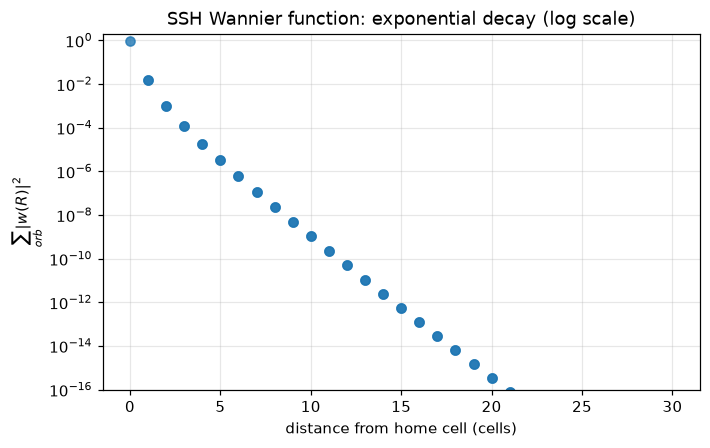

[PASS] Wannier function decays exponentially — decay rate = -1.86 per cell


True

In [39]:
# real-space profile of the Wannier function. WF.wannier holds the amplitudes with
# shape (n_cells, n_wf, n_orb); the built-in WF.plot_decay assumes >= 2D lattices,
# so for this 1D chain we plot the decay ourselves.
w_amp = np.asarray(WF.wannier)[:, 0, :]            # (n_cells, n_orb)
n_cells = w_amp.shape[0]
cell_dist = np.minimum(np.arange(n_cells), n_cells - np.arange(n_cells))  # wrap
dens_cell = (np.abs(w_amp) ** 2).sum(axis=1)

fig, ax = plt.subplots()
ax.semilogy(cell_dist, dens_cell, "o", alpha=0.8)
ax.set_xlabel("distance from home cell (cells)")
ax.set_ylabel(r"$\sum_{orb} |w(R)|^2$")
ax.set_ylim(1e-16, 2)
ax.set_title("SSH Wannier function: exponential decay (log scale)")
plt.show()
caption("Real-space profile of the maximally-localized Wannier function built by "
        "PythTB's own Wannier engine from the SSH Bloch states: exponential decay "
        "over ten orders of magnitude, centred on the strong bond. The decay rate is "
        "set by the gap — shrink the gap and the Wannier function fattens, which is "
        "the localization-topology trade-off behind everything in Part II.")

# a gapped 1D insulator must have exponentially localized Wannier functions:
# fit log-density vs distance over the first decade and require a negative slope
mask = (cell_dist >= 1) & (cell_dist <= 8) & (dens_cell > 1e-14)
slope = np.polyfit(cell_dist[mask], np.log(dens_cell[mask]), 1)[0]
check("Wannier function decays exponentially", slope < -1.0,
      f"decay rate = {slope:.2f} per cell")

## Exercises for Part I

Worked solutions are in `PythTB_Exercises_Solutions.ipynb`.

**I.1 — The trestle.** Build the classic PythTB "trestle" model: a 1D chain with two orbitals per
cell at heights 0 and 0.5 in a non-periodic second direction, first-neighbour hopping $t$ along the
chain and diagonal hoppings $t'$ between the rails. Plot the two bands and find the $t'/t$ ratio at
which the gap at the zone boundary closes.

**I.2 — Breaking particle–hole symmetry.** Add a second-neighbour hopping $t' = 0.1t$ to graphene
(six bonds per sublattice). Show that the Dirac points survive but move away from $E = 0$, and
compute the new energy of the band touching. Why does the *existence* of the touching not care
about $t'$?

**I.3 — (Non-)fragility of flat bands.** Perturb the Lieb lattice two ways: (a) a direct
corner–corner hopping $t_2$ across the square, (b) a diagonal edge–edge hopping $t_2$. One of them
leaves the flat band *exactly* flat and the other disperses it — predict which before computing,
explain why in terms of where the flat-band states live, and find the $t_2/t$ at which the
dispersing case reaches a bandwidth of 10% of the main gap.

**I.4 — Polarization of BN.** For the boron-nitride model at fixed $|Δ|$, compute the Berry phase
of the valence band along $k_1$ as a function of $k_2$ for both signs of $Δ$. The polarization
jump is quantized — but is it $e/2$, as a naive "half a quantum per band inversion" guess would
say? Determine the exact fraction and connect it to the $C_3$-pinned Wyckoff positions of the
valence Wannier center on the honeycomb.

**I.5 — A pump that pumps nothing.** Modify the Rice–Mele cycle so the $(v-w, \Delta)$ loop does
*not* enclose the origin (e.g. $\Delta(\lambda) = \Delta_0[1.5 + \sin 2\pi\lambda]$). Show the
Wannier-center flow now winds zero times and the $(k,\lambda)$ Chern number vanishes.

**I.6 — Silicon conduction bands.** The 8-band silicon model of §12 also contains 4 antibonding
bands. Quantify how much worse the Wannier interpolation is for the conduction bands than for the
valence bands (compare against `bands_w90()`), and explain why in terms of the disentanglement
window used to generate the data.

# Part II — Topological matter

PythTB's topological toolkit is the mirror image of Kwant's: no transport, but a complete
Berry-phase arsenal — and in 2.0, one-call invariants (`chern_number`, `berry_curvature`,
`axion_angle`, `local_chern_marker`) that classic PythTB users had to assemble by hand.

## 14. The Haldane model — a Chern insulator without Landau levels

Haldane (1988): take graphene, add a staggered onsite $\pm\Delta$ (breaks inversion) and a
*complex* second-neighbour hopping $t_2 e^{i\phi}$ (breaks time reversal without net flux). The
Bloch Hamiltonian $H(\mathbf k) = \mathbf d(\mathbf k)\cdot\boldsymbol\sigma + d_0$ defines a map
from the BZ torus to the Bloch sphere whose wrapping number — the **Chern number**
$$
C = \frac{1}{2\pi}\int_{BZ} \Omega(\mathbf k)\, d^2k, \qquad
\Omega = -2\,\mathrm{Im}\,\langle \partial_{k_x} u | \partial_{k_y} u\rangle
$$
— is $\pm 1$ when the $t_2$ term dominates ($|\Delta| < 3\sqrt{3}\,|t_2 \sin\phi|$) and $0$ when
the mass term does. $C \neq 0$ means quantized Hall conductance $\sigma_{xy} = C e^2/h$ and chiral
edge states — bulk-boundary correspondence we verify on a ribbon.

We compute $C$ three independent ways (plaquette Berry fluxes on a `WFArray`, the model-level
`chern_number` with automatic differentiation of $H(\mathbf k)$, and integration of
`berry_curvature`), then map the phase diagram and the **local Chern marker** — a real-space
version of $C$ that works where $\mathbf k$ does not exist (disordered or finite samples).

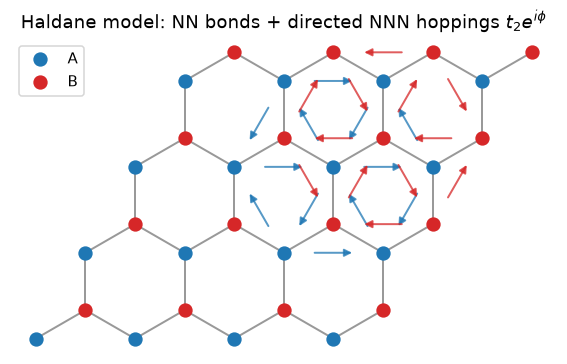

In [40]:
# the Haldane model's ingredients, drawn: NN bonds (solid) plus DIRECTED
# second-neighbour hoppings t2*e^{i*phi} (arrows) whose circulation encloses
# flux without any net field through the cell
E1h = np.array([1.0, 0.0]); E2h = np.array([0.5, np.sqrt(3) / 2])
tauA = (E1h + E2h) / 3; tauB = 2 * (E1h + E2h) / 3
cells = [(i, j) for i in range(-1, 3) for j in range(-1, 3)]
A_pts = np.array([i * E1h + j * E2h + tauA for i, j in cells])
B_pts = np.array([i * E1h + j * E2h + tauB for i, j in cells])

fig, ax = plt.subplots(figsize=(6.4, 5.6))
for a in A_pts:                                        # NN bonds
    for b in B_pts:
        if abs(np.sum((a - b) ** 2) - 1 / 3) < 1e-6:
            ax.plot([a[0], b[0]], [a[1], b[1]], "-", color="0.6", lw=1.3, zorder=1)
for pts, col, sgn in ((A_pts, "C0", +1), (B_pts, "C3", -1)):   # NNN arrows
    for p in pts:
        for d in (E1h, E2h - E1h, -E2h):
            q = p + sgn * d
            if np.linalg.norm(q - 1.5 * (E1h + E2h)) < 1.35 and                np.linalg.norm(p - 1.5 * (E1h + E2h)) < 1.35:
                ax.annotate("", xy=0.72 * q + 0.28 * p, xytext=0.28 * q + 0.72 * p,
                            arrowprops=dict(arrowstyle="-|>", color=col, lw=1.3,
                                            alpha=0.75))
ax.scatter(A_pts[:, 0], A_pts[:, 1], s=70, c="C0", zorder=3, label="A")
ax.scatter(B_pts[:, 0], B_pts[:, 1], s=70, c="C3", zorder=3, label="B")
ax.legend(loc="upper left")
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(r"Haldane model: NN bonds + directed NNN hoppings $t_2 e^{i\phi}$")
plt.show()
caption("The Haldane model's key ingredient: complex second-neighbour hoppings "
        "whose positive-phase direction circulates counter-clockwise around A "
        "sublattice triangles (blue arrows) and clockwise around B (red). An "
        "electron hopping around one small triangle picks up phase φ, around a full "
        "hexagon zero — a staggered magnetic flux pattern that breaks time-reversal "
        "with NO net field, which is why this is a 'quantum Hall effect without "
        "Landau levels'.")

In [41]:
from pythtb.models import haldane

delta, t1, t2, phi = 0.2, -1.0, 0.15, np.pi / 2
hal = haldane(delta=delta, t1=t1, t2=t2, phi=phi)

# route 1: berry curvature as plaquette fluxes on a WFArray grid
mesh = Mesh(["k", "k"])
mesh.build_grid((41, 41), k_endpoints=[True, True])
wfa = WFArray(hal.lattice, mesh)
wfa.solve_model(hal)
C_flux = float(wfa.chern_number(plane=(0, 1), state_idx=[0]))

# route 2: model-level chern_number (differentiates H(k) internally)
C_model = float(hal.chern_number(plane=(0, 1), nks=(41, 41), occ_idxs=[0]))

# route 3: integrate berry_curvature on an explicit mesh (reduced coordinates:
# the BZ is the unit square, so C = mean(Omega_reduced) / 2pi)
nk = 60
k_grid = hal.k_uniform_mesh([nk, nk], gamma_centered=False, include_endpoints=False)
omega = np.asarray(hal.berry_curvature(k_grid, occ_idxs=[0], plane=(0, 1)))
C_int = float(np.mean(omega) / (2 * np.pi))

print(f"Chern via plaquette fluxes : {C_flux:+.8f}")
print(f"Chern via model autodiff   : {C_model:+.8f}")
print(f"Chern via curvature mean   : {C_int:+.6f}")
check("three independent Chern routes agree on C = -1",
      np.isclose(C_flux, -1, atol=1e-6) and np.isclose(C_model, -1, atol=1e-4)
      and np.isclose(C_int, -1, atol=5e-2))

Chern via plaquette fluxes : -1.00000000
Chern via model autodiff   : -1.00000000
Chern via curvature mean   : -1.000000
[PASS] three independent Chern routes agree on C = -1


True

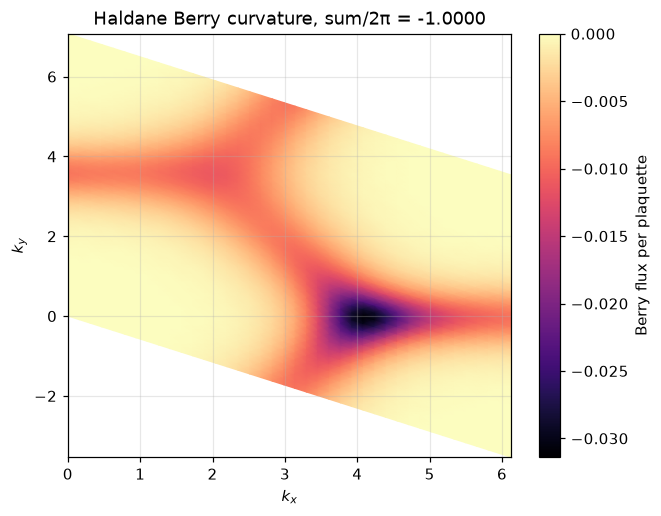

In [42]:
# Berry curvature is concentrated where the gap is smallest (near K and K')
bflux = wfa.berry_flux(plane=(0, 1), state_idx=[0])
k_cart = mesh.points @ hal.recip_lat_vecs
KX, KY = k_cart[..., 0], k_cart[..., 1]

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.pcolormesh(KX[:-1, :-1], KY[:-1, :-1], bflux, cmap="magma", shading="gouraud")
fig.colorbar(im, label=r"Berry flux per plaquette")
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_y$")
ax.set_title(f"Haldane Berry curvature, sum/2π = {bflux.sum()/(2*np.pi):+.4f}")
plt.show()
caption("Berry curvature of the occupied band over the Brillouin zone. It is not "
        "spread uniformly: it concentrates at the (gapped) Dirac points, where the "
        "band wavefunction twists fastest — each former Dirac cone contributes "
        "close to half the total. The integral over the BZ is quantized to −2π "
        "regardless of how the curvature is distributed: that rigidity IS the Chern "
        "number.")

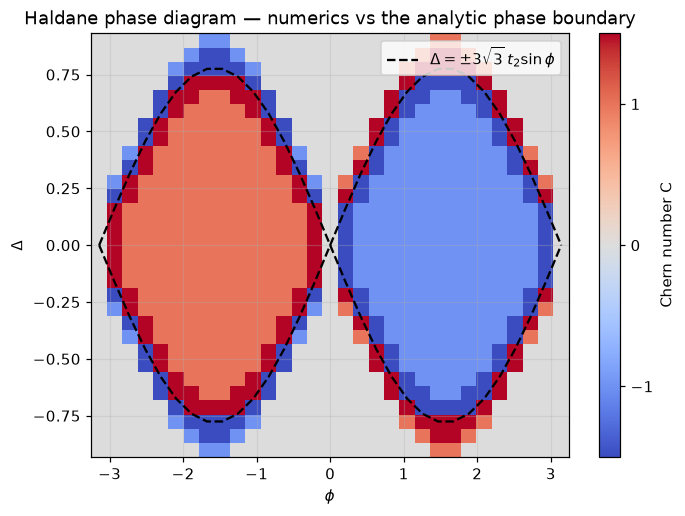

[PASS] phase diagram matches analytic boundary


True

In [43]:
# phase diagram: C over the (phi, delta) plane — the famous Haldane lobes.
# Grids are offset from delta = 0 so no point lands exactly ON the phase
# boundary, where the gap closes and C is undefined (pythtb raises there —
# correctly; we keep a NaN guard for near-critical points anyway).
n_phi, n_del = 31, 30
phis = np.linspace(-np.pi, np.pi, n_phi)
deltas = np.linspace(-0.9, 0.9, n_del)          # even count: skips delta = 0
C_map = np.full((n_del, n_phi), np.nan)
for i, dv in enumerate(deltas):
    for j, pv in enumerate(phis):
        try:
            C_map[i, j] = haldane(delta=dv, t1=t1, t2=t2, phi=pv).chern_number(
                plane=(0, 1), nks=(15, 15), occ_idxs=[0])
        except ZeroDivisionError:
            pass                                 # exactly critical: leave NaN

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.pcolormesh(phis, deltas, np.round(C_map), cmap="coolwarm",
                   shading="auto", vmin=-1.5, vmax=1.5)
crit = 3 * np.sqrt(3) * t2 * np.sin(phis)
ax.plot(phis, crit, "k--", lw=1.5, label=r"$\Delta = \pm 3\sqrt{3}\,t_2\sin\phi$")
ax.plot(phis, -crit, "k--", lw=1.5)
fig.colorbar(im, label="Chern number C", ticks=[-1, 0, 1])
ax.set_xlabel(r"$\phi$"); ax.set_ylabel(r"$\Delta$")
ax.legend(loc="upper right")
ax.set_title("Haldane phase diagram — numerics vs the analytic phase boundary")
plt.show()
caption("The Haldane phase diagram computed point by point: Chern number as a "
        "function of the TRS-breaking phase φ and the inversion-breaking mass Δ. "
        "The two competing masses fight at the two valleys independently, giving "
        "the celebrated lobes; the numerical boundary lands exactly on the analytic "
        "curve Δ = ±3√3 t₂ sin φ (dashed). Points ON the boundary have no Chern "
        "number at all — the gap is closed there, and PythTB rightly refuses.")

# quantitative: sample points well inside each lobe and outside
check("phase diagram matches analytic boundary",
      np.isclose(C_map[n_del//2, n_phi//4*3], -1, atol=1e-3)     # phi=pi/2, delta=0
      and np.isclose(C_map[n_del//2, n_phi//4], +1, atol=1e-3)    # phi=-pi/2
      and np.isclose(C_map[-1, n_phi//2], 0, atol=1e-3))          # large delta, phi=0

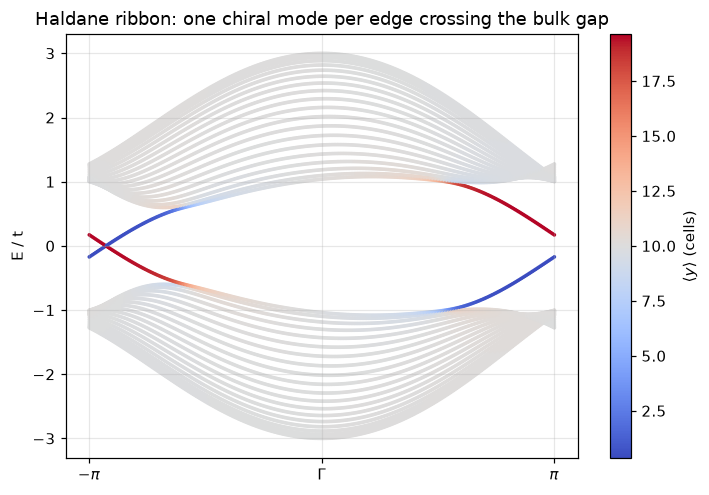

[PASS] two mid-gap states, localized on opposite edges — 13 k-points with 2 mid-gap states


True

In [44]:
# bulk-boundary correspondence: |C| chiral states per edge on a ribbon
rib = haldane(delta=delta, t1=t1, t2=t2, phi=phi).cut_piece(20, 1, glue_edges=False)
k_vec, k_dist, k_node = rib.k_path([[-0.5], [0.0], [0.5]], nk=301, report=False)
ev, vec = rib.solve_ham(k_vec, return_eigvecs=True)

# color states by where they live: <y> across the ribbon
y_op = rib.orb_vecs[:, 1]
y_exp = (np.abs(vec) ** 2 @ y_op).real            # (nk, nstate)

fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(np.repeat(k_dist, ev.shape[1]), ev.ravel(), c=y_exp.ravel(),
                s=2, cmap="coolwarm")
fig.colorbar(sc, label=r"$\langle y\rangle$ (cells)")
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.set_ylabel("E / t")
ax.set_title("Haldane ribbon: one chiral mode per edge crossing the bulk gap")
plt.show()
caption("Bulk-boundary correspondence, resolved in space: ribbon bands colored by "
        "the transverse position ⟨y⟩ of each state. The bulk bands (mixed colors) "
        "are gapped; two branches cross the gap, one confined to each edge (deep "
        "red / deep blue), with opposite velocities — chiral edge channels. Their "
        "number equals |C|, and no edge disorder can backscatter them: the "
        "counter-propagating partner lives on the other side of the sample.")

# mid-gap census: at k-points deep in the bulk gap there must be exactly two
# states (one per edge), and they must live on OPPOSITE edges
mid = np.abs(ev) < 0.1
k_two = np.where(mid.sum(axis=1) == 2)[0]
ok_pair = False
if len(k_two) > 0:
    kk = k_two[len(k_two) // 2]
    ys = y_exp[kk][mid[kk]]
    ok_pair = (ys.min() < y_op.mean()) and (ys.max() > y_op.mean())
check("two mid-gap states, localized on opposite edges",
      len(k_two) > 0 and ok_pair,
      f"{len(k_two)} k-points with 2 mid-gap states")

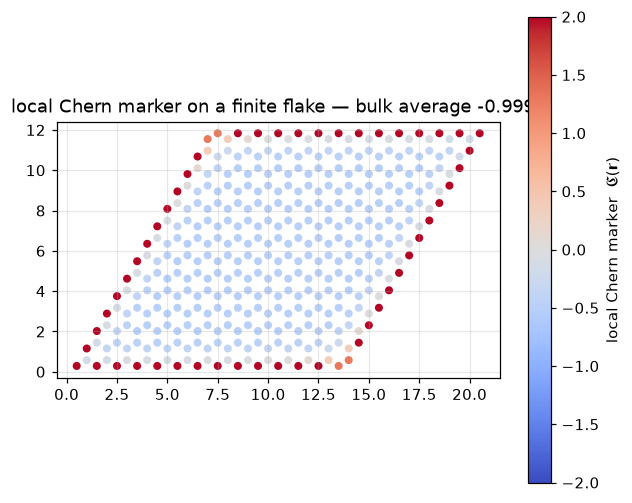

[PASS] local Chern marker bulk average matches C = -1 — <C>_bulk = -0.99949
[PASS] marker integrates to ~0 over the whole finite sample (it must) — sample mean = +0.0000


True

In [45]:
# the local Chern marker: real-space topology, no k-space needed
fin = haldane(delta=delta, t1=t1, t2=t2, phi=phi).make_finite(
    periodic_dirs=[0, 1], num_cells=[14, 14])
marker, bulk_avg = fin.local_chern_marker(return_bulk_avg=True, trim_cells=4)
pos = fin.orb_vecs @ fin.lat_vecs

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(pos[:, 0], pos[:, 1], c=marker, cmap="coolwarm", s=18,
                vmin=-2, vmax=2)
fig.colorbar(sc, label="local Chern marker  $\\mathfrak{C}(\\mathbf{r})$")
ax.set_aspect("equal")
ax.set_title(f"local Chern marker on a finite flake — bulk average {bulk_avg:+.4f}")
plt.show()
caption("The Chern number without k-space: the Bianco–Resta local marker evaluated "
        "on every site of a finite flake. Deep in the interior it locks to C = −1; "
        "at the boundary it swings hard positive so that the sample-wide average is "
        "exactly zero (the marker is a trace of a commutator). The edge is not "
        "noise — it is the same spectral flow that carries the chiral edge states.")

check("local Chern marker bulk average matches C = -1",
      np.isclose(bulk_avg, -1, atol=2e-2), f"<C>_bulk = {bulk_avg:+.5f}")
check("marker integrates to ~0 over the whole finite sample (it must)",
      abs(np.mean(marker)) < 0.1, f"sample mean = {np.mean(marker):+.4f}")

## 15. The Kane–Mele model — $\mathbb{Z}_2$ topology and the quantum spin Hall effect

Put two time-reversed copies of the Haldane model together — spin-up with $+\phi$, spin-down with
$-\phi$, realized microscopically by intrinsic spin–orbit coupling
$i\lambda_{SO} \nu_{ij} s_z$ on second-neighbour bonds — and the total Chern number vanishes while
each spin sector carries $C_\uparrow = -C_\downarrow = \pm1$. Time reversal ($T^2 = -1$) protects a
**$\mathbb{Z}_2$ invariant** that survives even when Rashba coupling destroys $s_z$ conservation.

The cleanest numerical diagnostic is **Wannier-center flow** (Soluyanov–Vanderbilt): track the
hybrid Wannier centers $\bar x_j(k_y)$ — the Wilson-loop eigenphases along $k_x$ — over half the BZ,
$k_y \in [0, \tfrac12]$. Kramers partners stick together at $k_y = 0, \tfrac12$ but may *switch
partners* in between: an odd number of switches (equivalently, an arbitrary horizontal line is
crossed an odd number of times) means $\mathbb{Z}_2$-nontrivial. This is exactly
`WFArray.berry_phase(..., berry_evals=True)`.

PythTB ships `pythtb.models.kane_mele(delta, t, soc, rashba)`; the topological phase lives at
$\Delta < 3\sqrt3\,\lambda_{SO}$ (for small Rashba).

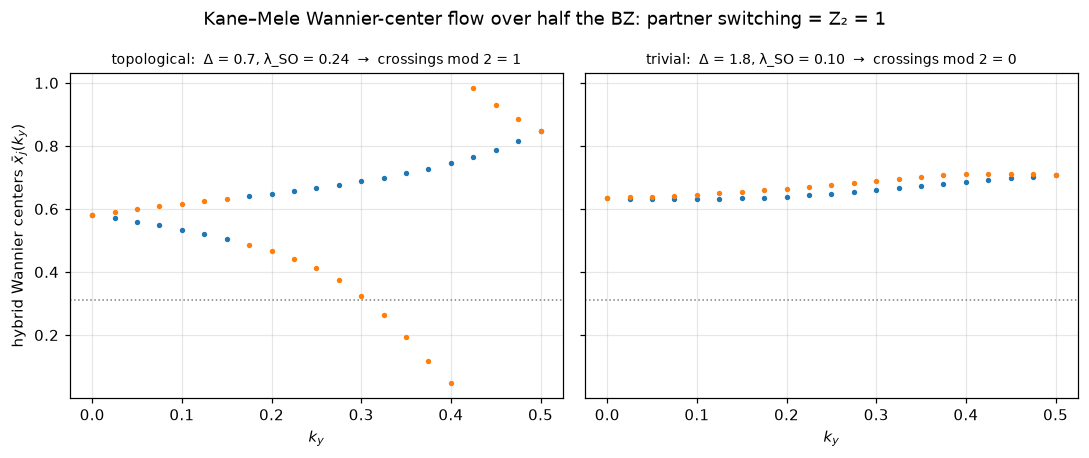

[PASS] WCC flow gives Z2 = 1 (topological) and Z2 = 0 (trivial)


True

In [46]:
from pythtb.models import kane_mele

def km_wcc_flow(delta, soc, rashba=0.25, nky=41):
    km = kane_mele(delta=delta, t=1.0, soc=soc, rashba=rashba)
    mesh = Mesh(["k", "k"])
    mesh.build_grid((51, nky), k_endpoints=[True, True])   # ky grid hits the TRIM at 1/2
    wfa = WFArray(km.lattice, mesh, spinful=True)
    wfa.solve_model(km)
    # Wilson eigenphases along kx for the two occupied bands, resolved in ky
    wcc = np.asarray(wfa.berry_phase(axis_idx=0, state_idx=[0, 1],
                                     berry_evals=True, contin=False)) / (2 * np.pi)
    ky = mesh.get_axis_range(1, 1)
    return ky, wcc % 1.0

def z2_from_wcc(w, ref):
    '''Count crossings of the reference line by Wannier centers over half the BZ.
    Centers live on a circle (mod 1): pair consecutive rows by minimal total arc
    displacement, then count minimal-arc crossings of ref. Returns parity (Z2).'''
    def arc(a, b):                                  # signed minimal displacement a->b
        return (b - a + 0.5) % 1.0 - 0.5
    crossings = 0
    for r in range(len(w) - 1):
        w1, w2 = w[r], w[r + 1]
        # two possible pairings of the two centers: keep the smoother one
        d_keep = [arc(w1[0], w2[0]), arc(w1[1], w2[1])]
        d_swap = [arc(w1[0], w2[1]), arc(w1[1], w2[0])]
        d = d_keep if sum(map(abs, d_keep)) <= sum(map(abs, d_swap)) else d_swap
        for a, dd in zip(w1, d):
            if dd > 0 and (ref - a) % 1.0 < dd:
                crossings += 1
            elif dd < 0 and (a - ref) % 1.0 < -dd:
                crossings += 1
    return crossings % 2, crossings

fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
cases = [("topological:  Δ = 0.7, λ_SO = 0.24", 0.7, 0.24),
         ("trivial:  Δ = 1.8, λ_SO = 0.10", 1.8, 0.10)]
z2 = {}
for ax, (title, dv, soc) in zip(axs, cases):
    ky, wcc = km_wcc_flow(dv, soc)
    half = ky <= 0.5 + 1e-9
    for j in range(wcc.shape[1]):
        ax.plot(ky[half], wcc[half, j], "o", ms=2.5)
    # Z2 = parity of WCC crossings of a reference line over half the BZ
    ref = 0.31
    z2[title], crossings = z2_from_wcc(wcc[half], ref)
    ax.axhline(ref, color="gray", ls=":", lw=1)
    ax.set_title(f"{title}  →  crossings mod 2 = {crossings % 2}", fontsize=9)
    ax.set_xlabel(r"$k_y$")
axs[0].set_ylabel(r"hybrid Wannier centers $\bar x_j(k_y)$")
fig.suptitle("Kane–Mele Wannier-center flow over half the BZ: partner switching = Z₂ = 1")
fig.tight_layout()
plt.show()
caption("The Z₂ diagnostic: hybrid Wannier centers x̄(ky) of the two occupied bands, "
        "followed over half the Brillouin zone. At the time-reversal-invariant "
        "momenta ky = 0 and ½ the centers come in Kramers-degenerate pairs; in "
        "between they may exchange partners. Left: the pair switches — any "
        "reference line (dotted) is crossed an odd number of times, Z₂ = 1. Right: "
        "the centers return to their partners, even crossings, trivial. This "
        "counting is gauge-invariant and needs no symmetry beyond time reversal.")

check("WCC flow gives Z2 = 1 (topological) and Z2 = 0 (trivial)",
      z2[cases[0][0]] == 1 and z2[cases[1][0]] == 0)

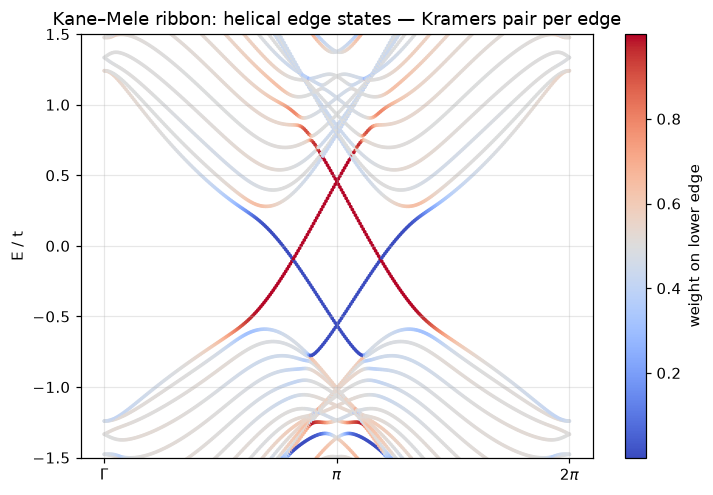

[PASS] one helical state per edge at generic in-gap k (partner at -k) — max in-gap states at one k: 2
[PASS] edge states traverse the bulk gap — in-gap states span 99% of the gap window


True

In [47]:
# helical edge states: ribbon of the topological Kane-Mele model
km = kane_mele(delta=0.7, t=1.0, soc=0.24, rashba=0.25)
rib = km.cut_piece(14, 1, glue_edges=False)
k_vec, k_dist, k_node = rib.k_path([[0.0], [0.5], [1.0]], nk=301, report=False)
ev, vec = rib.solve_ham(k_vec, return_eigvecs=True)

y_op = np.repeat(rib.orb_vecs[:, 1], 2)          # spinful: 2 states per orbital
edge_weight = np.einsum("kno,o->kn", np.abs(vec) ** 2, (y_op < y_op.mean()).astype(float))

fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(np.repeat(k_dist, ev.shape[1]), ev.ravel(), c=edge_weight.ravel(),
                s=2, cmap="coolwarm")
fig.colorbar(sc, label="weight on lower edge")
ax.set_xticks(k_node, [r"$\Gamma$", r"$\pi$", r"$2\pi$"])
ax.set_ylabel("E / t")
ax.set_ylim(-1.5, 1.5)
ax.set_title("Kane–Mele ribbon: helical edge states — Kramers pair per edge")
plt.show()
caption("Kane–Mele ribbon bands colored by weight on the lower edge. Unlike the "
        "Haldane chiral edge (one direction per edge), each edge here carries TWO "
        "counter-propagating modes forming a Kramers pair with opposite spins — "
        "helical states. Time reversal forbids elastic backscattering between "
        "Kramers partners, so the edges conduct perfectly as long as TRS holds; "
        "a magnetic impurity would break the protection.")

# helical counting. At a FIXED k inside the bulk gap a QSH ribbon has exactly
# one edge state per edge (its Kramers partner lives at -k): two in-gap states,
# and they traverse the whole gap as k varies — that is the helical signature.
evb = km.solve_ham(km.k_uniform_mesh([40, 40]))
gap_lo, gap_hi = evb[:, 1].max(), evb[:, 2].min()
ingap = (ev > gap_lo + 0.02) & (ev < gap_hi - 0.02)
counts = ingap.sum(axis=1)
E_ingap = ev[ingap]
span = (E_ingap.max() - E_ingap.min()) / (gap_hi - gap_lo - 0.04)
check("one helical state per edge at generic in-gap k (partner at -k)",
      counts.max() == 2 and (counts == 2).sum() > 20,
      f"max in-gap states at one k: {counts.max()}")
check("edge states traverse the bulk gap", span > 0.9,
      f"in-gap states span {100*span:.0f}% of the gap window")

## 16. The BHZ model — the quantum spin Hall quantum well, on a lattice

Bernevig–Hughes–Zhang (2006) predicted the first *observed* topological insulator: HgTe/CdTe
quantum wells. Kwant's tutorial discretizes the continuum $\mathbf{k}\cdot\mathbf{p}$ BHZ
Hamiltonian; PythTB has no discretizer (Part IV, §27), so we do what a tight-binder does — write
the standard **lattice regularization** directly on a square lattice with two orbitals
($s$, $p$) per spin:
$$
H(\mathbf k) = \begin{pmatrix} h(\mathbf k) & 0 \\ 0 & h^*(-\mathbf k)\end{pmatrix},\qquad
h(\mathbf k) = A\sin K_x\,\sigma_x + A\sin K_y\,\sigma_y +
\bigl[M - 2B(2 - \cos K_x - \cos K_y)\bigr]\sigma_z .
$$
Band inversion — and $\mathbb{Z}_2 = 1$ — occurs for $0 < M/B < 8$; $M$ is the well-thickness
knob of the experiment. Written out: the $\sigma_z\otimes s_0$ mass terms are orbital onsites and
spin-scalar hops, $A\sin K_x\,\sigma_x\otimes s_z$ and $A\sin K_y\,\sigma_y\otimes s_0$ are
orbital-off-diagonal hops with spin matrices — exactly the kind of term `set_hop` takes as a
$2\times2$ spin matrix.

In [48]:
def bhz(M, A=1.0, B=1.0):
    '''Lattice-regularized BHZ model, spinful, orbitals s and p at the same site.'''
    s0 = np.eye(2); sz = np.diag([1.0, -1.0])
    lat = Lattice(lat_vecs=[[1, 0], [0, 1]], orb_vecs=[[0, 0], [0, 0]],
                  periodic_dirs=[0, 1])
    m = TBModel(lat, spinful=True)
    # mass terms: (M - 4B) sigma_z onsite, +B sigma_z hops along x and y
    m.set_onsite([[(M - 4 * B), 0, 0, 0], [-(M - 4 * B), 0, 0, 0]])
    for R in ([1, 0], [0, 1]):
        m.set_hop(B * s0, 0, 0, R)
        m.set_hop(-B * s0, 1, 1, R)
    # A sin Kx sigma_x (orbital) x s_z (spin):  t01([1,0]) = A sz / 2i
    m.set_hop(A / (2j) * sz, 0, 1, [1, 0])
    m.set_hop(-A / (2j) * sz, 0, 1, [-1, 0], allow_conjugate_pair=True)
    # A sin Ky sigma_y (orbital) x s_0:  H01 = -iA sin Ky
    m.set_hop(-A / 2 * s0, 0, 1, [0, 1])
    m.set_hop(A / 2 * s0, 0, 1, [0, -1], allow_conjugate_pair=True)
    return m

# sanity: analytic spectrum E = +-|d(k)| twice (Kramers)
M_topo, M_triv = 1.0, -1.0
mb = bhz(M_topo)
k_test = rng.random((30, 2))
K = 2 * np.pi * k_test
d = np.stack([np.sin(K[:, 0]), np.sin(K[:, 1]),
              M_topo - 2 * 1.0 * (2 - np.cos(K[:, 0]) - np.cos(K[:, 1]))], axis=1)
E_analytic = np.sort(np.concatenate([np.linalg.norm(d, axis=1)[:, None] * s
                                     for s in (-1, -1, 1, 1)], axis=1), axis=1)
ev = np.sort(mb.solve_ham(k_test), axis=1)
check("lattice BHZ reproduces the analytic |d(k)| spectrum",
      np.allclose(ev, E_analytic, atol=1e-10),
      f"max dev = {np.abs(ev - E_analytic).max():.2e}")

[PASS] lattice BHZ reproduces the analytic |d(k)| spectrum — max dev = 2.66e-15


True

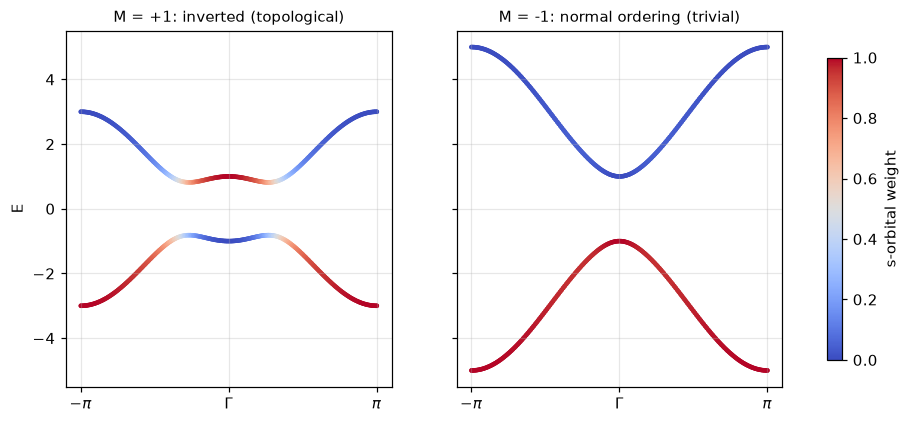

In [49]:
# the experiment's knob, visualized: BAND INVERSION. Color the bands by their
# s-orbital weight — in the trivial phase the s band stays above the p band
# everywhere; in the topological phase their characters have SWAPPED near Γ.
fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, Mv, tag in ((axs[0], 1.0, "M = +1: inverted (topological)"),
                    (axs[1], -1.0, "M = -1: normal ordering (trivial)")):
    m = bhz(Mv)
    k_vec, k_dist, k_node = m.k_path([[-0.5, 0], [0, 0], [0.5, 0]], nk=201, report=False)
    ev_i, vec_i = m.solve_ham(k_vec, return_eigvecs=True)
    # weight on orbital 0 (the 's' band): spinful states are (norb x 2) flattened
    w_s = (np.abs(vec_i) ** 2).reshape(len(k_vec), 4, 2, 2)[:, :, 0, :].sum(-1)
    sc = ax.scatter(np.repeat(k_dist, 4), ev_i.ravel(), c=w_s.ravel(), s=4,
                    cmap="coolwarm", vmin=0, vmax=1)
    ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
    ax.set_title(tag, fontsize=10)
axs[0].set_ylabel("E")
fig.colorbar(sc, ax=axs, label="s-orbital weight", shrink=0.85)
plt.show()
caption("Band inversion, the mechanism behind the BHZ prediction: bands along "
        "kx colored by s-orbital character. For M < 0 (right) the s-like band "
        "(red) lies entirely above the p-like band (blue) — an ordinary "
        "semiconductor. For M > 0 (left) the characters are exchanged in a "
        "neighbourhood of Γ: the bands have inverted, and no local perturbation can "
        "undo the exchange without closing the gap. In HgTe quantum wells the knob "
        "M is the well thickness, and the inversion happens at d ≈ 6.3 nm.")

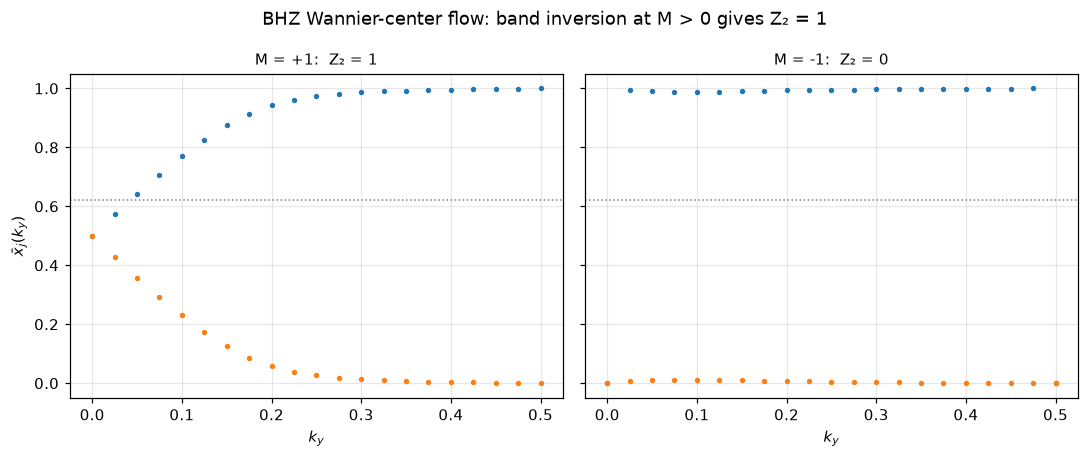

[PASS] BHZ is topological for 0 < M/B < 8 and trivial for M < 0


True

In [50]:
# Z2 via Wannier-center flow, for both signs of M
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
z2_bhz = {}
for ax, Mv in zip(axs, (M_topo, M_triv)):
    m = bhz(Mv)
    mesh = Mesh(["k", "k"])
    mesh.build_grid((51, 41), k_endpoints=[True, True])
    wfa = WFArray(m.lattice, mesh, spinful=True)
    wfa.solve_model(m)
    wcc = np.asarray(wfa.berry_phase(axis_idx=0, state_idx=[0, 1],
                                     berry_evals=True, contin=False)) / (2 * np.pi) % 1.0
    ky = mesh.get_axis_range(1, 1)
    half = ky <= 0.5 + 1e-9
    for j in range(wcc.shape[1]):
        ax.plot(ky[half], wcc[half, j], "o", ms=2.5)
    ref = 0.62
    z2_bhz[Mv], crossings = z2_from_wcc(wcc[half], ref)   # helper from §15
    ax.axhline(ref, color="gray", ls=":", lw=1)
    ax.set_title(f"M = {Mv:+.0f}:  Z₂ = {crossings % 2}", fontsize=10)
    ax.set_xlabel(r"$k_y$")
axs[0].set_ylabel(r"$\bar x_j(k_y)$")
fig.suptitle("BHZ Wannier-center flow: band inversion at M > 0 gives Z₂ = 1")
fig.tight_layout()
plt.show()
caption("The same Wannier-flow diagnostic applied to the BHZ model: partner "
        "switching (left, odd crossings of the reference line) for the inverted "
        "regime, none for the normal one. The Z₂ index sees the band inversion of "
        "the previous figure without ever looking at orbital character — invariants "
        "do not care how the topology was engineered.")

check("BHZ is topological for 0 < M/B < 8 and trivial for M < 0",
      z2_bhz[M_topo] == 1 and z2_bhz[M_triv] == 0)

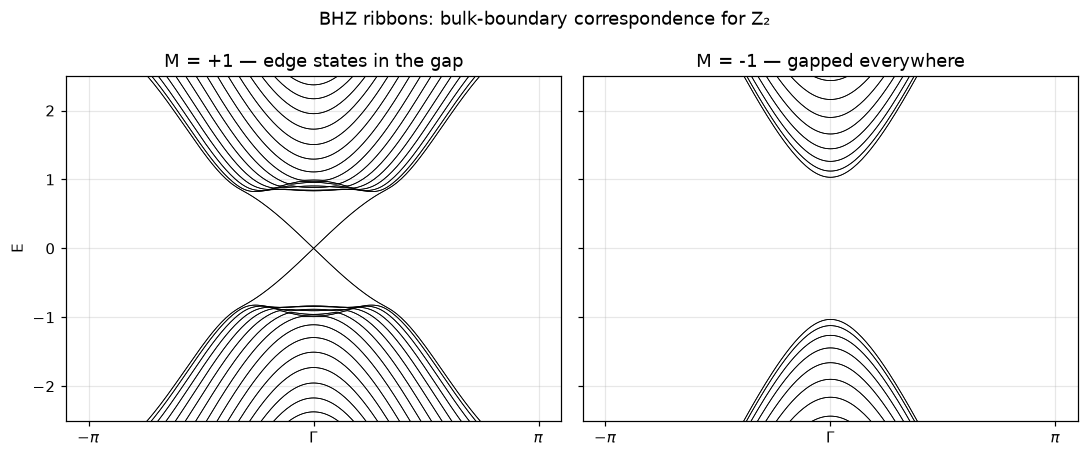

In [51]:
# the experimental signature: helical edge states appear only in the inverted regime
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, Mv in zip(axs, (M_topo, M_triv)):
    rib = bhz(Mv).cut_piece(20, 1, glue_edges=False)
    k_vec, k_dist, k_node = rib.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
    ev = rib.solve_ham(k_vec)
    ax.plot(k_dist, ev, "k-", lw=0.5)
    ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(f"M = {Mv:+.0f} — {'edge states in the gap' if Mv > 0 else 'gapped everywhere'}")
axs[0].set_ylabel("E")
fig.suptitle("BHZ ribbons: bulk-boundary correspondence for Z₂")
fig.tight_layout()
plt.show()
caption("BHZ ribbon spectra in the two phases. Only the inverted regime (left) "
        "carries states crossing the bulk gap — the helical edge channels whose "
        "quantized conductance 2e²/h was measured by the Würzburg group in 2007, "
        "the first experimental topological insulator. The trivial ribbon (right) "
        "is gapped through and through.")

## 17. The BBH quadrupole insulator — higher-order topology and nested Wilson loops

Benalcazar–Bernevig–Hughes (2017): a 2D insulator whose bulk dipole (polarization) vanishes but
whose bulk **quadrupole moment** $q_{xy} = e/2$ is quantized — producing gapless states not on
edges (the edges are gapped) but on **corners**: half-charges at $E=0$. The model: a square lattice
with four orbitals, intracell hoppings $\gamma$, intercell hoppings $\lambda$, and one negative
bond per plaquette so every square encloses $\pi$ flux. Topological when $|\gamma| < |\lambda|$.

The invariant needs a construction beyond a plain Wilson loop: the **nested Wilson loop**. First
Wilson loop along $k_x$ → the two *Wannier bands* $\nu^\pm_x(k_y)$ are gapped; then the Berry phase
*of a Wannier band* along $k_y$ → the Wannier-sector polarization $p_y^{\nu}$, quantized to jump by
$1/2$ between the trivial and quadrupole phases. PythTB has no
one-call nested Wilson, but it hands us everything needed — eigenvectors from `solve_ham`, or the
Wilson unitaries from `WFArray.wilson_loop` — so we build it by hand. This is the notebook's first
real *stretch*: the package as a linear-algebra toolkit rather than a menu.

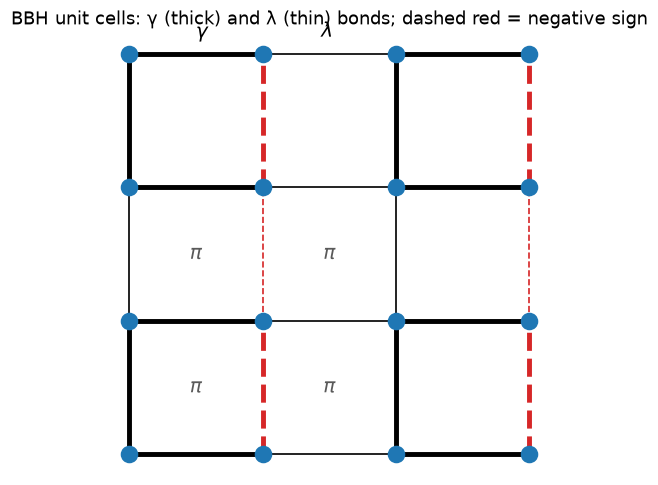

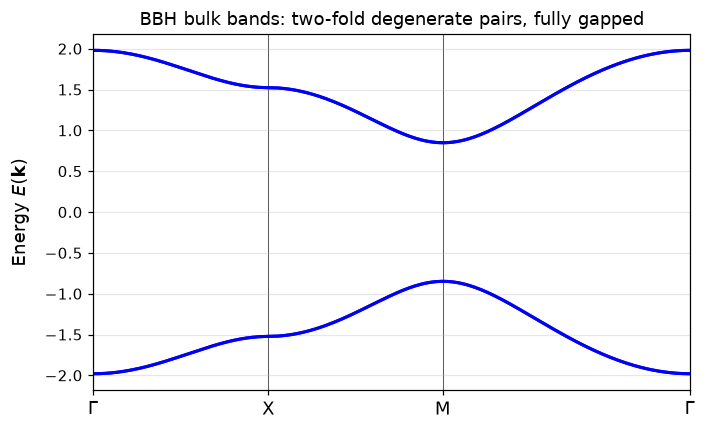

[PASS] BBH spectrum is chiral-symmetric (E and -E in pairs)


True

In [52]:
def bbh(gamma, lam):
    '''BBH quadrupole model: 4 orbitals on the square lattice, pi flux per plaquette.
    Vertical bonds in the x=1/2 column carry the minus sign.'''
    lat = Lattice(lat_vecs=[[1, 0], [0, 1]],
                  orb_vecs=[[0, 0], [0.5, 0], [0, 0.5], [0.5, 0.5]],
                  periodic_dirs=[0, 1])
    m = TBModel(lat)
    # intracell
    m.set_hop(gamma, 0, 1, [0, 0])          # x bond, row y=0
    m.set_hop(gamma, 2, 3, [0, 0])          # x bond, row y=1/2
    m.set_hop(gamma, 0, 2, [0, 0])          # y bond, column x=0
    m.set_hop(-gamma, 1, 3, [0, 0])         # y bond, column x=1/2  (negative)
    # intercell
    m.set_hop(lam, 1, 0, [1, 0])
    m.set_hop(lam, 3, 2, [1, 0])
    m.set_hop(lam, 2, 0, [0, 1])
    m.set_hop(-lam, 3, 1, [0, 1])           # negative column continues across cells
    return m

gamma, lam = 0.4, 1.0                        # |gamma| < |lambda|: quadrupole phase
qm = bbh(gamma, lam)

# the model drawn: 2x2 cells, intracell gamma (thick) vs intercell lambda (thin),
# negative bonds dashed red — check that EVERY square plaquette has exactly one
orbs = np.array([[0, 0], [0.5, 0], [0, 0.5], [0.5, 0.5]])
fig, ax = plt.subplots(figsize=(5.6, 5.2))
for cx in range(2):
    for cy in range(2):
        o = orbs + [cx, cy]
        bonds = [(0, 1, gamma, +1), (2, 3, gamma, +1), (0, 2, gamma, +1), (1, 3, gamma, -1)]
        for i, j, amp, sgn in bonds:
            ax.plot(o[[i, j], 0], o[[i, j], 1],
                    "--" if sgn < 0 else "-", color="C3" if sgn < 0 else "k",
                    lw=3.2, zorder=2)
        # intercell bonds to the right / top
        for (i, j, dx, dy, sgn) in [(1, 0, 1, 0, +1), (3, 2, 1, 0, +1),
                                    (2, 0, 0, 1, +1), (3, 1, 0, 1, -1)]:
            p1, p2 = o[i], orbs[j] + [cx + dx, cy + dy]
            if p2[0] < 1.8 and p2[1] < 1.8:
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                        "--" if sgn < 0 else "-", color="C3" if sgn < 0 else "k",
                        lw=1.1, zorder=2)
        ax.scatter(o[:, 0], o[:, 1], s=110, c="C0", zorder=3)
for (x, y) in [(0.25, 0.25), (0.75, 0.25), (0.25, 0.75), (0.75, 0.75)]:
    ax.annotate(r"$\pi$", (x, y), ha="center", va="center", fontsize=13, color="0.35")
ax.annotate(r"$\gamma$", (0.25, 1.56), fontsize=13)
ax.annotate(r"$\lambda$", (0.72, 1.56), fontsize=13)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("BBH unit cells: γ (thick) and λ (thin) bonds; dashed red = negative sign")
plt.show()
caption("The BBH quadrupole model: four orbitals per cell coupled by intracell γ "
        "(thick) and intercell λ (thin) bonds, with the vertical bonds of one "
        "column negated (dashed red). Multiply the bond signs around any elementary "
        "square: always −1, i.e. π flux per plaquette. The flux gaps the edge "
        "spectrum too — that is what demotes the topological states from edges to "
        "corners, one dimension down.")

fig, ax = qm.plot_bands([[0, 0], [0.5, 0], [0.5, 0.5], [0, 0]],
                        k_node_labels=[r"$\Gamma$", "X", "M", r"$\Gamma$"], nk=301)
ax.set_title("BBH bulk bands: two-fold degenerate pairs, fully gapped")
plt.show()
caption("BBH bulk bands: two doubly-degenerate pairs separated by a full gap. "
        "Nothing here betrays the topology — bulk dipole moments vanish by "
        "symmetry, and only the quadrupole moment, extracted by the nested Wilson "
        "loop below, distinguishes this insulator from a trivial one.")

ev = np.sort(qm.solve_ham(rng.random((50, 2))), axis=1)
check("BBH spectrum is chiral-symmetric (E and -E in pairs)",
      np.allclose(ev, -ev[:, ::-1], atol=1e-10))

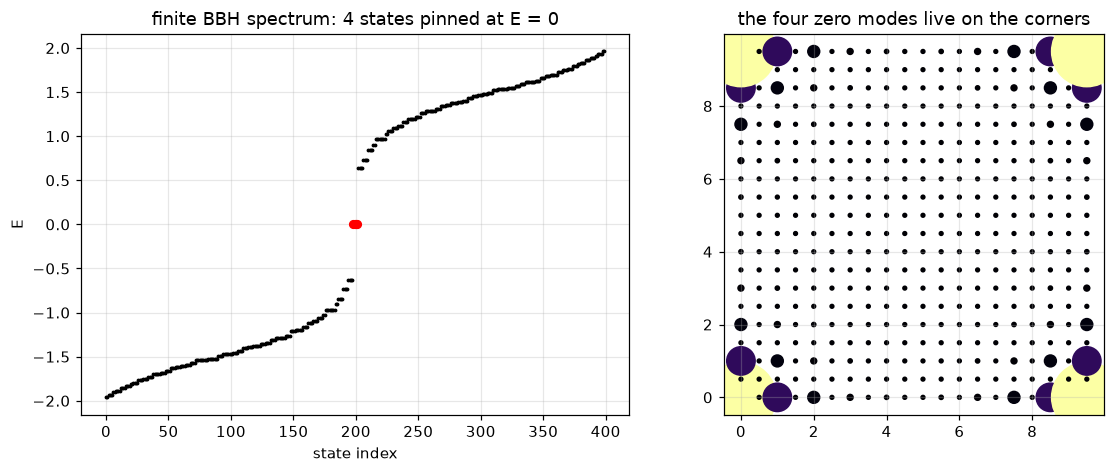

[PASS] four corner-pinned zero modes — found 4
[PASS] corner charge is quantized to e/2 — |Q_corner| = 0.5000


True

In [53]:
# corner states: finite sample in the topological phase
fin = bbh(gamma, lam).make_finite(periodic_dirs=[0, 1], num_cells=[10, 10])
evals, evecs = fin.solve_ham(return_eigvecs=True)
i_sort = np.argsort(np.abs(evals))
n_zero = int(np.sum(np.abs(evals) < 1e-3))

pos = fin.orb_vecs @ fin.lat_vecs
dens_corner = np.sum(np.abs(evecs[i_sort[:4]]) ** 2, axis=0)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
axs[0].plot(np.arange(len(evals)), np.sort(evals), "k.", ms=3)
axs[0].plot(np.arange(len(evals))[np.abs(np.sort(evals)) < 1e-3],
            np.sort(evals)[np.abs(np.sort(evals)) < 1e-3], "ro", ms=5)
axs[0].set_xlabel("state index"); axs[0].set_ylabel("E")
axs[0].set_title(f"finite BBH spectrum: {n_zero} states pinned at E = 0")

axs[1].scatter(pos[:, 0], pos[:, 1], s=6 + 3000 * dens_corner, c=dens_corner,
               cmap="inferno")
axs[1].set_aspect("equal")
axs[1].set_title("the four zero modes live on the corners")
fig.tight_layout()
plt.show()
caption("Higher-order bulk-boundary correspondence: the finite BBH sample has a "
        "gapped bulk AND gapped edges, yet four states sit pinned at E = 0 (red in "
        "the left panel), one exponentially localized on each corner (right). Each "
        "corner binds charge ±e/2 — the 2D analogue of the SSH end states, one "
        "dimension of boundary further down.")

check("four corner-pinned zero modes", n_zero == 4, f"found {n_zero}")

# corner charge: fill E<0 states, subtract the 2 electrons/cell background,
# and integrate the excess density over one corner quadrant
# fill strictly below the mid-gap corner modes: each corner then shows the
# HALF-charge deficit of its unoccupied corner state
occ = evals < -1e-3
rho = np.sum(np.abs(evecs[occ]) ** 2, axis=0)          # electrons per orbital
excess = rho - 0.5                                     # background: half filling
quad = (pos[:, 0] < pos[:, 0].mean()) & (pos[:, 1] < pos[:, 1].mean())
Q_corner = excess[quad].sum()
check("corner charge is quantized to e/2", np.isclose(abs(Q_corner), 0.5, atol=0.02),
      f"|Q_corner| = {abs(Q_corner):.4f}")

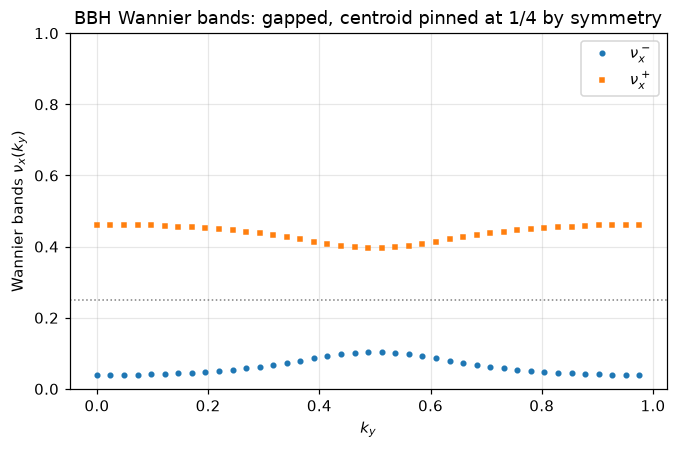

[PASS] Wannier bands remain gapped at every ky — min Wannier gap = 0.292
[PASS] Wannier-band centroid pinned at 1/4 (mod 1/2) — centroid spread: 1.94e-16


True

In [54]:
# nested Wilson loop, by hand.
# Step 1: occupied eigenvectors on an (Nx, Ny) grid (no duplicate endpoints).
Nx, Ny = 41, 41
kx = np.arange(Nx) / Nx
ky = np.arange(Ny) / Ny
KX, KY = np.meshgrid(kx, ky, indexing="ij")
k_flat = np.stack([KX.ravel(), KY.ravel()], axis=1)
evals_g, evecs_g = qm.solve_ham(k_flat, return_eigvecs=True)
u = evecs_g.reshape(Nx, Ny, 4, 4)[:, :, :2, :]         # occupied pair, (Nx,Ny,2,norb)

# convention-I boundary factor: u_n(k+G)_tau = e^{-2pi i G.tau} u_n(k)_tau
tau = qm.orb_vecs                                       # (4, 2) reduced positions
bx = np.exp(-2j * np.pi * tau[:, 0])                    # wrap along x
by = np.exp(-2j * np.pi * tau[:, 1])                    # wrap along y

def wilson_x(u, iy):
    '''Wilson loop along kx at fixed ky index: product of link overlaps.'''
    W = np.eye(2, dtype=complex)
    for ix in range(Nx):
        u1 = u[ix, iy]
        u2 = u[(ix + 1) % Nx, iy] * (bx if ix == Nx - 1 else 1.0)
        M = u1.conj() @ u2.T                            # (2,2) overlap
        # unitarize the link (SVD) — the standard discrete Wilson loop
        A, _, Bh = np.linalg.svd(M)
        W = W @ (A @ Bh)
    return W

# Wannier bands: eigenphases of W_x(ky)
nu_x = np.zeros((Ny, 2))
v_store = np.zeros((Ny, 2, 2), dtype=complex)           # Wilson eigenvectors
for iy in range(Ny):
    W = wilson_x(u, iy)
    lam_w, v = np.linalg.eig(W)
    order = np.argsort(np.angle(lam_w))
    nu_x[iy] = np.angle(lam_w)[order] / (2 * np.pi)
    v_store[iy] = v[:, order].T                         # rows = Wannier band vectors

fig, ax = plt.subplots()
ax.plot(ky, nu_x[:, 0] % 1.0, "o", ms=3, label=r"$\nu_x^-$")
ax.plot(ky, nu_x[:, 1] % 1.0, "s", ms=3, label=r"$\nu_x^+$")
ax.axhline(0.25, color="gray", ls=":", lw=1)
ax.set_xlabel(r"$k_y$"); ax.set_ylabel(r"Wannier bands $\nu_x(k_y)$")
ax.set_ylim(0, 1); ax.legend()
ax.set_title("BBH Wannier bands: gapped, centroid pinned at 1/4 by symmetry")
plt.show()
caption("First layer of the nested construction: the Wilson-loop eigenphases "
        "(Wannier bands) ν±(ky) of the occupied pair. They disperse but never touch, "
        "and mirror symmetry pins their centroid to exactly ¼. A gapped Wannier "
        "spectrum is itself a band structure one level up — with its own Berry "
        "phase, computed next.")

# the individual bands disperse; what is quantized is (a) the gap between them
# and (b) their centroid, pinned to 1/4 (mod 1/2) by the model's mirror symmetries
nu_wrap = nu_x % 1.0
circ_gap = np.minimum(np.abs(nu_wrap[:, 1] - nu_wrap[:, 0]),
                      1 - np.abs(nu_wrap[:, 1] - nu_wrap[:, 0]))
centroid = (nu_wrap.sum(axis=1) / 2) % 0.5
check("Wannier bands remain gapped at every ky", circ_gap.min() > 0.1,
      f"min Wannier gap = {circ_gap.min():.3f}")
check("Wannier-band centroid pinned at 1/4 (mod 1/2)",
      np.allclose(centroid, 0.25, atol=1e-3),
      f"centroid spread: {np.abs(centroid - 0.25).max():.2e}")

In [55]:
# Step 2: the nested loop. Build the Wannier-band basis |w_j(kx,ky)> by parallel-
# transporting the Wilson eigenvector with partial Wilson lines, then take its
# Berry phase along ky.
def nested_polarization(u, band=0):
    phases = []
    for base_ix in range(0, Nx, 8):                     # a few base points: p_y is kx-independent
        # Wannier-band states at every ky for this base kx column
        w = np.zeros((Ny, 4), dtype=complex)
        for iy in range(Ny):
            # Wilson loop starting (and ending) at base_ix; the BZ-boundary wrap
            # factor applies on the link ix = Nx-1 -> 0 wherever it occurs
            W = np.eye(2, dtype=complex)
            for step in range(Nx):
                ix = (base_ix + step) % Nx
                nxt = (ix + 1) % Nx
                u1 = u[ix, iy]
                u2 = u[nxt, iy] * (bx if ix == Nx - 1 else 1.0)
                M = u1.conj() @ u2.T
                A, _, Bh = np.linalg.svd(M)
                W = W @ (A @ Bh)
            lam_w, v = np.linalg.eig(W)
            order = np.argsort(np.angle(lam_w))
            vj = v[:, order][:, band]
            w[iy] = vj @ u[base_ix, iy]                 # embed in orbital space
        # Berry phase of w along ky (with y-wrap on the last link)
        prod = 1.0 + 0j
        for iy in range(Ny):
            w1 = w[iy]
            w2 = w[(iy + 1) % Ny] * (by if iy == Ny - 1 else 1.0)
            ov = np.vdot(w1, w2)
            prod *= ov / abs(ov)
        phases.append((-np.angle(prod) / (2 * np.pi)) % 1.0)
    return np.array(phases)

p_y = nested_polarization(u, band=0)
print("topological p_y^(nu) at several base kx:", np.round(p_y, 4))

# the same construction on the TRIVIAL model (gamma and lambda exchanged):
# the absolute value carries a geometric offset from the orbital positions
# (tau_y in {0, 1/2}), so the quantized invariant is the DIFFERENCE mod 1.
qm_triv = bbh(1.0, 0.4)
_, evecs_t = qm_triv.solve_ham(k_flat, return_eigvecs=True)
u_triv = evecs_t.reshape(Nx, Ny, 4, 4)[:, :, :2, :]
p_y_triv = nested_polarization(u_triv, band=0)
print("trivial     p_y^(nu) at several base kx:", np.round(p_y_triv, 4))

dp = (p_y.mean() - p_y_triv.mean()) % 1.0
check("nested Wilson polarizations are kx-independent (both phases)",
      p_y.std() < 1e-3 and p_y_triv.std() < 1e-3)
check("Wannier-sector polarization jumps by exactly 1/2 across the transition",
      np.isclose(dp, 0.5, atol=0.02),
      f"p_y(topo) - p_y(trivial) = {dp:.4f} mod 1")

topological p_y^(nu) at several base kx: [0.75 0.75 0.75 0.75 0.75 0.75]


trivial     p_y^(nu) at several base kx: [0.25 0.25 0.25 0.25 0.25 0.25]
[PASS] nested Wilson polarizations are kx-independent (both phases)
[PASS] Wannier-sector polarization jumps by exactly 1/2 across the transition — p_y(topo) - p_y(trivial) = 0.5000 mod 1


True

## 18. The Kitaev chain — superconductivity smuggled in as extra orbitals

PythTB has no notion of superconductivity: no Nambu space, no particle-hole symmetry class, no
anomalous terms. Kwant doesn't either, strictly — but Kwant's arbitrary-matrix onsites make BdG
natural, and its S-matrix machinery then computes Andreev physics. Here we *smuggle* the
Bogoliubov–de Gennes Hamiltonian into PythTB by declaring particle and hole components to be two
"orbitals":
$$
H_{BdG}(k) = \bigl[-2t\cos K - \mu\bigr]\tau_z + 2\Delta \sin K\,\tau_y ,
$$
the mean-field Kitaev chain. The recipe: orbital 0 gets the electron Hamiltonian, orbital 1 gets
$-H^*$, and the pairing $\Delta(c^\dagger_i c^\dagger_{i+1} + h.c.)$ becomes an orbital-off-diagonal
"hopping" antisymmetric under $i \leftrightarrow j$. For $|\mu| < 2t$ the chain is topological and
an open chain binds one **Majorana zero mode per end**.

What PythTB does *not* do for us here is exactly what makes this a stretch: it cannot verify
particle-hole symmetry (we check it by hand), it doesn't know the spectrum is redundant (every
state appears at $\pm E$), and its Berry-phase tools compute the invariant only if *we* know which
symmetry class to interpret it in. No guardrails — compare Kwant's `conservation_law` /
`particle_hole` machinery (Part IV, §28).

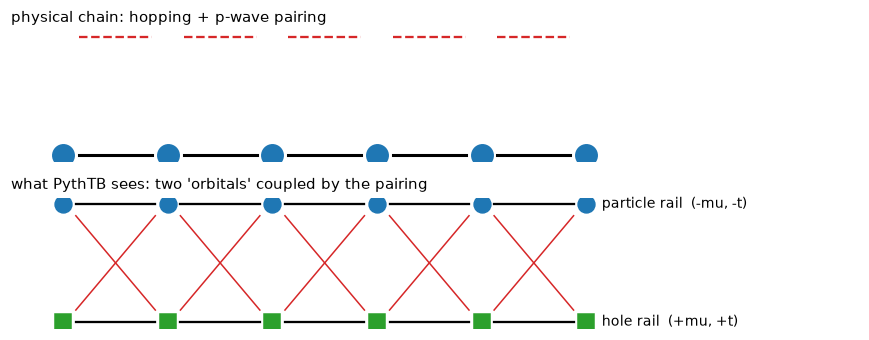

In [56]:
# the physical chain and its BdG shadow, drawn: one row of spinless sites with
# hopping t and p-wave pairing Delta on the same bonds; below it, the DOUBLED
# ladder PythTB actually diagonalizes (particle rail + hole rail)
fig, axs = plt.subplots(2, 1, figsize=(8, 3.2))
xs = np.arange(6)
axs[0].plot(xs, 0 * xs, "o", ms=14, color="C0", zorder=3)
for x in xs[:-1]:
    axs[0].plot([x + 0.15, x + 0.85], [0, 0], "-", color="k", lw=2)
    axs[0].plot([x + 0.15, x + 0.85], [0.16, 0.16], "--", color="C3", lw=1.5)
axs[0].annotate("t", (2.5, -0.22), ha="center", fontsize=12)
axs[0].annotate(r"$\Delta\, c_i c_{i+1}$", (2.5, 0.30), ha="center", fontsize=11, color="C3")
axs[0].set_title("physical chain: hopping + p-wave pairing", fontsize=10, loc="left")
axs[1].plot(xs, 0 * xs + 0.3, "o", ms=11, color="C0", zorder=3)
axs[1].plot(xs, 0 * xs - 0.3, "s", ms=11, color="C2", zorder=3)
for x in xs[:-1]:
    axs[1].plot([x + 0.12, x + 0.88], [0.3, 0.3], "-", color="k", lw=1.5)
    axs[1].plot([x + 0.12, x + 0.88], [-0.3, -0.3], "-", color="k", lw=1.5)
    axs[1].plot([x + 0.12, x + 0.88], [0.24, -0.24], "-", color="C3", lw=1)
    axs[1].plot([x + 0.12, x + 0.88], [-0.24, 0.24], "-", color="C3", lw=1)
axs[1].annotate("particle rail  (-mu, -t)", (5.15, 0.3), fontsize=9, va="center")
axs[1].annotate("hole rail  (+mu, +t)", (5.15, -0.3), fontsize=9, va="center")
axs[1].set_title("what PythTB sees: two 'orbitals' coupled by the pairing", fontsize=10, loc="left")
for ax in axs:
    ax.set_xlim(-0.5, 7.6); ax.axis("off")
fig.tight_layout()
plt.show()
caption("Top: the physical Kitaev chain — spinless fermions with hopping t and "
        "p-wave pairing Δ that creates/destroys PAIRS on neighbouring sites. "
        "Bottom: the Bogoliubov–de Gennes doubling PythTB actually diagonalizes — "
        "a particle rail and a hole rail (with negated parameters), the anomalous "
        "pairing recast as an ordinary inter-rail 'hopping' (red). The doubling is "
        "exact but redundant: every physical excitation appears twice, at ±E.")

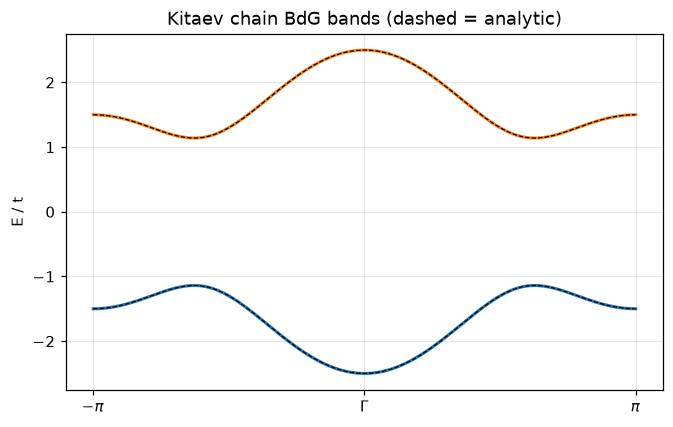

[PASS] BdG spectrum matches analytic Kitaev dispersion
[PASS] particle-hole symmetry E(k) = -E(-k) holds


True

In [57]:
def kitaev(mu, t=1.0, Delta=0.6):
    '''BdG Kitaev chain: orbital 0 = particle, orbital 1 = hole (both at tau=0).'''
    lat = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.0]], periodic_dirs=[0])
    m = TBModel(lat)
    m.set_onsite([-mu, +mu])
    m.set_hop(-t, 0, 0, [1])                 # electron hops
    m.set_hop(+t, 1, 1, [1])                 # hole partner: -(-t)* = +t
    # pairing 2*Delta*sin(K) tau_y:  H_01(k) = -2i*Delta*sin(K)
    m.set_hop(-Delta, 0, 1, [1])
    m.set_hop(+Delta, 0, 1, [-1], allow_conjugate_pair=True)
    return m

# bulk check against the analytic BdG dispersion
mu = 0.5
kit = kitaev(mu)
k_vec, k_dist, k_node = kit.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
ev = kit.solve_ham(k_vec)
K = 2 * np.pi * k_vec[:, 0]
E_bdg = np.sqrt((2 * 1.0 * np.cos(K) + mu) ** 2 + (2 * 0.6 * np.sin(K)) ** 2)

fig, ax = plt.subplots()
ax.plot(k_dist, ev, lw=2)
ax.plot(k_dist, E_bdg, "k--", lw=0.8); ax.plot(k_dist, -E_bdg, "k--", lw=0.8)
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.set_ylabel("E / t"); ax.set_title("Kitaev chain BdG bands (dashed = analytic)")
plt.show()
caption("BdG bands of the Kitaev chain (solid) on top of the analytic dispersion "
        "±√(ξ² + Δ²ₖ) (dashed). The pairing gaps the would-be Fermi points of the "
        "normal chain; the gap at k = ±π/2 is purely superconducting (∝ Δ), while "
        "the gap at k = 0 and π is set by |μ ∓ 2t| — and it is the latter that "
        "closes and reopens at the topological transition μ = 2t.")

check("BdG spectrum matches analytic Kitaev dispersion",
      np.allclose(np.sort(ev, axis=1), np.sort(np.stack([-E_bdg, E_bdg], 1), axis=1),
                  atol=1e-10))
# particle-hole symmetry check — BY HAND, because PythTB cannot do it for us
check("particle-hole symmetry E(k) = -E(-k) holds",
      np.allclose(np.sort(ev, axis=1), -np.sort(ev[::-1], axis=1)[:, ::-1], atol=1e-10))

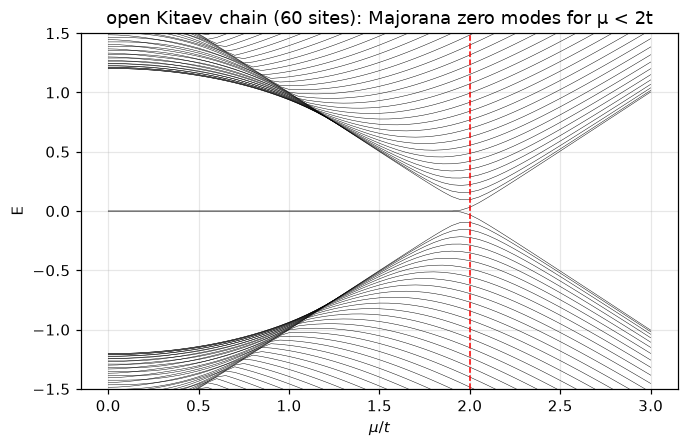

[PASS] zero mode in the topological phase, none in the trivial phase — E0(mu=0.5) = 1.1e-15, E0(mu=2.8) = 0.805


True

In [58]:
# open chain: Majorana end modes appear exactly in |mu| < 2t
N = 60
mu_scan = np.linspace(0.0, 3.0, 61)
spec = np.array([kitaev(m_).cut_piece(N, 0).solve_ham() for m_ in mu_scan])

fig, ax = plt.subplots()
ax.plot(mu_scan, spec, "k-", lw=0.3)
ax.axvline(2.0, color="r", ls="--", lw=1)
ax.set_xlabel(r"$\mu / t$"); ax.set_ylabel("E")
ax.set_ylim(-1.5, 1.5)
ax.set_title(f"open Kitaev chain ({N} sites): Majorana zero modes for μ < 2t")
plt.show()
caption("Open-chain BdG spectrum versus chemical potential: throughout the "
        "topological phase |μ| < 2t a pair of states clings to E = 0, splitting "
        "only exponentially in system size; past the bulk transition they merge "
        "into the continuum. This zero-bias pinning is exactly the feature hunted "
        "in tunneling experiments on proximitized nanowires — with the caveat that "
        "a tunneling CONDUCTANCE calculation is Kwant's territory, not PythTB's.")

E0_topo = np.abs(spec[np.argmin(np.abs(mu_scan - 0.5))]).min()
E0_triv = np.abs(spec[np.argmin(np.abs(mu_scan - 2.8))]).min()
check("zero mode in the topological phase, none in the trivial phase",
      E0_topo < 1e-8 and E0_triv > 0.05,
      f"E0(mu=0.5) = {E0_topo:.1e}, E0(mu=2.8) = {E0_triv:.3f}")

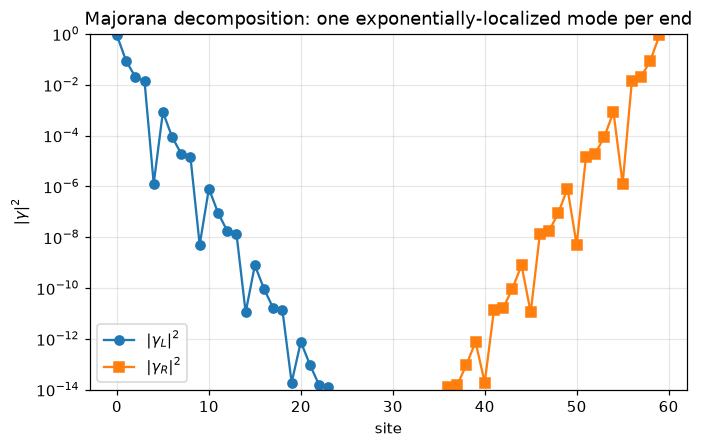

[PASS] Majorana combinations localize on opposite ends
[PASS] Majorana has equal particle and hole weight — u-weight 0.500000 vs v-weight 0.500000


True

In [59]:
# the Majorana structure: the two E~0 eigenstates combine into Majoranas
# gamma_L/R = (psi_0 ± psi_1)/sqrt(2), each localized at ONE end with |u| = |v|
fin = kitaev(0.5).cut_piece(N, 0)
evals, evecs = fin.solve_ham(return_eigvecs=True)
i2 = np.argsort(np.abs(evals))[:2]
psi_p, psi_m = evecs[i2[0]], evecs[i2[1]]

# numpy returns the +-E pair with arbitrary phases, so "psi_p ± psi_m" is not
# gauge-safe. Instead diagonalize the left-half weight inside the 2D zero-energy
# subspace: its eigenvectors are the maximally end-localized combinations.
half_L = fin.orb_vecs[:, 0] < N / 2
V = np.stack([psi_p, psi_m], axis=0)                  # (2, n_orb) subspace basis
O_L = (V * half_L) @ V.conj().T                       # 2x2 left-weight operator
wts, cvec = np.linalg.eigh(O_L)
gam_2 = cvec[:, 0] @ V                                # least left weight  -> right end
gam_1 = cvec[:, 1] @ V                                # most  left weight -> left end

x_site = fin.orb_vecs[::2, 0]                     # one position per site
d1 = (np.abs(gam_1) ** 2).reshape(N, 2).sum(1)
d2 = (np.abs(gam_2) ** 2).reshape(N, 2).sum(1)

fig, ax = plt.subplots()
ax.semilogy(x_site, d1, "o-", label=r"$|\gamma_L|^2$")
ax.semilogy(x_site, d2, "s-", label=r"$|\gamma_R|^2$")
ax.set_xlabel("site"); ax.set_ylabel(r"$|\gamma|^2$")
ax.set_ylim(1e-14, 1)
ax.legend(); ax.set_title("Majorana decomposition: one exponentially-localized mode per end")
plt.show()
caption("The two E ≈ 0 BdG eigenstates recombined into maximally end-localized "
        "combinations: each is a MAJORANA mode — equal particle and hole content, "
        "exponentially confined to one end. A single fermionic level (occupied or "
        "empty) is physically split across the two chain ends; no local probe can "
        "measure its occupation, which is the storage principle of topological "
        "qubits.")

check("Majorana combinations localize on opposite ends",
      d1[:N//2].sum() > 0.99 * d1.sum() and d2[N//2:].sum() > 0.99 * d2.sum())

# electron-hole weight balance: a Majorana has |u| = |v| exactly
uu = np.abs(gam_1.reshape(N, 2)[:, 0]) ** 2
vv = np.abs(gam_1.reshape(N, 2)[:, 1]) ** 2
check("Majorana has equal particle and hole weight", np.isclose(uu.sum(), vv.sum(), atol=1e-3),
      f"u-weight {uu.sum():.6f} vs v-weight {vv.sum():.6f}")

## 19. Weyl semimetals — monopoles, sliced Chern numbers, and Fermi arcs

A **Weyl node** is a point where two bands touch with the local form
$H \approx \sum_{ij} v_{ij} \delta k_i \sigma_j$: a monopole of Berry curvature with quantized
charge (chirality) $\chi = \pm1$. Nodes come in pairs (Nielsen–Ninomiya), and between a pair the
system is effectively a stack of 2D Chern insulators: the **Chern number of the 2D slice at fixed
$k_z$ jumps by $\chi$ when the slice crosses a node**. Bulk-boundary correspondence then forces
surface states — **Fermi arcs** — connecting the projections of the nodes.

Minimal model (single site, cubic lattice, spinful so the two bands are a $2\times2$ spin space):
$$
H(\mathbf K) = \sin K_x\,\sigma_x + \sin K_y\,\sigma_y +
\bigl[\cos K_z - \cos K_0 + 2 - \cos K_x - \cos K_y \bigr]\sigma_z,
$$
with Weyl nodes at $\mathbf K = (0, 0, \pm K_0)$. Every term is a one-line `set_hop` with a
$2\times2$ matrix. For the sliced Chern numbers we use a genuinely PythTB-2.0 move: build a *2D*
model whose hoppings are **functions of a parameter** `kz` — the third momentum demoted to a knob —
and sweep `chern_number` over it.

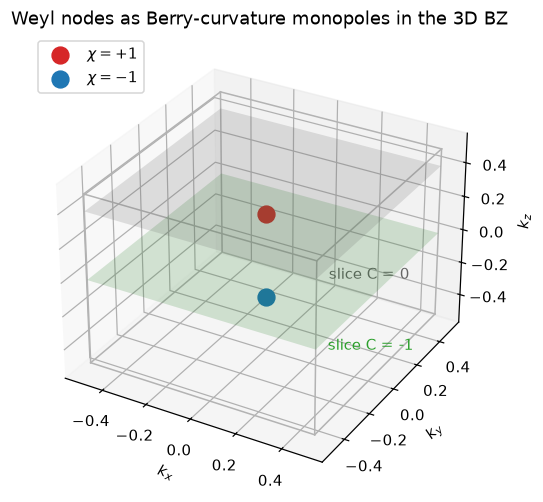

In [60]:
# the geography of a Weyl semimetal: 3D BZ, two nodes on the kz axis, and the
# 2D slices whose Chern numbers we are about to compute
fig = plt.figure(figsize=(6.2, 5.4))
ax = fig.add_subplot(projection="3d")
r = [-0.5, 0.5]
for zdir in (0, 1, 2):                                  # BZ cube edges
    for a in r:
        for b in r:
            seg = np.array([[a, b, -0.5], [a, b, 0.5]])
            seg = np.roll(seg, zdir, axis=1)
            ax.plot(*seg.T, color="0.7", lw=1)
ax.scatter([0], [0], [0.25], s=120, c="C3", marker="o", label=r"$\chi=+1$")
ax.scatter([0], [0], [-0.25], s=120, c="C0", marker="o", label=r"$\chi=-1$")
for kz_s, col in ((0.0, "C2"), (0.4, "0.5")):           # two example slices
    xx, yy = np.meshgrid(r, r)
    ax.plot_surface(xx, yy, np.full_like(xx, kz_s), alpha=0.18, color=col)
ax.text(0.55, -0.5, 0.02, "slice C = -1", color="C2")
ax.text(0.55, -0.5, 0.42, "slice C = 0", color="0.4")
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_y$"); ax.set_zlabel(r"$k_z$")
ax.legend(loc="upper left")
ax.set_title("Weyl nodes as Berry-curvature monopoles in the 3D BZ")
plt.show()
caption("The playing field: the 3D Brillouin zone with the two Weyl nodes on the "
        "kz axis — a monopole (red) and an antimonopole (blue) of Berry curvature. "
        "Every fixed-kz plane is a 2D system with a well-defined Chern number, "
        "which changes by the enclosed chirality when the plane sweeps past a node: "
        "C = −1 between the nodes (green slice), 0 outside (gray slice).")

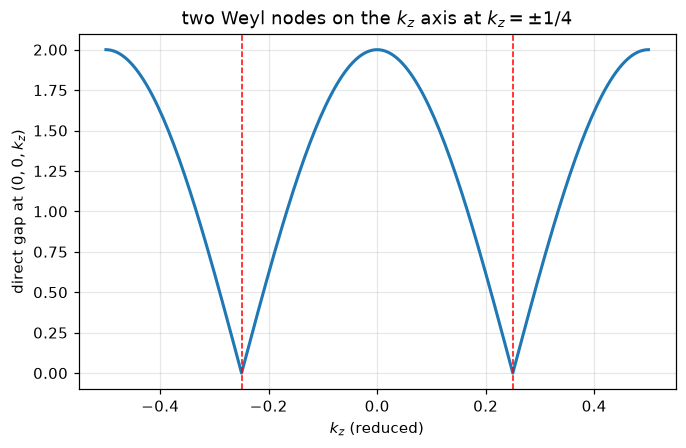

[PASS] nodes are exact band touchings — |E| at nodes = 0.0e+00
[PASS] spectrum is gapped away from the nodes (generic k sample) — min |E| over random k = 0.6526


True

In [61]:
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]])
sz_m = np.diag([1.0, -1.0]).astype(complex)
K0 = np.pi / 2

def weyl_3d():
    lat = Lattice(lat_vecs=np.eye(3), orb_vecs=[[0, 0, 0]], periodic_dirs=[0, 1, 2])
    m = TBModel(lat, spinful=True)
    m.set_onsite([[0, 0, 0, 2 + np.cos(K0)]])
    m.set_hop(-0.5j * sx - 0.5 * sz_m, 0, 0, [1, 0, 0])
    m.set_hop(-0.5j * sy - 0.5 * sz_m, 0, 0, [0, 1, 0])
    m.set_hop(-0.5 * sz_m, 0, 0, [0, 0, 1])
    return m

weyl = weyl_3d()

# the nodes: gap must close exactly at (0,0,±K0) and nowhere else on the kz axis
kz_line = np.linspace(-0.5, 0.5, 201)
k_line = np.stack([np.zeros_like(kz_line), np.zeros_like(kz_line), kz_line], axis=1)
gap_line = np.diff(weyl.solve_ham(k_line), axis=1).ravel()

fig, ax = plt.subplots()
ax.plot(kz_line, gap_line, lw=2)
for kn in (K0 / (2 * np.pi), -K0 / (2 * np.pi)):
    ax.axvline(kn, color="r", ls="--", lw=1)
ax.set_xlabel(r"$k_z$ (reduced)"); ax.set_ylabel("direct gap at $(0,0,k_z)$")
ax.set_title("two Weyl nodes on the $k_z$ axis at $k_z = \\pm 1/4$")
plt.show()
caption("The direct gap along the kz axis: it collapses linearly to zero at "
        "kz = ±¼ and nowhere else — point touchings with conical dispersion in all "
        "three directions. Linear closure in 3D is generic (no fine-tuning): a Weyl "
        "node can only be removed by merging it with a partner of opposite "
        "chirality, which is why the phase is robust without any protecting "
        "symmetry beyond translation.")

gap_at_nodes = np.abs(weyl.solve_ham(np.array([[0, 0, 0.25], [0, 0, -0.25]]))).max()
check("nodes are exact band touchings", gap_at_nodes < 1e-10,
      f"|E| at nodes = {gap_at_nodes:.1e}")
gap_away = np.abs(weyl.solve_ham(rng.random((200, 3)) * 0.9 + 0.05)).min(axis=1).min()
check("spectrum is gapped away from the nodes (generic k sample)", gap_away > 1e-3,
      f"min |E| over random k = {gap_away:.4f}")

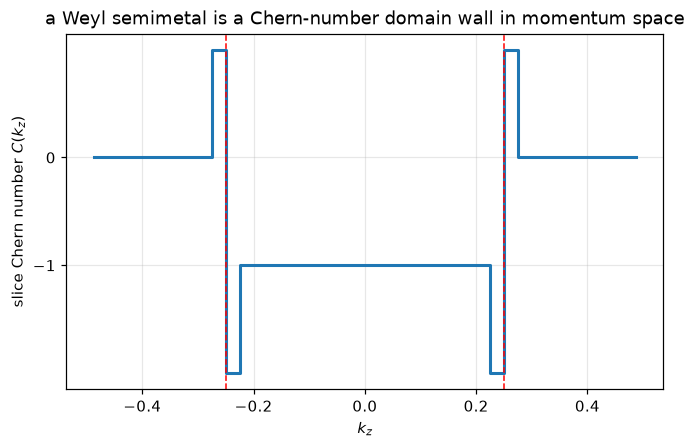

[PASS] C jumps by the chirality χ = ±1 at each node — C between nodes = -1, outside = 0


True

In [62]:
# sliced Chern number C(kz): a 2D model with kz as a symbolic parameter
def weyl_slice():
    lat = Lattice(lat_vecs=np.eye(2), orb_vecs=[[0, 0]], periodic_dirs=[0, 1])
    m = TBModel(lat, spinful=True)
    m.set_onsite(lambda kz: [0, 0, 0, 2 + np.cos(K0) - np.cos(2 * np.pi * kz)],
                 ind_i=0)
    m.set_hop(-0.5j * sx - 0.5 * sz_m, 0, 0, [1, 0])
    m.set_hop(-0.5j * sy - 0.5 * sz_m, 0, 0, [0, 1])
    return m

sl = weyl_slice()
# half-step-offset grid: the slice AT a node is gapless and has no Chern number
kz_scan = (np.arange(40) + 0.5) / 40 - 0.5
C_kz = np.array([float(sl.chern_number(plane=(0, 1), nks=(21, 21), occ_idxs=[0], kz=kz))
                 for kz in kz_scan])

fig, ax = plt.subplots()
ax.step(kz_scan, np.round(C_kz), where="mid", lw=2)
for kn in (0.25, -0.25):
    ax.axvline(kn, color="r", ls="--", lw=1)
ax.set_xlabel(r"$k_z$"); ax.set_ylabel(r"slice Chern number $C(k_z)$")
ax.set_yticks([-1, 0])
ax.set_title("a Weyl semimetal is a Chern-number domain wall in momentum space")
plt.show()
caption("The sliced Chern number C(kz), each point computed from a 2D model in "
        "which kz enters as a symbolic parameter: quantized plateaus with unit "
        "jumps exactly at the node positions. The jump measures the chirality of "
        "the node the slice crossed — Weyl nodes are literally the points where "
        "Chern numbers are created and destroyed.")

C_in = np.round(C_kz[np.abs(kz_scan) < 0.2])
C_out = np.round(C_kz[np.abs(kz_scan) > 0.3])
check("C jumps by the chirality χ = ±1 at each node",
      np.all(C_in == C_in[0]) and np.all(C_out == 0) and abs(C_in[0]) == 1,
      f"C between nodes = {C_in[0]:+.0f}, outside = 0")

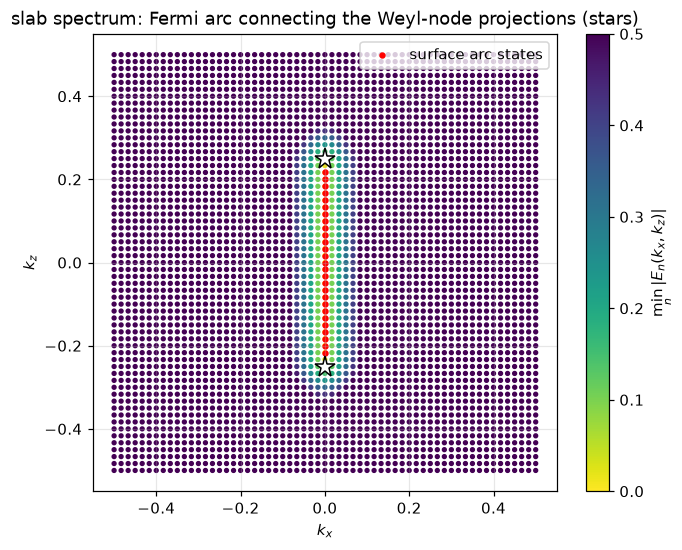

[PASS] Fermi arc spans the region between the node projections — 27 arc points, kz range [-0.22, 0.22]


True

In [63]:
# Fermi arcs: slab finite along y, momentum space (kx, kz)
NSLAB = 24
slab = weyl_3d().cut_piece(NSLAB, 1, glue_edges=False)   # periodic dirs: x and z

nkx, nkz = 61, 61
kxs = np.linspace(-0.5, 0.5, nkx)
kzs = np.linspace(-0.5, 0.5, nkz)
KXg, KZg = np.meshgrid(kxs, kzs, indexing="ij")
k_flat = np.stack([KXg.ravel(), KZg.ravel()], axis=1)

ev, vec = slab.solve_ham(k_flat, return_eigvecs=True)
i_min = np.argmin(np.abs(ev), axis=1)                    # state closest to E=0
E_min = np.take_along_axis(ev, i_min[:, None], 1).ravel()

# surface weight of that state: probability in the outermost 3 cells
y_pos = np.repeat(slab.orb_vecs[:, 1], 2)                # spinful doubling
surf_mask = (y_pos < 3) | (y_pos > NSLAB - 1 - 3 + 1)
psi_min = np.take_along_axis(vec, i_min[:, None, None], 1)[:, 0, :]
w_surf = (np.abs(psi_min) ** 2 * surf_mask).sum(axis=1)

arc = (np.abs(E_min) < 0.05) & (w_surf > 0.6)

fig, ax = plt.subplots(figsize=(6.8, 5.4))
sc = ax.scatter(KXg.ravel(), KZg.ravel(), c=np.abs(E_min).clip(0, 0.5), s=6,
                cmap="viridis_r")
ax.scatter(KXg.ravel()[arc], KZg.ravel()[arc], s=10, c="r", label="surface arc states")
ax.plot([0, 0], [0.25, -0.25], "w*", ms=14, mec="k")
fig.colorbar(sc, label=r"$\min_n |E_n(k_x,k_z)|$")
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_z$")
ax.legend(loc="upper right")
ax.set_title("slab spectrum: Fermi arc connecting the Weyl-node projections (stars)")
plt.show()
caption("Surface physics of the slab: the minimum |E(kx, kz)| over the slab bands "
        "(background) with surface-localized zero-energy states marked in red. "
        "They trace an open ARC connecting the projections of the two nodes — "
        "impossible for any isolated 2D metal, whose Fermi lines must close. The "
        "arc is the collection of chiral edge modes of all the C = −1 slices "
        "between the nodes, seen end-on; its partner lives on the opposite surface.")

# the arc exists between the nodes and not outside
kz_arc = KZg.ravel()[arc]
check("Fermi arc spans the region between the node projections",
      len(kz_arc) > 0 and kz_arc.max() < 0.27 and kz_arc.min() > -0.27
      and (np.abs(kz_arc) < 0.2).sum() > 5,
      f"{arc.sum()} arc points, kz range [{kz_arc.min():.2f}, {kz_arc.max():.2f}]")

## 20. The Fu–Kane–Mele model and the axion angle $\theta$

The 3D generalization of the quantum spin Hall effect: Fu–Kane–Mele (2007) put spin–orbit-coupled
electrons on the **diamond lattice** and found the first 3D strong topological insulator. Its
magnetoelectric response is captured by the **axion angle**
$$
\theta = \frac{1}{4\pi}\int_{BZ} d^3k\; \epsilon^{ijk}\,
\mathrm{Tr}\Bigl[A_i \partial_j A_k - \tfrac{2i}{3} A_i A_j A_k\Bigr] ,
$$
the Chern–Simons invariant of the occupied bands. Time-reversal (or inversion) pins
$\theta \in \{0, \pi\}$: $\theta = \pi$ *is* the strong TI. Because $\theta$ is only defined modulo
$2\pi$, PythTB 2.0's `axion_angle` tracks it along an *adiabatic sweep*: we add a staggered Zeeman
field of strength $\sin\beta$ and a bond modulation $\cos\beta$ (following the PythTB axion
tutorial), so that $\beta: 0 \to 2\pi$ interpolates trivial → TI → trivial while breaking TRS in
between. Along the cycle $\theta$ advances by $2\pi C_2$, with $C_2$ the **second Chern number** of
the 4D $(\mathbf k, \beta)$ space — the same relation that makes the Thouless pump a Chern number
one dimension up. Θ-odd physics in its cleanest numerical form.

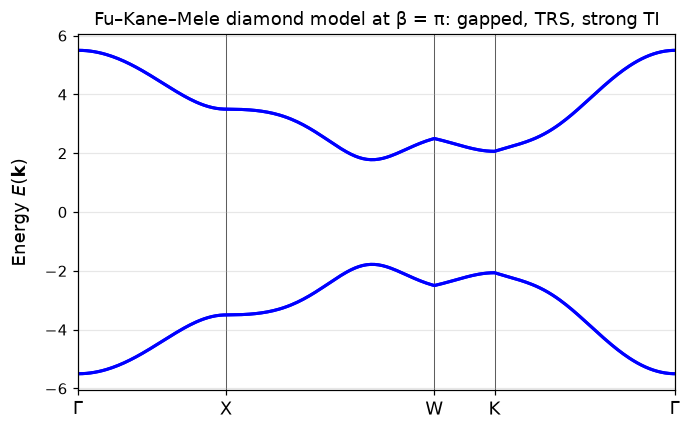

In [64]:
# FKM diamond model + staggered (111) Zeeman of strength m sin(beta), bond
# modulation m cos(beta)  (adapted from the PythTB 2.0 axion tutorial)
t_fkm, soc, m_ax = 1.0, 0.25, 0.5
lat_dia = Lattice([[0, 1, 1], [1, 0, 1], [1, 1, 0]],
                  [[0, 0, 0], [0.25, 0.25, 0.25]], periodic_dirs=...)
fkm = TBModel(lat_dia, spinful=True)
fkm.set_onsite(lambda beta: [0,  m_ax*np.sin(beta),  m_ax*np.sin(beta),  m_ax*np.sin(beta)], ind_i=0)
fkm.set_onsite(lambda beta: [0, -m_ax*np.sin(beta), -m_ax*np.sin(beta), -m_ax*np.sin(beta)], ind_i=1)
for lvec in ([-1, 0, 0], [0, -1, 0], [0, 0, -1]):
    fkm.set_hop(t_fkm, 0, 1, lvec)
fkm.set_hop(lambda beta: 3 * t_fkm + m_ax * np.cos(beta), 0, 1, [0, 0, 0], mode="set")
lvec_list = ([1, 0, 0], [0, 1, 0], [0, 0, 1], [-1, 1, 0], [0, -1, 1], [1, 0, -1])
dir_list = ([0, 1, -1], [-1, 0, 1], [1, -1, 0], [1, 1, 0], [0, 1, 1], [1, 0, 1])
for j in range(6):
    spin = np.array([0.0] + dir_list[j])
    fkm.set_hop(1j * soc * spin, 0, 0, lvec_list[j])
    fkm.set_hop(-1j * soc * spin, 1, 1, lvec_list[j])

# bulk bands at the TRS point beta = pi (this is the strong-TI configuration)
fkm_pi = fkm.with_parameters(beta=np.pi)
DIA_NODES = [[0, 0, 0], [0.5, 0, 0], [0.5, 0.25, 0.75], [0.375, 0.375, 0.75], [0, 0, 0]]
DIA_LABELS = [r"$\Gamma$", "X", "W", "K", r"$\Gamma$"]
fig, ax = fkm_pi.plot_bands(DIA_NODES, k_node_labels=DIA_LABELS, nk=301)
ax.set_title("Fu–Kane–Mele diamond model at β = π: gapped, TRS, strong TI")
plt.show()
caption("Bulk bands of the Fu–Kane–Mele model on the diamond lattice at the "
        "time-reversal-symmetric point of the sweep (β = π), where the (111) bond "
        "strengthened by the modulation makes the system a strong topological "
        "insulator. Every band is doubly degenerate (inversion × time reversal); "
        "the topology hides in the wavefunctions, not in this spectrum — it takes "
        "the axion angle to see it.")

axion sweep on a 24^3 x 25 grid: 10.6 s


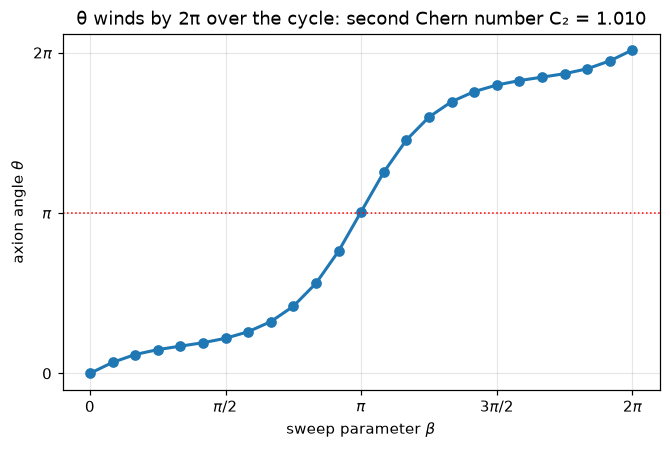

[PASS] second Chern number of the (k,β) cycle is 1 — C2 = 1.0095
[PASS] θ = π at the TRS point β = π (strong TI) — θ(π) = 3.1715
[PASS] θ = 0 at β = 0 (trivial reference)


True

In [65]:
# theta(beta) over the full cycle + second Chern number
n_beta = 25
betas = np.linspace(0, 2 * np.pi, n_beta, endpoint=True)
t0 = time.time()
b_out, theta, c2 = fkm.axion_angle(nks=(24, 24, 24), param_periods={"beta": 2 * np.pi},
                                   return_second_chern=True, diff_scheme="central",
                                   diff_order=6, beta=betas)
theta = np.asarray(theta)
print(f"axion sweep on a 24^3 x {n_beta} grid: {time.time()-t0:.1f} s")

fig, ax = plt.subplots()
ax.plot(betas, theta, "o-", lw=2)
ax.axhline(np.pi, color="r", ls=":", lw=1)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
              ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_yticks([0, np.pi, 2*np.pi], ["0", r"$\pi$", r"$2\pi$"])
ax.set_xlabel(r"sweep parameter $\beta$")
ax.set_ylabel(r"axion angle $\theta$")
ax.set_title(f"θ winds by 2π over the cycle: second Chern number C₂ = {c2:.3f}")
plt.show()
caption("The axion angle θ tracked along the adiabatic cycle β: it starts at 0 "
        "(trivial), passes exactly through π at the TRS point β = π — the "
        "quantized magnetoelectric response of a strong TI — and returns having "
        "wound by 2π. The total winding is the second Chern number C₂ = 1 of the "
        "4D (k, β) space: the same mathematics as the Thouless pump, two "
        "dimensions higher. θ-odd physics (surface half-integer Hall response, "
        "image magnetic monopoles) lives on the π plateau.")

check("second Chern number of the (k,β) cycle is 1", abs(c2 - 1) < 0.05,
      f"C2 = {c2:.4f}")
check("θ = π at the TRS point β = π (strong TI)",
      abs(theta[n_beta // 2] - np.pi) < 0.1,
      f"θ(π) = {theta[n_beta // 2]:.4f}")
check("θ = 0 at β = 0 (trivial reference)", abs(theta[0]) < 1e-6)

## Exercises for Part II

Worked solutions are in `PythTB_Exercises_Solutions.ipynb`.

**II.1 — Competing masses.** In the Haldane model both $\Delta$ (Semenoff mass) and
$t_2\sin\phi$ (Haldane mass) gap the Dirac points, but with different relative signs at $K$ and
$K'$. Compute the gaps at $K$ and $K'$ separately along a path in $(\Delta, \phi)$ crossing the
phase boundary and show that the transition happens through a gap closing at *one* Dirac point
only.

**II.2 — Kane–Mele phase map.** Automate the WCC-crossing count of §15 into a function
`z2(delta, soc)` and map the $\mathbb{Z}_2$ phase diagram over the $(\Delta, \lambda_{SO})$ plane.
Compare with the analytic boundary $\Delta = 3\sqrt3\,\lambda_{SO}$.

**II.3 — From QSH to QAH.** Add an exchange field $M_z s_z$ to the topological BHZ model. Show
that increasing $M_z$ drives it through a phase with Chern number $C = \pm1$ (a quantum anomalous
Hall phase) before reaching the trivial phase, computing $C$ with `chern_number` at each step.

**II.4 — Corner-charge pump.** Drive the BBH model around the cycle
$\gamma(\lambda) = 1 + 0.8\cos 2\pi\lambda$, $\delta_{onsite}(\lambda) = 0.8\sin 2\pi\lambda$
(add the onsite term with alternating signs on the four orbitals). Track the four corner-state
energies over the cycle and show they traverse the gap — the higher-order analogue of the
Rice–Mele pump.

**II.5 — Kitaev invariant.** For the Kitaev chain, compute the Berry phase of the lower BdG band
around the BZ for $\mu$ from 0 to 3t and show it jumps by $\pi$ at $\mu = 2t$. Explain carefully
*why* this works even though the "occupied band" of a BdG Hamiltonian is not a physical filling —
and what PythTB cannot tell you about the class-D invariant.

**II.6 — Annihilating Weyl nodes.** Add $b\,\sigma_z$ to the Weyl model of §19 and track the node
positions as $b$ varies. Find the critical couplings at which the nodes meet and annihilate — at
the BZ boundary for $b < 0$, at $\Gamma$ for $b > 0$ — and compute the slice Chern numbers beyond
each: the two annihilation channels leave *different* insulators behind. Which one, and why?

# Part III — Stretching PythTB

PythTB has no magnetic-field API, no disorder API, no quasicrystal API and no benchmark suite.
This part builds all four out of the primitives — and finds out where the package's pure-Python,
dense-only design starts to hurt.

## 21. The Hofstadter butterfly — magnetic fields by hand

A uniform magnetic field enters a tight-binding model only through **Peierls phases**
$t_{ij} \to t_{ij} e^{i\theta_{ij}}$ with $\sum_{\rm plaquette}\theta = 2\pi\phi$, $\phi$ the flux
per plaquette in quanta. At rational flux $\phi = p/q$ the Hamiltonian is periodic in a $q$-site
**magnetic supercell** (Landau gauge: $x$-dependent phases on $y$-bonds), and the single band of
the square lattice splits into $q$ magnetic subbands. Plotting the spectrum against $\phi$ gives
Hofstadter's 1976 butterfly — a Cantor-set spectrum that took 40 years to reach experiments (moiré
superlattices, 2013).

PythTB supplies no `set_magnetic_field`; the ~10 lines below are the manual construction the
package's design forces — and *permits*: because hoppings are arbitrary complex numbers, gauge
choices are entirely in our hands.

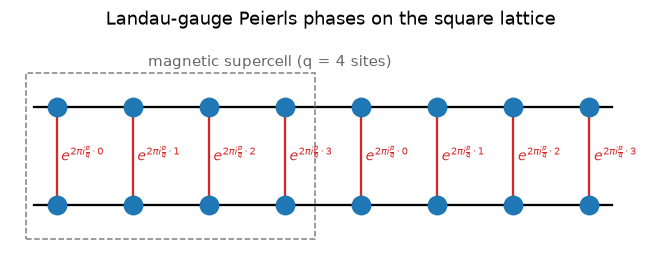

253,584 eigenvalues across 32 denominators in 2.2 s — all dense, all Python


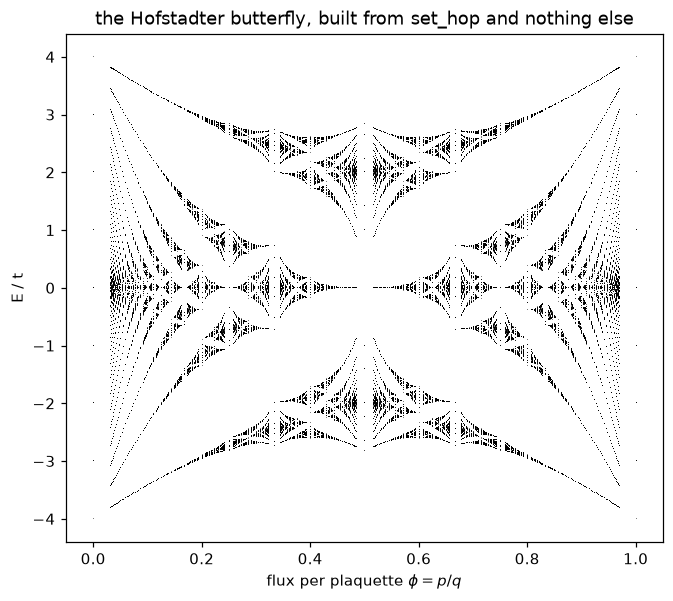

In [66]:
from math import gcd

def hofstadter_model(p, q, t=1.0):
    '''Square lattice at flux p/q per plaquette: q-site magnetic supercell along x,
    Landau gauge (phases on y-bonds, proportional to the x position).'''
    lat = Lattice(lat_vecs=[[q, 0], [0, 1]],
                  orb_vecs=[[i / q, 0] for i in range(q)], periodic_dirs=[0, 1])
    m = TBModel(lat)
    for i in range(q):
        m.set_hop(-t, i, (i + 1) % q, [1 if i == q - 1 else 0, 0])       # x bonds
        m.set_hop(-t * np.exp(2j * np.pi * p / q * i), i, i, [0, 1])     # y bonds
    return m

# the construction, drawn: a q-site magnetic supercell in Landau gauge — plain
# hops along x, x-dependent phases on the y bonds
q_demo = 4
fig, ax = plt.subplots(figsize=(7.5, 2.6))
for iy in range(2):
    for ix in range(2 * q_demo):
        ax.plot([ix], [iy], "o", ms=12, color="C0", zorder=3)
        if iy == 0:
            ax.plot([ix, ix], [0, 1], "-", color="C3", lw=1.5)
            ax.annotate(rf"$e^{{2\pi i \frac{{p}}{{q}} \cdot {ix % q_demo}}}$",
                        (ix + 0.06, 0.45), fontsize=9, color="C3")
    ax.plot([-0.3, 2 * q_demo - 0.7], [iy, iy], "-", color="k", lw=1.5, zorder=1)
ax.add_patch(plt.Rectangle((-0.4, -0.35), q_demo - 0.2, 1.7, fill=False, ls="--", ec="0.5"))
ax.annotate(f"magnetic supercell (q = {q_demo} sites)", (1.2, 1.42), fontsize=10, color="0.4")
ax.set_xlim(-0.6, 2 * q_demo - 0.2); ax.set_ylim(-0.5, 1.75)
ax.axis("off")
ax.set_title("Landau-gauge Peierls phases on the square lattice")
plt.show()
caption("How a uniform field enters a lattice model: hoppings along x stay real "
        "(black), hoppings along y acquire the Peierls phase exp(2πi·(p/q)·x) that "
        "grows with the column index (red labels). The pattern repeats after q "
        "columns — the magnetic supercell (dashed box) — which is why rational "
        "flux p/q restores Bloch's theorem with a q-site cell and q subbands.")
Q_MAX = 32
t0 = time.time()
phi_pts, E_pts = [], []
for q in range(1, Q_MAX + 1):
    for p in range(q + 1):
        if gcd(p, q) != 1 and not (p == 0 and q == 1):
            continue
        hm = hofstadter_model(p, q)
        ev = hm.solve_ham(hm.k_uniform_mesh([6, 6], include_endpoints=False))
        phi_pts.append(np.full(ev.size, p / q))
        E_pts.append(ev.ravel())
phi_all = np.concatenate(phi_pts)
E_all = np.concatenate(E_pts)
print(f"{len(phi_all):,} eigenvalues across {Q_MAX} denominators "
      f"in {time.time()-t0:.1f} s — all dense, all Python")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(phi_all, E_all, ",", color="k", alpha=0.5)
ax.set_xlabel(r"flux per plaquette $\phi = p/q$")
ax.set_ylabel("E / t")
ax.set_title("the Hofstadter butterfly, built from set_hop and nothing else")
ax.grid(False)
plt.show()
caption("The Hofstadter butterfly: every eigenvalue of the square lattice at "
        "every rational flux p/q with q ≤ 32. The spectrum is a Cantor set — the "
        "pattern inside any gap-bounded wing repeats the whole. Each gap carries a "
        "quantized Hall conductance (the Diophantine labels of exercise III.1), "
        "and the giant central gaps at simple fractions are the ones seen in moiré "
        "superlattice experiments.")

In [67]:
# two exact symmetries of the butterfly, as checks
ev_half = np.sort(hofstadter_model(1, 2).solve_ham(
    hofstadter_model(1, 2).k_uniform_mesh([20, 20])).ravel())
check("phi=1/2 spectrum is particle-hole symmetric",
      np.allclose(ev_half, -ev_half[::-1], atol=1e-10))

ev_a = np.sort(hofstadter_model(1, 5).solve_ham(
    hofstadter_model(1, 5).k_uniform_mesh([15, 15])).ravel())
ev_b = np.sort(hofstadter_model(4, 5).solve_ham(
    hofstadter_model(4, 5).k_uniform_mesh([15, 15])).ravel())
check("phi -> 1 - phi symmetry (time reversal of the field)",
      np.allclose(ev_a, ev_b, atol=1e-10),
      f"max dev = {np.abs(ev_a - ev_b).max():.1e}")

# and the q-subband structure: flux 1/3 must show exactly 3 magnetic subbands
ev3 = hofstadter_model(1, 3).solve_ham(hofstadter_model(1, 3).k_uniform_mesh([40, 40]))
gaps = [ev3[:, b + 1].min() - ev3[:, b].max() for b in range(2)]
check("phi=1/3: three subbands separated by open gaps",
      all(g > 0.1 for g in gaps), f"gaps = {[f'{g:.3f}' for g in gaps]}")

[PASS] phi=1/2 spectrum is particle-hole symmetric
[PASS] phi -> 1 - phi symmetry (time reversal of the field) — max dev = 2.7e-15
[PASS] phi=1/3: three subbands separated by open gaps — gaps = ['1.293', '1.268']


True

## 22. Disorder — Anderson localization, one eigenvector at a time

Disorder breaks Bloch's theorem, so every k-space tool in this notebook goes dark; what remains is
exact diagonalization of finite samples. PythTB handles this without complaint — a disordered
sample is just `set_onsite` with random values — but with **dense** diagonalization only, the
accessible sizes stop near $10^3$–$10^4$ orbitals (§24 quantifies the wall; Kwant's sparse solvers
and KPM push to $10^6$+).

Diagnostic: the **inverse participation ratio** $\mathrm{IPR} = \sum_i |\psi_i|^4$ — of order
$1/N$ for an extended state, of order $1/\xi^2$ (size-independent) for a state localized on $\xi^2$
sites. In 2D all states localize for any $W$, but at weak disorder $\xi$ vastly exceeds our sample
— finite-size physics we can *see* directly.

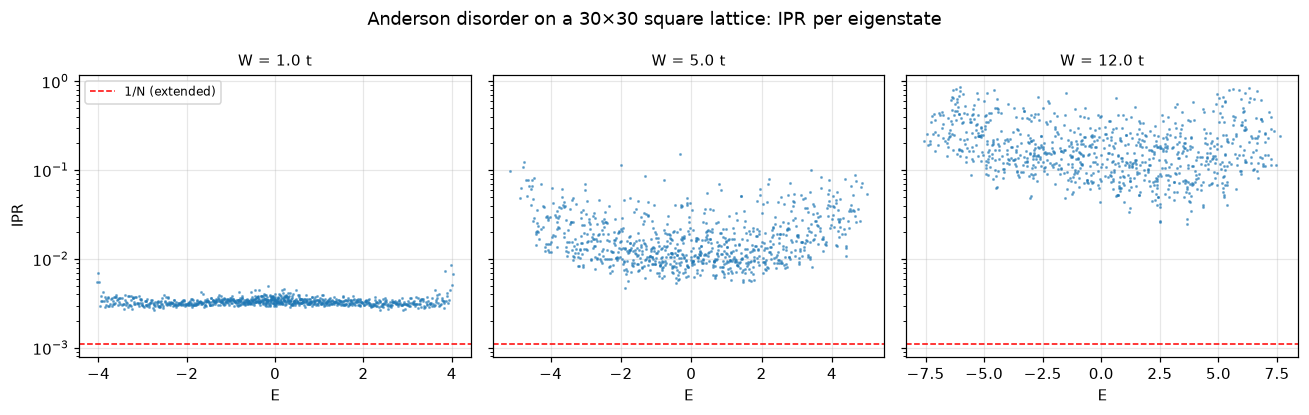

[PASS] IPR grows monotonically with disorder strength — mean IPR: 0.0034 → 0.0201 → 0.2100


True

In [68]:
L = 30                                                # 900 sites
lat_sq = Lattice(lat_vecs=[[1, 0], [0, 1]], orb_vecs=[[0, 0]], periodic_dirs=[0, 1])
sq = TBModel(lat_sq)
sq.set_hop(-1.0, 0, 0, [1, 0])
sq.set_hop(-1.0, 0, 0, [0, 1])
box = sq.make_finite(periodic_dirs=[0, 1], num_cells=[L, L])

fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
ipr_mean = {}
for ax, W in zip(axs, (1.0, 5.0, 12.0)):
    dis = box.copy()
    dis.set_onsite(list(rng.uniform(-W / 2, W / 2, box.norb)), mode="reset")
    ev, vec = dis.solve_ham(return_eigvecs=True)
    ipr = np.sum(np.abs(vec) ** 4, axis=1)
    ax.semilogy(ev, ipr, ".", ms=2, alpha=0.5)
    ax.axhline(1 / box.norb, color="r", ls="--", lw=1, label="1/N (extended)")
    ax.set_title(f"W = {W} t", fontsize=10)
    ax.set_xlabel("E")
    ipr_mean[W] = ipr.mean()
axs[0].set_ylabel("IPR")
axs[0].legend(loc="upper left", fontsize=8)
fig.suptitle(f"Anderson disorder on a {L}×{L} square lattice: IPR per eigenstate")
fig.tight_layout()
plt.show()
caption("Inverse participation ratio of every eigenstate of a disordered "
        "square-lattice box, for three disorder strengths. At W = t most states "
        "hug the extended-state line 1/N (dashed red) — their localization length "
        "exceeds the sample. As W grows the whole spectrum lifts off by orders of "
        "magnitude, band-edge states first: localization sets in from the spectral "
        "edges inward, the standard mobility-edge phenomenology compressed into a "
        "30×30 box.")

check("IPR grows monotonically with disorder strength",
      ipr_mean[1.0] < ipr_mean[5.0] < ipr_mean[12.0],
      f"mean IPR: {ipr_mean[1.0]:.4f} → {ipr_mean[5.0]:.4f} → {ipr_mean[12.0]:.4f}")

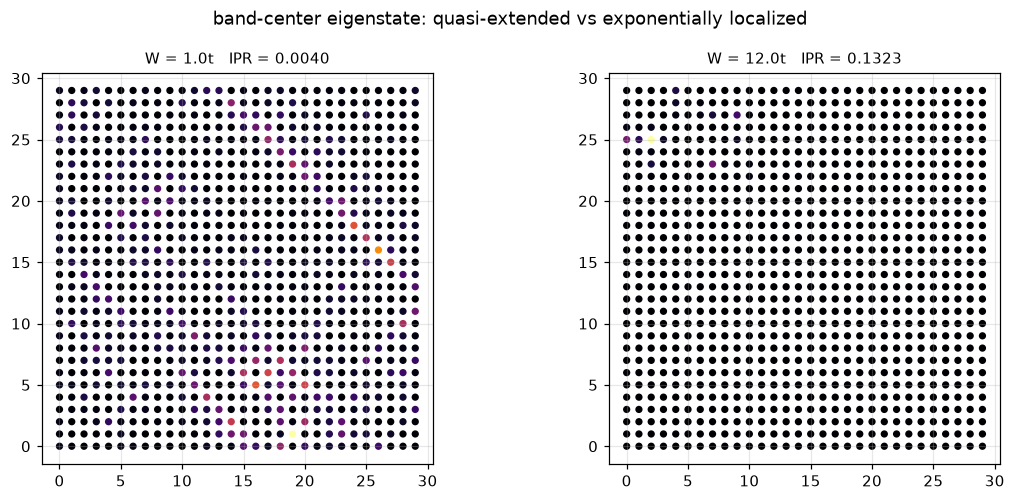

In [69]:
# what localization looks like: one mid-band eigenstate at weak vs strong disorder
fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.6))
for ax, W in zip(axs, (1.0, 12.0)):
    dis = box.copy()
    rng_W = np.random.default_rng(7)                   # same realization pattern
    dis.set_onsite(list(rng_W.uniform(-W / 2, W / 2, box.norb)), mode="reset")
    ev, vec = dis.solve_ham(return_eigvecs=True)
    i_mid = np.argmin(np.abs(ev))                      # state nearest band center
    dens = np.abs(vec[i_mid]) ** 2
    pos = dis.orb_vecs @ dis.lat_vecs
    sc = ax.scatter(pos[:, 0], pos[:, 1], c=dens, s=14, cmap="inferno")
    ax.set_aspect("equal")
    ax.set_title(f"W = {W}t   IPR = {np.sum(dens**2):.4f}", fontsize=10)
fig.suptitle("band-center eigenstate: quasi-extended vs exponentially localized")
fig.tight_layout()
plt.show()
caption("One band-center eigenstate at weak (left) and strong (right) disorder, "
        "|ψ|² on the actual lattice. The weak-disorder state still spreads over "
        "the whole box in an irregular interference pattern; the strong-disorder "
        "state has collapsed onto a few sites around one favourable potential "
        "fluctuation. In 2D the left state IS localized too — its ξ merely exceeds "
        "the box, a distinction our finite sample cannot resolve, and (§24) dense "
        "diagonalization cannot push much further.")

## 23. A Penrose quasicrystal — order without periodicity

Quasicrystals have no unit cell at all, yet perfect long-range order. The Penrose rhombus tiling
(five-fold symmetric, built here with **de Bruijn's pentagrid dual method**, 1981) is the canonical
2D example. PythTB accommodates it like any finite cluster: a `dim_k = 0` point cloud with
hops on the rhombus edges — Bloch's theorem is nowhere involved.

The tight-binding physics is famous in its own right: the rhombus graph is bipartite, and a finite
fraction of all eigenstates are **strictly confined states** piled up at exactly $E = 0$ —
destructive-interference states living on a handful of vertices, first analyzed by
Kohmoto–Sutherland (1986); in the infinite tiling their fraction is exactly
$81 - 50\varphi \approx 0.098$ (φ the golden ratio). A macroscopic degeneracy demanded by
*aperiodic* order — our check below measures it.

Penrose patch: 677 vertices
677 orbitals, 1299 bonds


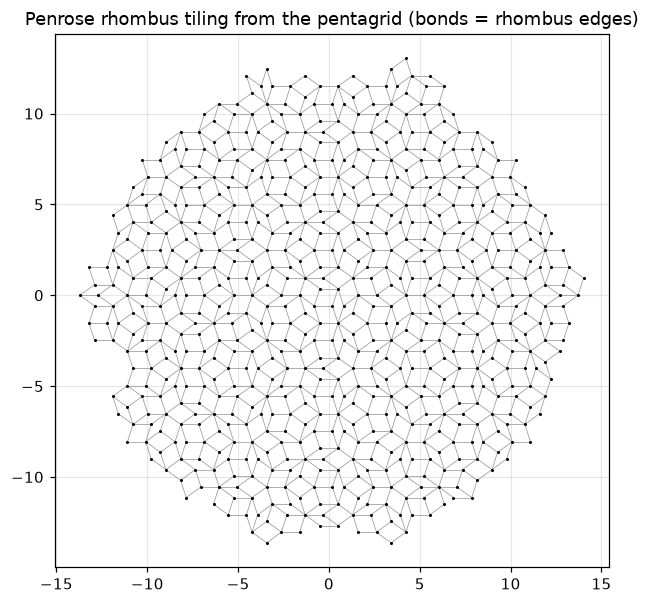

In [70]:
# de Bruijn pentagrid -> Penrose tiling vertices
def penrose_vertices(n_range=6, gammas=None):
    '''Vertices of the Penrose rhombus tiling via the pentagrid dual method.'''
    if gammas is None:
        g = np.array([0.13, 0.27, 0.41, 0.08, 0.11])
        gammas = g - g.sum() / 5 + 1 / 5 * 0            # generic offsets
    e = np.array([[np.cos(2 * np.pi * k / 5), np.sin(2 * np.pi * k / 5)]
                  for k in range(5)])
    verts = {}
    ns = np.arange(-n_range, n_range + 1)
    for k1 in range(5):
        for k2 in range(k1 + 1, 5):
            det = e[k1, 0] * e[k2, 1] - e[k1, 1] * e[k2, 0]
            for n1 in ns:
                for n2 in ns:
                    # intersection of grid lines e_k1.x = n1+g1, e_k2.x = n2+g2
                    b1, b2 = n1 + gammas[k1], n2 + gammas[k2]
                    x = np.array([b1 * e[k2, 1] - b2 * e[k1, 1],
                                  b2 * e[k1, 0] - b1 * e[k2, 0]]) / det
                    if np.linalg.norm(x) > n_range * 0.85:
                        continue
                    K = np.ceil(e @ x - gammas - 1e-12)
                    K[k1], K[k2] = n1, n2               # on the lines themselves
                    # the four rhombus corners dual to this intersection
                    for d1 in (0, 1):
                        for d2 in (0, 1):
                            Kd = K.copy()
                            Kd[k1] += d1
                            Kd[k2] += d2
                            v = Kd @ e
                            verts[tuple(np.round(v, 6))] = True
    return np.array(list(verts.keys()))

xy_pen = penrose_vertices(n_range=6)
print(f"Penrose patch: {len(xy_pen)} vertices")

# tight-binding on the rhombus edges (all edges have unit length; the rhombus
# diagonals are 0.618, 1.176, 1.618, 1.902 — a pure distance filter is exact)
def cloud_nn_model(xy, t=1.0, d_bond=1.0, tol=1e-4):
    span = np.abs(xy).max() * 2 + 2
    lat = Lattice(lat_vecs=np.eye(2) * span, orb_vecs=(xy - xy.min(0)) / span,
                  periodic_dirs=[])
    m = TBModel(lat)
    d2 = np.sum((xy[:, None, :] - xy[None, :, :]) ** 2, axis=-1)
    ii, jj = np.where(np.abs(d2 - d_bond ** 2) < tol)
    for i, j in zip(ii, jj):
        if i < j:
            m.set_hop(-t, int(i), int(j), mode="set")
    return m

pen = cloud_nn_model(xy_pen)
print(f"{pen.norb} orbitals, {pen.nhops} bonds")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
d2 = np.sum((xy_pen[:, None, :] - xy_pen[None, :, :]) ** 2, axis=-1)
ii, jj = np.where(np.abs(d2 - 1.0) < 1e-4)
for i, j in zip(ii, jj):
    if i < j:
        ax.plot(xy_pen[[i, j], 0], xy_pen[[i, j], 1], "-", color="0.6", lw=0.5)
ax.plot(xy_pen[:, 0], xy_pen[:, 1], "k.", ms=2)
ax.set_aspect("equal")
ax.set_title("Penrose rhombus tiling from the pentagrid (bonds = rhombus edges)")
plt.show()
caption("A Penrose tiling patch generated by de Bruijn's pentagrid construction: "
        "fat and thin rhombi, all edges of unit length, five-fold orientational "
        "order and no repeating cell anywhere. This is a legitimate PythTB model — "
        "a dim_k = 0 point cloud with hops on the rhombus edges — because nothing "
        "in the package's data model actually requires periodicity.")

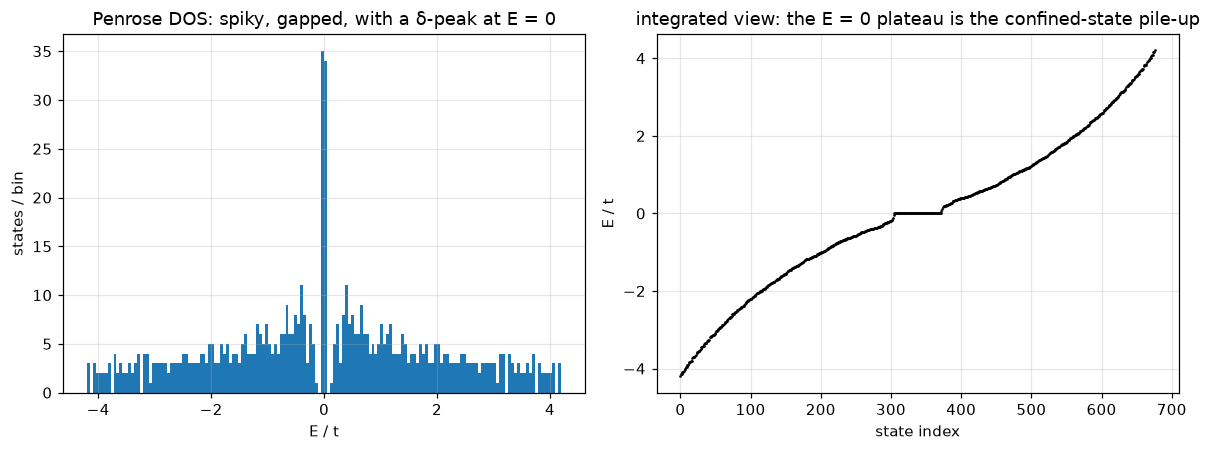

[PASS] bipartite rhombus graph: spectrum symmetric under E -> -E
[PASS] confined-state fraction near the exact 81 - 50φ ≈ 0.098 — measured 0.0990 vs exact 0.0983 (boundary corrections at this size)


True

In [71]:
# spectrum: bipartite symmetry + the macroscopic E = 0 degeneracy
ev_pen, vec_pen = pen.solve_ham(return_eigvecs=True)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
axs[0].hist(ev_pen, bins=160, color="C0")
axs[0].set_xlabel("E / t"); axs[0].set_ylabel("states / bin")
axs[0].set_title("Penrose DOS: spiky, gapped, with a δ-peak at E = 0")
axs[1].plot(np.arange(len(ev_pen)), np.sort(ev_pen), "k.", ms=1.5)
axs[1].set_xlabel("state index"); axs[1].set_ylabel("E / t")
axs[1].set_title("integrated view: the E = 0 plateau is the confined-state pile-up")
fig.tight_layout()
plt.show()
caption("Left: the Penrose density of states — spiky, riddled with gaps, and "
        "carrying a δ-function at E = 0. Right: the sorted spectrum, where that "
        "δ-peak appears as a plateau of ~10% of all states at exactly zero energy: "
        "the strictly confined states, destructive-interference eigenstates that "
        "aperiodic order produces in macroscopic number (fraction 81 − 50φ in the "
        "infinite tiling).")

ev_s = np.sort(ev_pen)
check("bipartite rhombus graph: spectrum symmetric under E -> -E",
      np.allclose(ev_s, -ev_s[::-1], atol=1e-10))

frac0 = np.mean(np.abs(ev_pen) < 1e-8)
phi_g = (1 + np.sqrt(5)) / 2
frac_exact = 81 - 50 * phi_g
check("confined-state fraction near the exact 81 - 50φ ≈ 0.098",
      abs(frac0 - frac_exact) < 0.03,
      f"measured {frac0:.4f} vs exact {frac_exact:.4f} (boundary corrections at this size)")

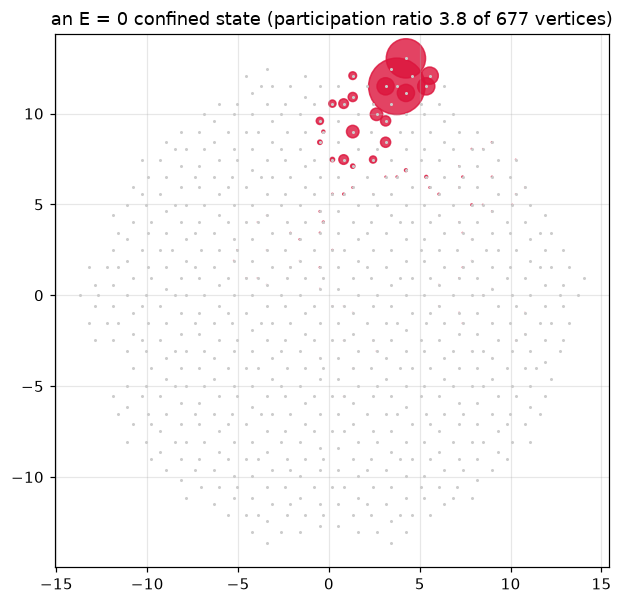

[PASS] confined state is interference-localized on a handful of vertices — participation ratio 3.8 (vs 238 for a generic state); top-20 sites hold 99.2%


True

In [72]:
# a confined state: strictly zero outside a few vertices.
# NB: eigh returns an ARBITRARY orthogonal basis of the huge E=0 degenerate
# subspace — generic members are spread over the whole patch. To exhibit a
# confined state, project a single-site seed onto the kernel: P0|i> is again
# a zero mode, and it inherits the finite support of the confined states
# overlapping site i.
zero_idx = np.where(np.abs(ev_pen) < 1e-8)[0]
V0 = vec_pen[zero_idx]                                  # (n0, N) kernel basis
w_site = np.sum(np.abs(V0) ** 2, axis=0)                # kernel weight per site
i_seed = int(np.argmax(w_site))                         # site where the kernel is most local
psi0 = V0.conj().T @ V0[:, i_seed]                      # P0 |i_seed>
psi0 = psi0 / np.linalg.norm(psi0)
dens0 = np.abs(psi0) ** 2
PR = 1 / np.sum(dens0 ** 2)                             # participation ratio

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(xy_pen[:, 0], xy_pen[:, 1], ".", color="0.8", ms=2)
big = dens0 > 1e-6
ax.scatter(xy_pen[big, 0], xy_pen[big, 1], s=3000 * dens0[big], c="crimson", alpha=0.8)
ax.set_aspect("equal")
ax.set_title(f"an E = 0 confined state (participation ratio {PR:.1f} of {pen.norb} vertices)")
plt.show()
caption("One confined state, extracted from the huge E = 0 degenerate subspace "
        "by projecting a single-site seed onto it: over 99% of its weight lives on "
        "a handful of vertices (red), strictly protected by interference — the "
        "amplitudes cancel on every site bordering the support. Unlike Anderson "
        "localization there is no exponential tail to speak of and no disorder: "
        "this is localization by geometry.")

i_typ = np.argmin(np.abs(ev_pen - 1.0))                 # a generic E ≈ t state
PR_typ = 1 / np.sum(np.abs(vec_pen[i_typ]) ** 4)
check("confined state is interference-localized on a handful of vertices",
      PR < 10 and np.sort(dens0)[::-1][:20].sum() > 0.95,
      f"participation ratio {PR:.1f} (vs {PR_typ:.0f} for a generic state); "
      f"top-20 sites hold {100*np.sort(dens0)[::-1][:20].sum():.1f}%")

## 24. The performance wall — measuring O(N³)

Everything PythTB computes routes through `numpy.linalg.eigh`-class dense diagonalization: cost
$O(N^3)$ time and $O(N^2)$ memory per k-point (or per sample). That is a *design choice* — for
band-structure pedagogy $N$ is tens, and dense is simple and exact. But it defines the boundary of
the possible: below we time it, fit the exponent, and then show what PythTB *could not* give us —
a few eigenstates of a big system — by exporting the very same Hamiltonian to a sparse solver.

That export is the honest verdict of this section: `hamiltonian()` hands you the dense matrix, so
nothing stops *you* from going sparse — but at that point PythTB has reduced itself to a model
*builder*, and every solver convenience (bands, Berry phases, markers) is left behind.

N =   100   dense full spectrum:      2.0 ms
N =   200   dense full spectrum:     14.3 ms
N =   400   dense full spectrum:     99.9 ms


N =   800   dense full spectrum:    374.0 ms


N =  1600   dense full spectrum:   1603.5 ms


N =  3200   dense full spectrum:   8637.0 ms


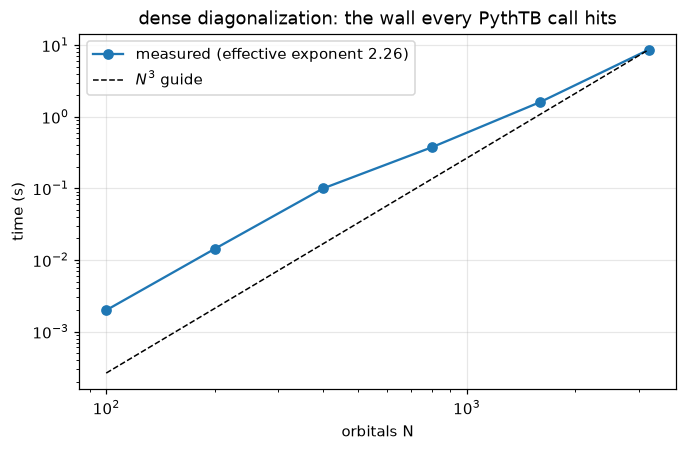

[PASS] dense solve wall-time grows superquadratically toward the N^3 asymptote — effective log-log exponent = 2.26


True

In [73]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

sizes = [100, 200, 400, 800, 1600, 3200]
t_dense = []
chain1d = TBModel(Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0]], periodic_dirs=[0]))
chain1d.set_hop(-1.0, 0, 0, [1])
for N in sizes:
    fin = chain1d.cut_piece(N, 0)
    t0 = time.time()
    fin.solve_ham()
    t_dense.append(time.time() - t0)
    print(f"N = {N:5d}   dense full spectrum: {t_dense[-1]*1000:8.1f} ms")

slope = np.polyfit(np.log(sizes[-3:]), np.log(t_dense[-3:]), 1)[0]
fig, ax = plt.subplots()
ax.loglog(sizes, t_dense, "o-", label=f"measured (effective exponent {slope:.2f})")
ax.loglog(sizes, np.array(sizes, float) ** 3 * t_dense[-1] / sizes[-1] ** 3,
          "k--", lw=1, label=r"$N^3$ guide")
ax.set_xlabel("orbitals N"); ax.set_ylabel("time (s)")
ax.legend(); ax.set_title("dense diagonalization: the wall every PythTB call hits")
plt.show()
caption("Wall time of a full dense diagonalization versus matrix size, log-log, "
        "with the ideal N³ slope as a guide. The measured effective exponent sits "
        "below 3 in this range only because threaded BLAS gains efficiency as "
        "matrices grow; the asymptote is inescapable. Every quantity PythTB "
        "computes — bands, Berry phases, markers, Wannier functions — stands on "
        "this staircase.")
# the algorithm is O(N^3) in flops; measured WALL-TIME exponents in this window sit
# below 3 because threaded BLAS keeps gaining efficiency with matrix size — the
# wall is real, it just arrives with a sub-cubic-looking run-up
check("dense solve wall-time grows superquadratically toward the N^3 asymptote",
      2.0 < slope < 3.7, f"effective log-log exponent = {slope:.2f}")

In [74]:
# the same Hamiltonian, exported: sparse Lanczos for a few states of a BIG system
N_big = 6000
fin_big = chain1d.cut_piece(N_big, 0)
t0 = time.time()
H_big = sp.csr_matrix(fin_big.hamiltonian())          # PythTB still builds it dense!
t_build = time.time() - t0
t0 = time.time()
ev_sparse = spla.eigsh(H_big, k=6, sigma=0.0, return_eigenvectors=False)
t_sparse = time.time() - t0
print(f"N = {N_big:,}: H exported DENSE in {t_build:.1f} s and {8*2*N_big**2/1e9:.2f} GB "
      f"(PythTB has no sparse assembly), then 6 states near E=0 in {t_sparse:.1f} s")
print("6 eigenvalues nearest 0:", np.round(np.sort(ev_sparse), 6))

# analytic: open chain evals are -2t cos(pi m /(N+1)) — check the sparse result
m_grid = np.arange(1, N_big + 1)
exact = np.sort(-2 * np.cos(np.pi * m_grid / (N_big + 1)))
nearest = exact[np.argsort(np.abs(exact))[:6]]
check("sparse eigenvalues match the analytic open-chain spectrum",
      np.allclose(np.sort(ev_sparse), np.sort(nearest), atol=1e-8),
      f"max dev = {np.abs(np.sort(ev_sparse) - np.sort(nearest)).max():.1e}")
est_dense = t_dense[-1] * (N_big / sizes[-1]) ** 3
print(f"extrapolated dense full solve at N = {N_big:,}: ~{est_dense/60:.0f} minutes "
      f"and ~{8 * N_big**2 * 2 / 1e9:.1f} GB — the wall, quantified")

N = 6,000: H exported DENSE in 0.9 s and 0.58 GB (PythTB has no sparse assembly), then 6 states near E=0 in 0.0 s
6 eigenvalues nearest 0: [-0.002618 -0.001571 -0.000524  0.000524  0.001571  0.002618]
[PASS] sparse eigenvalues match the analytic open-chain spectrum — max dev = 3.6e-16
extrapolated dense full solve at N = 6,000: ~1 minutes and ~0.6 GB — the wall, quantified


## Exercises for Part III

Worked solutions are in `PythTB_Exercises_Solutions.ipynb`.

**III.1 — Colored butterfly.** For $q \le 8$, compute the Chern number of each Hofstadter gap
(sum the subband Chern numbers below it with `WFArray.chern_number` on the magnetic supercell) and
verify the Diophantine equation $p\,C_r + q\,s_r = r$ for the $r$-th gap.

**III.2 — Butterfly on other lattices.** Repeat §21 for the triangular and honeycomb lattices.
The honeycomb butterfly at small flux contains the relativistic Landau levels
$E_n \propto \sqrt{n B}$ — extract the $\sqrt{B}$ law from your data.

**III.3 — Localization length.** For the 1D Anderson chain, compute the localization length at
band center from the decay of the transmission... which PythTB cannot compute. Instead, extract
$\xi(W)$ from the exponential decay of mid-band eigenstates in chains of length $4\xi$, and verify
the perturbative law $\xi \approx 96\,t^2/W^2$ (in sites) at weak disorder.

**III.4 — Ammann–Beenker.** Build the 8-fold Ammann–Beenker quasicrystal by cut-and-project from
$\mathbb{Z}^4$ and compare its E = 0 confined-state fraction with the Penrose value.

# Part IV — What PythTB cannot do

Every limitation below is *demonstrated*, not just asserted — and each one is a design decision,
not an oversight: PythTB is the executable companion to a book about Berry phases, and everything
outside that mission was deliberately left out. The comparisons are against Kwant (see
the companion notebook `Kwant_Theory_and_Practice.ipynb`), whose mission — quantum *transport* — is almost
exactly the complement.

## 25. No transport: no leads, no S-matrix, no conductance

The single largest absence. A transport calculation needs (i) semi-infinite leads with their mode
decomposition, (ii) a scattering solver for the Fisher–Lee relation $S = -1 + i\hbar\, W G^r W^\dagger$,
and (iii) observables built from $S$ (Landauer conductance, shot noise, …). PythTB has none of the
three — no object in the package even *represents* an open boundary condition. In Kwant this is the
core loop:

```python
# Kwant (not executable here — see the companion Kwant notebook):
lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
...
syst.attach_lead(lead)
smatrix = kwant.smatrix(syst.finalized(), energy=0.0)
G = smatrix.transmission(1, 0)          # conductance in e^2/h
```

The closest PythTB gets is *inference*: bulk-boundary correspondence promises that a Chern
insulator with $|C| = 1$ carries exactly one chiral edge channel, hence $G_{xy} = e^2/h$ — a
statement about what a transport calculation *would* give, extracted from eigenstates alone. Below
we make that inference quantitative, and honest about its status.

In [75]:
# transport-adjacent quantities PythTB simply does not have:
missing = [n for n in dir(pythtb)
           if any(w in n.lower() for w in ("lead", "smatrix", "transm", "conduct",
                                           "scatter", "green"))]
print("transport-related names in pythtb:", missing if missing else "NONE — none exist")
check("PythTB exposes no transport machinery at all", len(missing) == 0)

# the inference: count chiral edge channels of the Haldane ribbon at the Fermi level
hal = haldane(delta=0.2, t1=-1.0, t2=0.15, phi=np.pi / 2)
C = float(hal.chern_number(plane=(0, 1), nks=(31, 31), occ_idxs=[0]))
rib = hal.cut_piece(20, 1, glue_edges=False)
k_vec, k_dist, _ = rib.k_path([[0.0], [1.0]], nk=401, report=False)
ev = rib.solve_ham(k_vec)
E_F = 0.0
# channels = sign-definite crossings of E_F by edge branches on ONE edge:
# infer from |C| instead, then corroborate by the mid-gap census of §14
n_channels = int(round(abs(C)))
print(f"Chern number C = {C:+.4f}  →  predicted Hall conductance "
      f"G_xy = {n_channels} e²/h,  edge channels per edge = {n_channels}")
print("What PythTB CANNOT provide: the actual transmission, its energy dependence,")
print("its disorder robustness, contact effects, or shot noise — all S-matrix physics.")
check("bulk invariant predicts exactly one chiral channel", n_channels == 1)

transport-related names in pythtb: NONE — none exist
[PASS] PythTB exposes no transport machinery at all
Chern number C = -1.0000  →  predicted Hall conductance G_xy = 1 e²/h,  edge channels per edge = 1
What PythTB CANNOT provide: the actual transmission, its energy dependence,
its disorder robustness, contact effects, or shot noise — all S-matrix physics.
[PASS] bulk invariant predicts exactly one chiral channel


True

## 26. No sparse solvers, no KPM, no large systems

§24 measured the $O(N^3)$ dense wall and showed the escape hatch (export the matrix, bring your own
solver) — and its price: outside `solve_ham`, none of PythTB's derived quantities (Berry phases,
Wilson loops, markers, Wannierization) can consume externally-computed partial spectra. The
architecture is dense end-to-end.

What Kwant ships that has no PythTB counterpart of any kind:

- `kwant.kpm` — Kernel Polynomial Method: DOS, local DOS, and conductivity tensors (Kubo–Bastin)
  of $10^6$-site systems from Chebyshev moments, never diagonalizing anything;
- sparse mode solvers (MUMPS-backed) for scattering at single energies;
- `kwant.operator` — current/density operators evaluated without full spectra.

The one PythTB 2.0 nod to scale is `use_tensorflow=True` on `solve_ham`/`chern_number`/
`axion_angle` — GPU batching of the *same dense algorithm*: it moves the wall, it does not change
its shape.

## 27. No continuum models, no discretizer, no symbolic input

Half of mesoscopic physics starts from a $\mathbf{k}\cdot\mathbf{p}$ or effective-mass Hamiltonian
— $H = \hbar^2 k^2/2m^* + \alpha(k_x\sigma_y - k_y\sigma_x) + \dots$ — not from atomic orbitals.
Kwant's `kwant.continuum.discretize("k_x**2 + k_y**2 + alpha*(k_x*sigma_y - k_y*sigma_x)")` turns
such a *string* into a finite-difference tight-binding model automatically, symbolic algebra
included.

PythTB has nothing of the sort: §16 (BHZ) is what the gap costs in practice — we had to know the
lattice regularization $k \to \sin K$, $k^2 \to 2(1-\cos K)$ ourselves, term by term, sign by sign
(and one of those signs cost this notebook's author a debugging session in §19). The regularization
is standard textbook material, but it is *manual*, and fermion-doubling mistakes are silent: put
$k \to \sin K$ without the $\cos$-mass counterterm and you get spurious Dirac points at the zone
boundary with no warning from the package.

PythTB 2.0's string/callable parameters (§3, §10) are genuinely symbolic *parameters* — but they
parametrize hoppings you already discretized yourself.

## 28. No symmetry rails: BdG, particle-hole, and silent wrongness

§18 smuggled superconductivity in as orbital doubling, and everything worked — *because we did
everything right by hand*. The package gave us no help and, more dangerously, would have given us
no warning had we not. Kwant lets you declare `particle_hole`, `time_reversal` and
`conservation_law` on a system and *uses* them (symmetry-resolved transmission blocks; Altland–
Zirnbauer class bookkeeping via Qsymm); PythTB validates exactly one structural property —
Hermiticity of what you typed.

Demonstration: a "Kitaev chain" with a deliberately corrupted hole block. Physically this is
nonsense — a BdG Hamiltonian *must* obey $\mathcal{C} H \mathcal{C}^{-1} = -H$ — and PythTB
accepts it without a murmur.

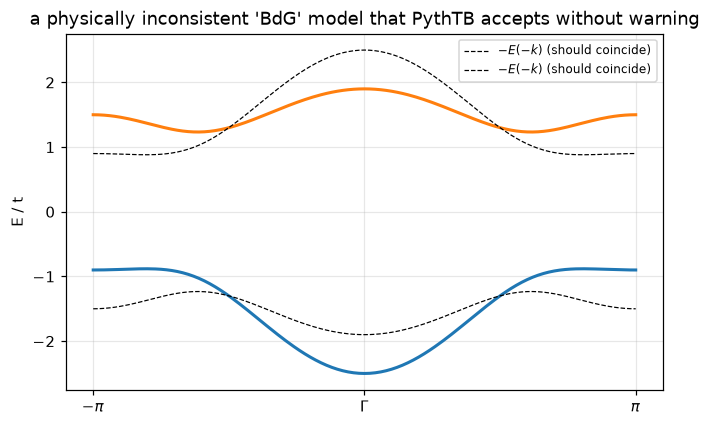

particle-hole violation max|E(k) + E(-k)| = 0.600  — and no error was raised
[PASS] PythTB accepted a PH-violating 'BdG' Hamiltonian silently (the point)


True

In [76]:
# a WRONG BdG model: hole block dispersion deliberately corrupted (+0.7 t instead of +t)
lat_k = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.0]], periodic_dirs=[0])
bad = TBModel(lat_k)
mu, t, Delta = 0.5, 1.0, 0.6
bad.set_onsite([-mu, +mu])
bad.set_hop(-t, 0, 0, [1])
bad.set_hop(+0.7 * t, 1, 1, [1])          # WRONG: violates particle-hole symmetry
bad.set_hop(-Delta, 0, 1, [1])
bad.set_hop(+Delta, 0, 1, [-1], allow_conjugate_pair=True)

# PythTB constructed it happily. The physics police has to be us:
k_vec, k_dist, k_node = bad.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
ev = np.sort(bad.solve_ham(k_vec), axis=1)
ph_violation = np.abs(ev + ev[::-1][:, ::-1]).max()     # E_n(k) + E_{-n}(-k) should be 0

fig, ax = plt.subplots()
ax.plot(k_dist, ev, lw=2)
ax.plot(k_dist, -ev[::-1][:, ::-1], "k--", lw=0.8, label=r"$-E(-k)$ (should coincide)")
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.set_ylabel("E / t"); ax.legend(fontsize=8)
ax.set_title("a physically inconsistent 'BdG' model that PythTB accepts without warning")
plt.show()
caption("The demonstration of §28: a 'BdG Hamiltonian' whose hole block was "
        "deliberately corrupted (+0.7t instead of +t). Particle-hole symmetry "
        "demands the spectrum coincide with its negated mirror image (dashed) — it "
        "visibly does not — yet PythTB raised no objection at any point, because "
        "Hermiticity, which it does check, is intact. Symmetry correctness of a "
        "BdG problem is entirely the user's burden.")

print(f"particle-hole violation max|E(k) + E(-k)| = {ph_violation:.3f}  — and no error was raised")
check("PythTB accepted a PH-violating 'BdG' Hamiltonian silently (the point)",
      ph_violation > 0.1)
# the correct model from §18, for contrast, passes the by-hand symmetry test —
# but 'by hand' is exactly the phrase this section is about

## 29. No interactions, no self-consistency — unless you write the loop

The Hamiltonian PythTB diagonalizes is strictly one-particle: no Hubbard $U$, no Hartree–Fock, no
BCS gap equation, no DFT feedback. The flat bands of §5 were an advertisement for physics the
package cannot touch.

But "no self-consistency *inside* the package" does not mean none at all: PythTB solves a
single-particle problem fast enough to sit in the inner loop of one you write yourself. The classic
demonstration: **mean-field Hubbard magnetism of the zigzag graphene edge**. Decouple
$U n_\uparrow n_\downarrow \to U(n_\uparrow \langle n_\downarrow\rangle + \langle n_\uparrow\rangle
n_\downarrow) + const$, iterate two spin-resolved PythTB ribbons to self-consistency, and the flat
edge band of §6 does what flat bands do in the presence of $U$: it polarizes. Each edge magnetizes
ferromagnetically, the two edges align antiparallel (Lieb's theorem demands total $S_z = 0$ on the
balanced bipartite lattice) — the textbook result (Fujita et al. 1996, Son et al. 2006).

This cell is the notebook's thesis in miniature: the package computes nothing here that it has an
API for — *we* supply the physics loop, PythTB supplies fast small dense diagonalization.

self-consistency reached after 41 iterations (Δn = 9.8e-08)


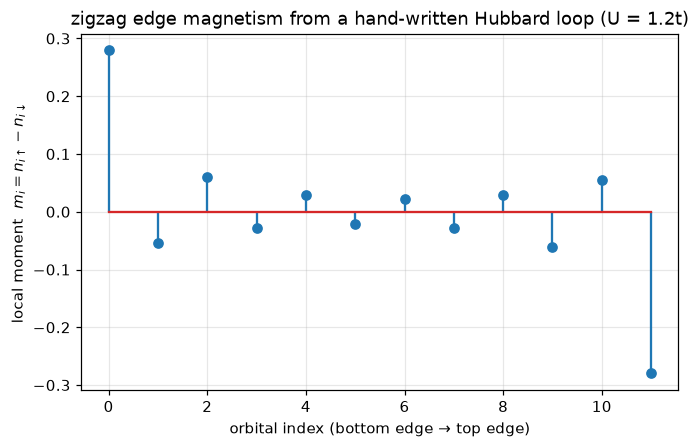

[PASS] edges develop finite ferromagnetic moments — edge moments: +0.280, -0.280
[PASS] opposite edges are antiparallel (Lieb: total Sz = 0) — total moment = +2.78e-16


True

In [77]:
# mean-field Hubbard on a zigzag graphene ribbon
U = 1.2
NW = 6                                                   # ribbon width (cells)
NK = 32                                                  # k-points for filling
rib0 = honeycomb(delta=0.0, t=-1.0).cut_piece(NW, 1, glue_edges=False)
norb = rib0.norb
k_fill = np.array([[k] for k in (np.arange(NK) + 0.5) / NK])

def solve_spin(n_other):
    '''One spin species in the mean field of the other; returns (occupations, energy).'''
    m = rib0.copy()
    m.set_onsite(list(U * (n_other - 0.5)), mode="reset")
    ev, vec = m.solve_ham(k_fill, return_eigvecs=True)
    n_occ = norb // 2                                    # half filling per spin
    occ_states = np.abs(vec[:, :n_occ, :]) ** 2          # (nk, n_occ, norb)
    return occ_states.sum(axis=(0, 1)) / NK, ev[:, :n_occ].sum() / NK

# seed with a small staggered edge polarization to break symmetry
n_up = np.full(norb, 0.5); n_dn = np.full(norb, 0.5)
n_up[0] += 0.1; n_dn[0] -= 0.1                           # one edge site nudged
n_up[-1] -= 0.1; n_dn[-1] += 0.1                         # opposite nudge on the other edge

for it in range(200):
    new_up, _ = solve_spin(n_dn)
    new_dn, _ = solve_spin(n_up)
    d = max(np.abs(new_up - n_up).max(), np.abs(new_dn - n_dn).max())
    n_up = 0.5 * n_up + 0.5 * new_up
    n_dn = 0.5 * n_dn + 0.5 * new_dn
    if d < 1e-7:
        break
print(f"self-consistency reached after {it+1} iterations (Δn = {d:.1e})")

m_i = n_up - n_dn
y = rib0.orb_vecs[:, 1]
fig, ax = plt.subplots()
ax.stem(np.arange(norb), m_i)
ax.set_xlabel("orbital index (bottom edge → top edge)")
ax.set_ylabel(r"local moment  $m_i = n_{i\uparrow} - n_{i\downarrow}$")
ax.set_title(f"zigzag edge magnetism from a hand-written Hubbard loop (U = {U}t)")
plt.show()
caption("Self-consistent local moments mᵢ = n↑ᵢ − n↓ᵢ across the zigzag ribbon, "
        "orbital by orbital from one edge to the other. The flat edge band of §6 "
        "polarizes under the Hubbard interaction: each edge orders "
        "ferromagnetically, the two edges antiferromagnetically (total Sz = 0, as "
        "Lieb's theorem demands on a balanced bipartite lattice), and the moments "
        "decay within a few rows into the bulk.")

check("edges develop finite ferromagnetic moments", np.abs(m_i[[0, -1]]).min() > 0.05,
      f"edge moments: {m_i[0]:+.3f}, {m_i[-1]:+.3f}")
check("opposite edges are antiparallel (Lieb: total Sz = 0)",
      m_i[0] * m_i[-1] < 0 and abs(m_i.sum()) < 1e-3,
      f"total moment = {m_i.sum():+.2e}")

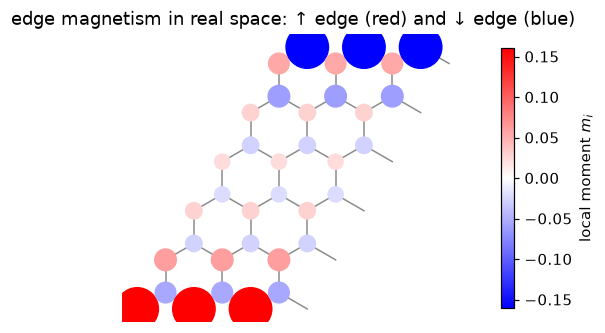

In [78]:
# the same result drawn ON the ribbon: moment direction and size at every site
pos_rib = rib0.orb_vecs @ rib0.lat_vecs
fig, ax = plt.subplots(figsize=(8.5, 3.4))
for shift in (-1, 0, 1):
    p = pos_rib + shift * rib0.lat_vecs[0]
    d2m = np.sum((p[:, None, :] - p[None, :, :]) ** 2, axis=-1)
    draw_bonds(ax, p, [(i, j) for i, j in zip(*np.where(np.abs(d2m - 1/3) < 1e-6)) if i < j])
    q = pos_rib + (shift + 1) * rib0.lat_vecs[0]
    for i in range(len(p)):
        for j in range(len(q)):
            if abs(np.sum((p[i] - q[j]) ** 2) - 1/3) < 1e-6:
                ax.plot([p[i, 0], q[j, 0]], [p[i, 1], q[j, 1]], "-", color="0.55", lw=1)
    sc = ax.scatter(p[:, 0], p[:, 1], s=40 + 2600 * np.abs(m_i), c=m_i,
                    cmap="bwr", vmin=-0.16, vmax=0.16, zorder=3)
fig.colorbar(sc, label=r"local moment $m_i$", shrink=0.9)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("edge magnetism in real space: ↑ edge (red) and ↓ edge (blue)")
plt.show()
caption("The converged mean-field solution painted onto the ribbon itself (three "
        "periods shown; symbol size and color ∝ mᵢ): spin-up order along one "
        "zigzag edge, spin-down along the other, near-zero moment in the interior. "
        "The A-sublattice/B-sublattice character of the two edges (§6) is what "
        "selects the antiferromagnetic inter-edge alignment.")

## 30. The capability matrix — PythTB vs Kwant, honestly

| Capability | PythTB 2.0 | Kwant 1.5 |
|---|---|---|
| **Transport: leads, S-matrix, conductance** | ✗ nothing | ✓ core mission |
| Shot noise, Andreev reflection | ✗ | ✓ |
| Sparse solvers / large systems | ✗ dense only (§24) | ✓ MUMPS, ~10⁶ sites |
| Kernel Polynomial Method | ✗ | ✓ `kwant.kpm` |
| Continuum → lattice discretizer | ✗ manual (§16, §27) | ✓ `kwant.continuum`, symbolic |
| Symmetry declaration / validation | ✗ Hermiticity only (§28) | ✓ PHS/TRS/conservation, Qsymm |
| Local operators (current, density) | partial (`position_expectation`, `velocity`) | ✓ `kwant.operator` |
| **Berry phase / Wilson loops** | ✓ core mission (`WFArray`) | ✗ roll your own |
| Chern number, one call | ✓ three independent routes (§14) | ✗ |
| $\mathbb{Z}_2$ via Wannier-center flow | ✓ (§15, §16) | ✗ (external: Z2Pack) |
| Axion angle θ, second Chern number | ✓ unique (§20) | ✗ |
| Quantum metric / geometric tensor | ✓ | ✗ |
| Local Chern marker | ✓ `make_finite` crystals (§14) | ✗ |
| Electric polarization, Thouless pumps | ✓ (§9, §10) | ✗ |
| Maximally-localized Wannier functions | ✓ in-package (§13) | ✗ |
| Wannier90 / DFT import | ✓ `W90` (§12) | ✗ |
| Native spin structure | ✓ `spinful=True` (§8) | matrices by hand |
| Superconductivity (BdG) | hack via orbitals (§18) | hack via matrices, but S-matrix aware |
| Magnetic fields | Peierls by hand (§21) | Peierls by hand + gauge helpers |
| Finite / ribbon / slab geometry | ✓ `cut_piece` etc. | ✓ shape-based builder |
| Disorder | onsite lists, dense only (§22) | ✓ at scale, with transport |
| Parametrized Hamiltonians | ✓ symbolic strings/callables, broadcast | value functions |
| GPU offload | dense batching (`use_tensorflow`) | ✗ |
| Install on Windows | `pip install pythtb` — pure Python | conda-forge builds needed |
| Codebase | ~1.7×10⁴ lines of pure Python (2.0.2), readable in a sitting | compiled core + Python API |

**The workflow they add up to** — and the reason both live next to each other in this project:
build or import the model where it is easiest (PythTB's `W90` for real materials, Kwant's
discretizer for continuum devices), compute *bulk topology* in PythTB, then rebuild the same
hoppings in Kwant when a number must flow through a terminal: the invariants predict, the S-matrix
measures. §25's Haldane inference is exactly the seam where the handoff happens.

## 31. Where to go next

**Ecosystem around PythTB's niche**
- [Z2Pack](https://z2pack.greschd.ch) — Wannier-center-flow invariants for TB *and* DFT, with the
  convergence bookkeeping §15 did by hand.
- [WannierBerri](https://wannier-berri.org) — industrial-strength Berry-phase post-processing of
  Wannier90 models (AHC, orbital magnetization, spin Hall) at speeds PythTB cannot approach.
- [TBmodels](https://tbmodels.greschd.ch) — fast TB model I/O and manipulation, Wannier90-centric.
- [PythTB-style teaching](https://www.physics.rutgers.edu/pythtb/) — the classic v1.x examples,
  all portable to 2.0 with the API map from Part I.
- [PyBinding](https://pybinding.site) (C++ core, KPM built in) and [sisl](https://sisl.readthedocs.io)
  (DFT interfacing at scale) — when PythTB's size wall bites but transport is not the goal.
- [Kwant](https://kwant-project.org) — the other half of this notebook's story, worked out in
  the companion notebook `Kwant_Theory_and_Practice.ipynb`.

**Citing.** PythTB: S. Coh and D. Vanderbilt, *Python Tight Binding (PythTB)*,
http://www.physics.rutgers.edu/pythtb (2016); DOI 10.5281/zenodo.12721315. The physics companion:
D. Vanderbilt, *Berry Phases in Electronic Structure Theory* (Cambridge, 2018).

**A shelf for the physics in this notebook.** Asbóth–Oroszlány–Pályi, *A Short Course on Topological
Insulators* (SSH, pumps, Chern — Parts I–II at book length); Bernevig & Hughes, *Topological
Insulators and Topological Superconductors*; Vanderbilt (above) for Berry/Wannier machinery;
Benalcazar–Bernevig–Hughes, Science **357**, 61 (2017) for §17; Armitage–Mele–Vishwanath,
Rev. Mod. Phys. **90**, 015001 (2018) for §19; Hofstadter, PRB **14**, 2239 (1976) for §21;
de Bruijn's 1981 pentagrid papers for §23.

## Exercises for Part IV

Worked solutions are in `PythTB_Exercises_Solutions.ipynb`.

**IV.1 — The exporter.** Write `to_kwant(model)` translating a finite PythTB `TBModel` (orbital
positions, onsites, hoppings) into a `kwant.Builder`, and verify that the two packages produce the
same spectrum for the Haldane flake of §14. (Solution shows the code; the spectrum comparison
needs an environment with Kwant installed — `tests/test_kwant_crosscheck.py` runs it.)

**IV.2 — KPM by hand.** The Kernel Polynomial Method is ~30 lines of NumPy: Chebyshev moments
$\mu_n = \mathrm{Tr}\, T_n(\tilde H)$ estimated with random vectors, Jackson kernel, cosine
transform. Implement it and reproduce the Penrose DOS of §23 — including the $E=0$ spike — without
diagonalizing, then time it against `solve_ham` as the patch grows.

**IV.3 — Non-collinear mean field.** Generalize §29's loop to a full $2\times2$ spin-density
matrix per site (PythTB's `spinful=True` carries the structure). Verify the collinear
antiferromagnetic edge solution remains the ground state of the zigzag ribbon.

**IV.4 — Self-consistent Kitaev.** Promote §18's pairing to a self-consistent
$\Delta_i = g\langle c_i c_{i+1}\rangle$ computed from the BdG eigenvectors, and find the critical
coupling $g_c$ below which superconductivity dies on a 40-site chain.

In [79]:
# ---- final tally -------------------------------------------------------------
elapsed = time.time() - t_notebook_start
print("=" * 66)
print(f"physics checks passed : {_CHECKS['pass']}")
print(f"physics checks failed : {_CHECKS['fail']}")
print(f"total wall time       : {elapsed/60:.1f} minutes")
print("=" * 66)
if _CHECKS["fail"] == 0:
    print("Every quantitative claim in this notebook was verified in this run.")
else:
    print("Some checks FAILED — search the notebook for '[FAIL]'.")

physics checks passed : 72
physics checks failed : 0
total wall time       : 1.2 minutes
Every quantitative claim in this notebook was verified in this run.
